### Retrieve the data into a Tibble

In [2]:
library(tidyverse)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.1     v tibble    3.2.1
v lubridate 1.9.3     v tidyr     1.3.1
v purrr     1.0.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
library(dplyr)
library(readr)
ebay <-read_csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/ebay9899.csv")

Rows: 318 Columns: 6
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl  (5): OpeningPrice, DailyHigh, DailyLow, ClosingPrice, Volume
date (1): DATE

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [100]:
summary(ebay)

  OpeningPrice       DailyHigh         DailyLow        ClosingPrice    
 Min.   :  9.292   Min.   :  9.75   Min.   :  8.417   Min.   :  9.667  
 1st Qu.: 78.750   1st Qu.: 82.25   1st Qu.: 75.312   1st Qu.: 78.594  
 Median :132.500   Median :134.91   Median :127.531   Median :132.188  
 Mean   :116.096   Mean   :121.02   Mean   :111.480   Mean   :116.202  
 3rd Qu.:152.812   3rd Qu.:157.55   3rd Qu.:146.703   3rd Qu.:152.000  
 Max.   :233.875   Max.   :234.00   Max.   :203.125   Max.   :215.000  
 NA's   :10        NA's   :10       NA's   :10        NA's   :10       
     Volume              DATE           
 Min.   :  270600   Min.   :1998-09-24  
 1st Qu.: 1703000   1st Qu.:1999-01-13  
 Median : 2926450   Median :1999-05-04  
 Mean   : 3704075   Mean   :1999-05-04  
 3rd Qu.: 5087750   3rd Qu.:1999-08-23  
 Max.   :15158800   Max.   :1999-12-13  
 NA's   :10                             

In [101]:
as_tibble(ebay)

OpeningPrice,DailyHigh,DailyLow,ClosingPrice,Volume,DATE
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>
17.8333,18.0833,14.7500,15.7917,9095400,1998-09-24
15.1667,15.3750,13.7083,14.9583,2126400,1998-09-25
15.8333,16.9583,15.3333,16.0833,1574300,1998-09-28
16.4583,16.7500,15.9167,16.2917,689000,1998-09-29
15.7292,16.0000,14.4167,15.0208,773600,1998-09-30
14.2083,14.4167,13.3333,13.3333,779200,1998-10-01
13.5000,13.9167,11.6667,13.3333,821000,1998-10-02
13.0417,13.0417,11.6250,11.9583,593300,1998-10-05
12.7500,12.7500,10.6667,12.1667,706200,1998-10-06


### Create a TS-ibble (Time Series Tibble)

Notes

• Viewing a data set

• View(name of data) - this will open an interactive view

• glimpse(name of data) 

• name of data

• To pipe in tibble, you can either use |> or %>% 

In [102]:
ebay_1999 <- ebay |> 
filter(DATE > "1998-12-31" & DATE < "2000-01-01")
head(ebay_1999)

OpeningPrice,DailyHigh,DailyLow,ClosingPrice,Volume,DATE
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>
NA,NA,NA,NA,NA,1999-01-01
78.7917,83.6667,77.3333,80.0000,783700,1999-01-04
76.0208,77.5000,73.2500,74.6667,1319900,1999-01-05
78.0000,95.0000,77.6667,94.3333,1910100,1999-01-06
90.7083,105.0000,90.0417,99.3333,2077200,1999-01-07
105.0000,107.0000,95.6875,97.4583,1568700,1999-01-08


In [4]:
library(datasets)

#Rob's package
install.packages("fpp3")
library(fpp3)



The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpviwXTL/downloaded_packages


Warning message:
"package 'fpp3' was built under R version 4.4.1"
Registered S3 method overwritten by 'tsibble':
  method               from 
  as_tibble.grouped_df dplyr

-- Attaching packages -------------------------------------------- fpp3 1.0.1 --

v tsibble     1.1.5     v feasts      0.3.2
v tsibbledata 0.4.1     v fable       0.3.4

-- Conflicts ------------------------------------------------- fpp3_conflicts --
x lubridate::date()    masks base::date()
x dplyr::filter()      masks stats::filter()
x tsibble::intersect() masks base::intersect()
x tsibble::interval()  masks lubridate::interval()
x dplyr::lag()         masks stats::lag()
x tsibble::setdiff()   masks base::setdiff()
x tsibble::union()     masks base::union()



In [104]:
# check out the airquality dataset
head(airquality)

,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


In [105]:
# create a date variable
airquality2 <- airquality %>% mutate(date= lubridate::make_date(1973,Month,Day))

In [106]:
# Assumption is that the created date parameter is a daily parameter
air_ts <- as_tsibble(airquality2,index=date)
head(air_ts)

Ozone,Solar.R,Wind,Temp,Month,Day,date
<int>,<int>,<dbl>,<int>,<int>,<int>,<date>
41,190,7.4,67,5,1,1973-05-01
36,118,8.0,72,5,2,1973-05-02
12,149,12.6,74,5,3,1973-05-03
18,313,11.5,62,5,4,1973-05-04
NA,NA,14.3,56,5,5,1973-05-05
28,NA,14.9,66,5,6,1973-05-06


### Australian Residence Data

In [107]:
austres


,Qtr1,Qtr2,Qtr3,Qtr4
1971,,13067.3,13130.5,13198.4
1972,13254.2,13303.7,13353.9,13409.3
1973,13459.2,13504.5,13552.6,13614.3
1974,13669.5,13722.6,13772.1,13832.0
1975,13862.6,13893.0,13926.8,13968.9
1976,14004.7,14033.1,14066.0,14110.1
1977,14155.6,14192.2,14231.7,14281.5
1978,14330.3,14359.3,14396.6,14430.8
1979,14478.4,14515.7,14554.9,14602.5
1980,14646.4,14695.4,14746.6,14807.4


In [108]:
# Chekc if its a TS object:

is.ts(austres)

[1] TRUE

In [109]:
austres_ts <- austres %>% as_tsibble()
head(austres_ts)

index,value
<qtr>,<dbl>
1971 Q2,13067.3
1971 Q3,13130.5
1971 Q4,13198.4
1972 Q1,13254.2
1972 Q2,13303.7
1972 Q3,13353.9


### Tibble to TS-ibble

In [110]:
prison <- readr::read_csv("https://OTexts.com/fpp3/extrafiles/prison_population.csv")

Rows: 3072 Columns: 6
-- Column specification --------------------------------------------------------
Delimiter: ","
chr  (4): State, Gender, Legal, Indigenous
dbl  (1): Count
date (1): Date

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [111]:
head(prison)

Date,State,Gender,Legal,Indigenous,Count
<date>,<chr>,<chr>,<chr>,<chr>,<dbl>
2005-03-01,ACT,Female,Remanded,ATSI,0
2005-03-01,ACT,Female,Remanded,Non-ATSI,2
2005-03-01,ACT,Female,Sentenced,ATSI,0
2005-03-01,ACT,Female,Sentenced,Non-ATSI,5
2005-03-01,ACT,Male,Remanded,ATSI,7
2005-03-01,ACT,Male,Remanded,Non-ATSI,58


In [112]:
# Convert to tsibble. Essentailly all categorical variables need to 'stratify' so that each dataset is grouped apples to apples
prison <- prison |>
mutate(Quarter = yearquarter(Date)) |>
select(-Date) |>
as_tsibble(key = c(State, Gender, Legal, Indigenous),
index = Quarter)

In [113]:
head(prison)

State,Gender,Legal,Indigenous,Count,Quarter
<chr>,<chr>,<chr>,<chr>,<dbl>,<qtr>
ACT,Female,Remanded,ATSI,0,2005 Q1
ACT,Female,Remanded,ATSI,1,2005 Q2
ACT,Female,Remanded,ATSI,0,2005 Q3
ACT,Female,Remanded,ATSI,0,2005 Q4
ACT,Female,Remanded,ATSI,1,2006 Q1
ACT,Female,Remanded,ATSI,1,2006 Q2


### Airlines Data Set

In [10]:
library(readr)
air <- read_csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/usairlines.csv")
air.ts<-air %>% mutate(date=mdy(paste(Month, "1",Year))) %>% mutate(Month.ts = yearmonth(date)) %>% as_tsibble(index = Month.ts)
head(air.ts)

Rows: 219 Columns: 3
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl (3): Year, Month, Passengers

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


Year,Month,Passengers,date,Month.ts
<dbl>,<dbl>,<dbl>,<date>,<mth>
1990,1,34348,1990-01-01,1990 Jan
1990,2,33536,1990-02-01,1990 Feb
1990,3,40578,1990-03-01,1990 Mar
1990,4,38267,1990-04-01,1990 Apr
1990,5,38249,1990-05-01,1990 May
1990,6,40792,1990-06-01,1990 Jun


##### 1. Run the following code: count_gaps(air.ts).  How many implicit missing values are in this data set?
A. there are no missing values

In [115]:
count_gaps(air.ts)

.from,.to,.n
<mth>,<mth>,<int>


In [116]:
has_gaps(air.ts)

.gaps
<lgl>
FALSE


In [117]:
head(air.ts)

Year,Month,Passengers,date,Month.ts
<dbl>,<dbl>,<dbl>,<date>,<mth>
1990,1,34348,1990-01-01,1990 Jan
1990,2,33536,1990-02-01,1990 Feb
1990,3,40578,1990-03-01,1990 Mar
1990,4,38267,1990-04-01,1990 Apr
1990,5,38249,1990-05-01,1990 May
1990,6,40792,1990-06-01,1990 Jun


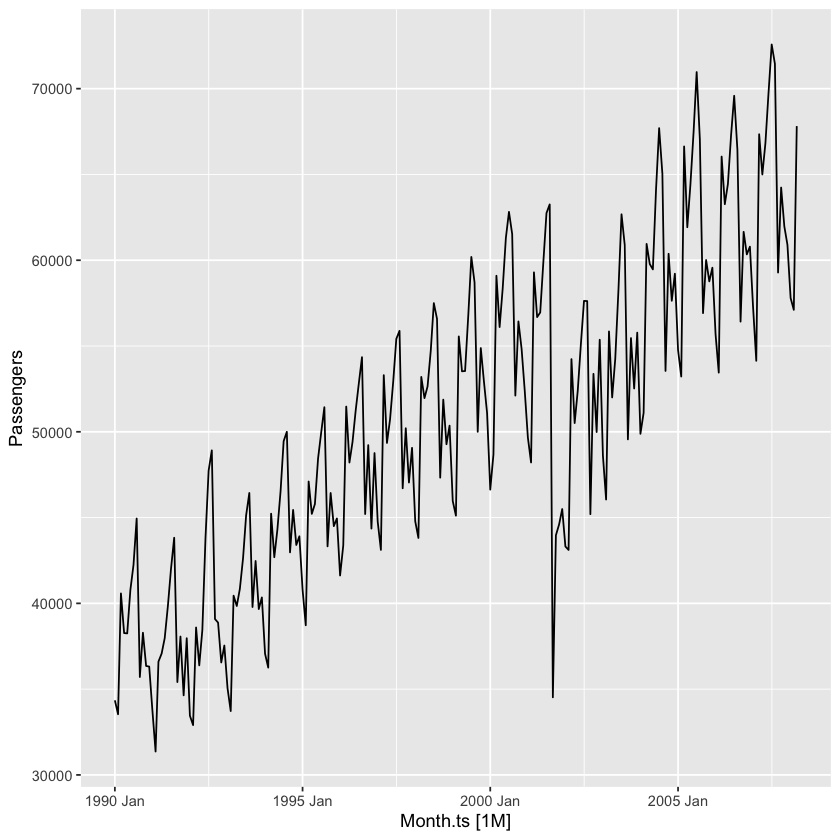

In [118]:
autoplot(air.ts, Passengers)

### Energy Dataset

In [119]:
energy <- read_csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/energy_F2024.csv")
energy_tib <- as.tibble(energy)
head(energy_tib)

Rows: 52608 Columns: 8
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (6): datetime_beginning_utc, datetime_beginning_ept, nerc_region, mkt_re...
dbl (1): mw
lgl (1): is_verified

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


datetime_beginning_utc,datetime_beginning_ept,nerc_region,mkt_region,zone,load_area,mw,is_verified
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>
8/1/2018 4:00,8/1/2018 0:00,RFC,WEST,AEP,AEPAPT,4050.612,TRUE
8/1/2018 5:00,8/1/2018 1:00,RFC,WEST,AEP,AEPAPT,3855.341,TRUE
8/1/2018 6:00,8/1/2018 2:00,RFC,WEST,AEP,AEPAPT,3744.805,TRUE
8/1/2018 7:00,8/1/2018 3:00,RFC,WEST,AEP,AEPAPT,3665.854,TRUE
8/1/2018 8:00,8/1/2018 4:00,RFC,WEST,AEP,AEPAPT,3681.299,TRUE
8/1/2018 9:00,8/1/2018 5:00,RFC,WEST,AEP,AEPAPT,3794.360,TRUE


##### Aggregate to daily totals

In [120]:
energy_tib.ts <- energy_tib |> mutate(Day.ts = as.Date(mdy_hm(datetime_beginning_ept)))|> as_tibble(index = Day.ts)

energy_tib.ts

datetime_beginning_utc,datetime_beginning_ept,nerc_region,mkt_region,zone,load_area,mw,is_verified,Day.ts
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<date>
8/1/2018 4:00,8/1/2018 0:00,RFC,WEST,AEP,AEPAPT,4050.612,TRUE,2018-08-01
8/1/2018 5:00,8/1/2018 1:00,RFC,WEST,AEP,AEPAPT,3855.341,TRUE,2018-08-01
8/1/2018 6:00,8/1/2018 2:00,RFC,WEST,AEP,AEPAPT,3744.805,TRUE,2018-08-01
8/1/2018 7:00,8/1/2018 3:00,RFC,WEST,AEP,AEPAPT,3665.854,TRUE,2018-08-01
8/1/2018 8:00,8/1/2018 4:00,RFC,WEST,AEP,AEPAPT,3681.299,TRUE,2018-08-01
8/1/2018 9:00,8/1/2018 5:00,RFC,WEST,AEP,AEPAPT,3794.360,TRUE,2018-08-01
8/1/2018 10:00,8/1/2018 6:00,RFC,WEST,AEP,AEPAPT,4021.192,TRUE,2018-08-01
8/1/2018 11:00,8/1/2018 7:00,RFC,WEST,AEP,AEPAPT,4217.335,TRUE,2018-08-01
8/1/2018 12:00,8/1/2018 8:00,RFC,WEST,AEP,AEPAPT,4394.209,TRUE,2018-08-01


In [121]:
energy_tib.ts <- energy_tib.ts |> select(-datetime_beginning_utc, -datetime_beginning_ept)
energy_tib.ts

nerc_region,mkt_region,zone,load_area,mw,is_verified,Day.ts
<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<date>
RFC,WEST,AEP,AEPAPT,4050.612,TRUE,2018-08-01
RFC,WEST,AEP,AEPAPT,3855.341,TRUE,2018-08-01
RFC,WEST,AEP,AEPAPT,3744.805,TRUE,2018-08-01
RFC,WEST,AEP,AEPAPT,3665.854,TRUE,2018-08-01
RFC,WEST,AEP,AEPAPT,3681.299,TRUE,2018-08-01
RFC,WEST,AEP,AEPAPT,3794.360,TRUE,2018-08-01
RFC,WEST,AEP,AEPAPT,4021.192,TRUE,2018-08-01
RFC,WEST,AEP,AEPAPT,4217.335,TRUE,2018-08-01
RFC,WEST,AEP,AEPAPT,4394.209,TRUE,2018-08-01


In [122]:
energy_tib.ts_agg <- energy_tib.ts|> group_by(across(-mw)) |> summarise(total_mw = sum(mw, na.rm = TRUE))

head(energy_tib.ts_agg)




`summarise()` has grouped output by 'nerc_region', 'mkt_region', 'zone',
'load_area', 'is_verified'. You can override using the `.groups` argument.


nerc_region,mkt_region,zone,load_area,is_verified,Day.ts,total_mw
<chr>,<chr>,<chr>,<chr>,<lgl>,<date>,<dbl>
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-01,110120.4
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-02,108871.6
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-03,106642.5
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-04,108985.3
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-05,110821.8
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-06,119088.4


In [123]:
max_day <- energy_tib.ts_agg |> slice_max(total_mw)
max_day

nerc_region,mkt_region,zone,load_area,is_verified,Day.ts,total_mw
<chr>,<chr>,<chr>,<chr>,<lgl>,<date>,<dbl>
RFC,WEST,AEP,AEPAPT,TRUE,2022-12-24,183480.3


In [124]:
energy.ts <- energy_tib.ts_agg %>% mutate %>% as_tsibble
head(energy.ts)

Using `Day.ts` as index variable.


nerc_region,mkt_region,zone,load_area,is_verified,Day.ts,total_mw
<chr>,<chr>,<chr>,<chr>,<lgl>,<date>,<dbl>
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-01,110120.4
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-02,108871.6
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-03,106642.5
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-04,108985.3
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-05,110821.8
RFC,WEST,AEP,AEPAPT,TRUE,2018-08-06,119088.4


In [125]:
count_gaps(energy.ts)

.from,.to,.n
<date>,<date>,<int>


In [126]:
has_gaps(energy.ts)

.gaps
<lgl>
FALSE


## Day 2: Intro to Time Series

In [11]:
library(tidyverse)
library(fpp3)

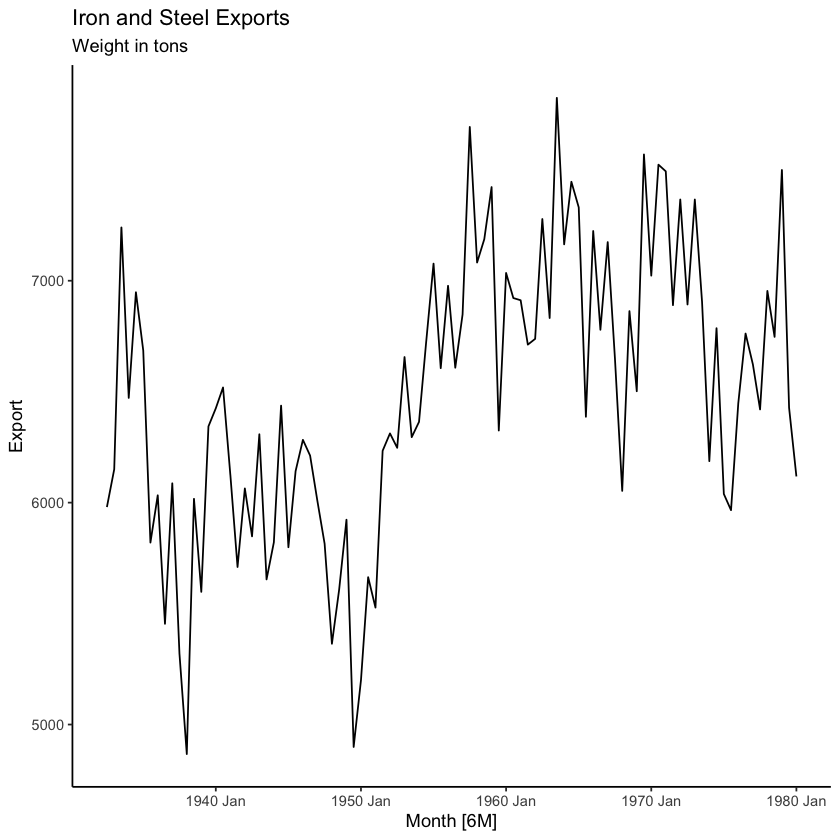

In [128]:
Steel <- read.csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/steel.csv")

Steel <- Steel |> mutate(date = seq(ymd('1932-07-01'),ymd('1980-01-
01'),by='6 months'))
steel_ts<-Steel |> mutate(Month=yearmonth(date)) |> 
as_tsibble(index=Month)
autoplot(steel_ts,steelshp) + labs(title= "Iron and Steel Exports", subtitle = 
"Weight in tons", y= "Export") + theme_classic()

#### Seasonal Plot

Rows: 219 Columns: 3
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl (3): Year, Month, Passengers

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


Year,Month,Passengers,date,Month.ts
<dbl>,<dbl>,<dbl>,<date>,<mth>
1990,1,34348,1990-01-01,1990 Jan
1990,2,33536,1990-02-01,1990 Feb
1990,3,40578,1990-03-01,1990 Mar
1990,4,38267,1990-04-01,1990 Apr
1990,5,38249,1990-05-01,1990 May
1990,6,40792,1990-06-01,1990 Jun


ERROR: Error in +labs(y = "Passengers", title = "Seasonal plot: US \nAirline Passengers"): invalid argument to unary operator


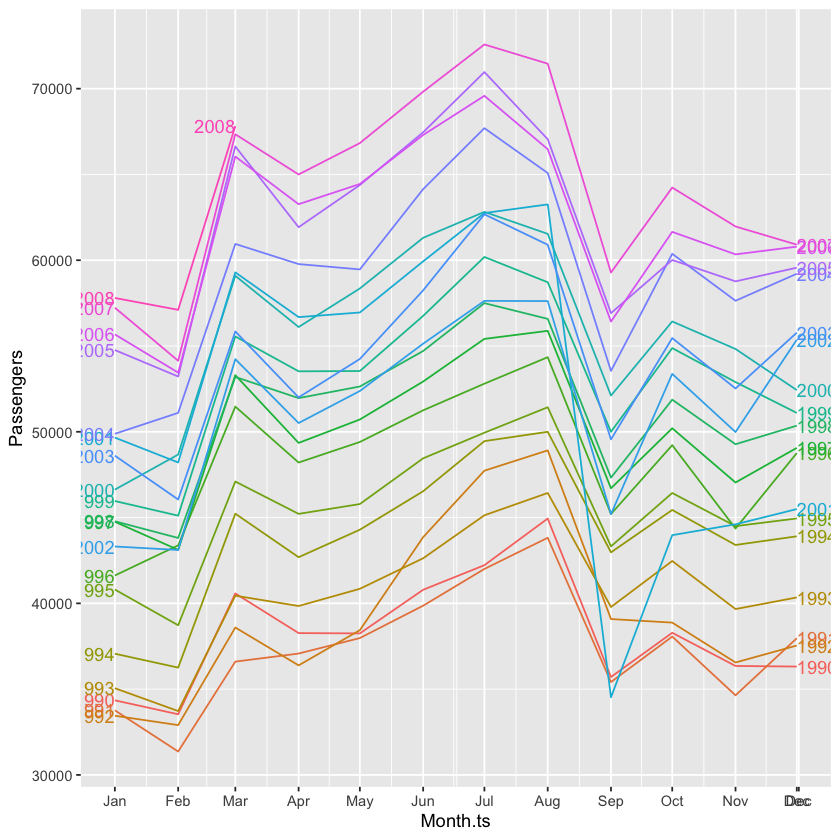

In [129]:
library(readr)
USAirlines <- read_csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/usairlines.csv")
USAirlines_ts<-USAirlines %>% mutate(date=mdy(paste(Month, "1",Year))) %>% mutate(Month.ts = yearmonth(date)) %>% as_tsibble(index = Month.ts)
head(USAirlines_ts)

USAirlines_ts |> gg_season(Passengers, labels = "both") 
+ labs(y = "Passengers", title = "Seasonal plot: US 
Airline Passengers")

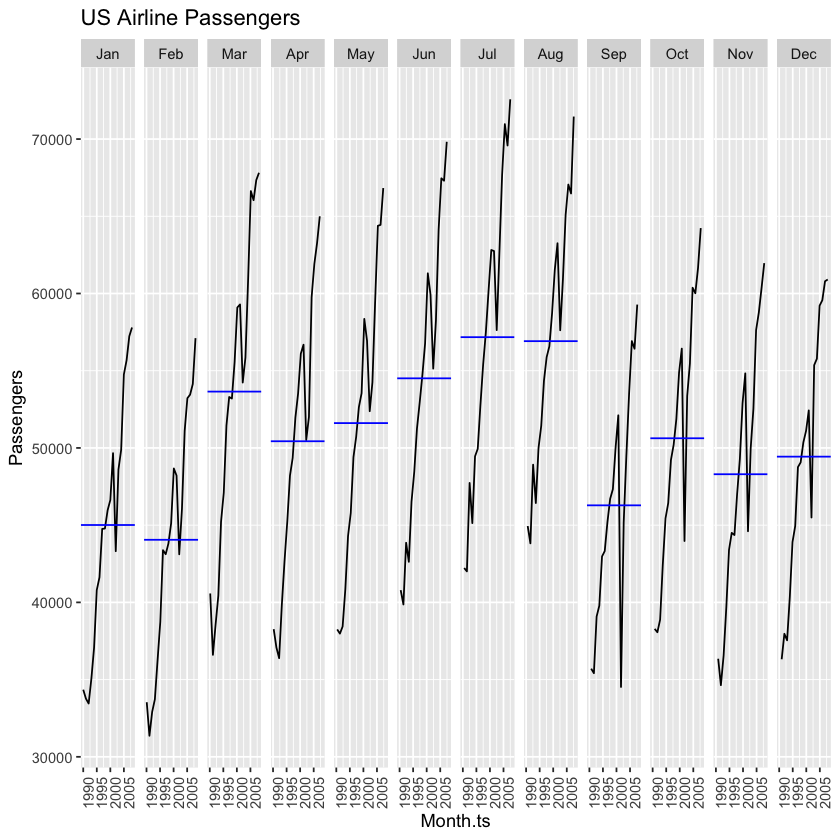

In [ ]:
USAirlines_ts |> gg_subseries(Passengers) + labs( y = 
"Passengers", title = "US Airline Passengers" )

### Seasonal Decomposition with the Airlines Data Set

In [130]:
# get the decomposition table
dcmp <- USAirlines_ts |> model(stl = STL(Passengers))
head(components(dcmp))


.model,Month.ts,Passengers,trend,season_year,remainder,season_adjust
<chr>,<mth>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stl,1990 Jan,34348,39032.53,-4675.5535,-8.971812,39023.55
stl,1990 Feb,33536,38897.11,-5842.0031,480.891301,39378.00
stl,1990 Mar,40578,38761.70,1238.1490,578.152654,39339.85
stl,1990 Apr,38267,38626.28,-563.2430,203.958112,38830.24
stl,1990 May,38249,38493.98,377.6404,-622.616603,37871.36
stl,1990 Jun,40792,38361.67,2949.5281,-519.195683,37842.47


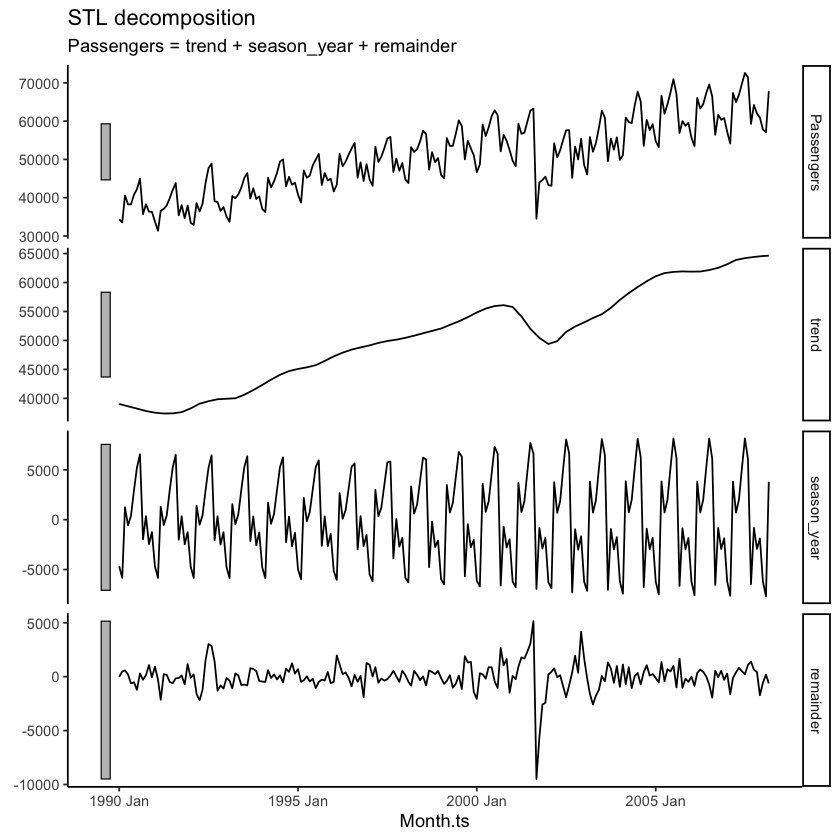

In [131]:
# get the visual breakdown
components(dcmp) |> autoplot() + theme_classic()

### Time Series Decompostion Overlay - Trend Overlay

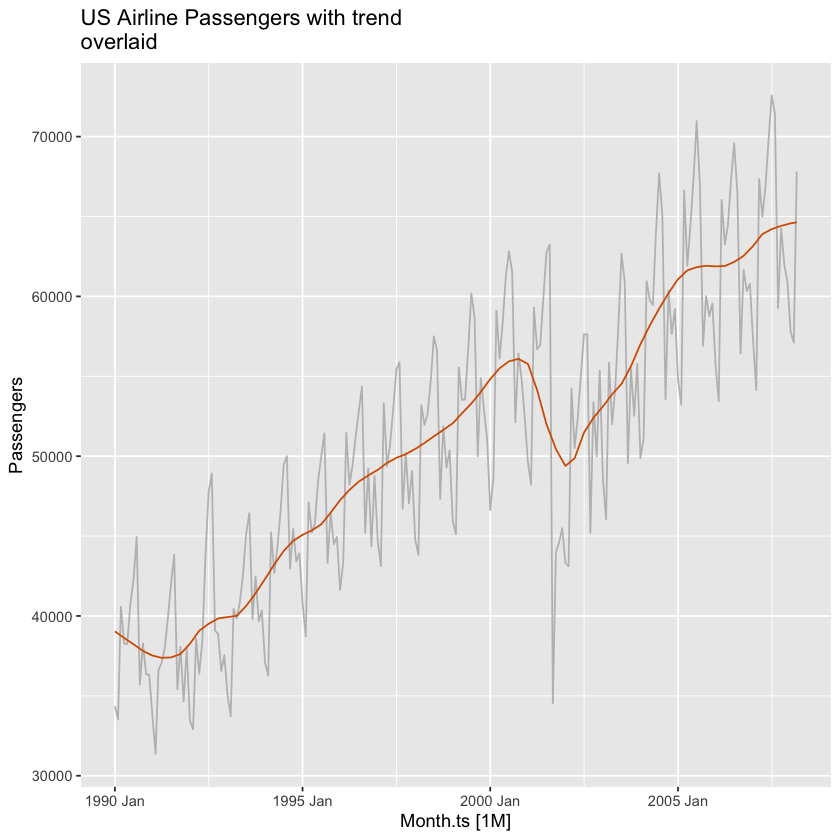

In [132]:
components(dcmp) |> as_tsibble() |> 
autoplot(Passengers, colour="gray") + 
geom_line(aes(y=trend), colour = "#D55E00") + labs( y = 
"Passengers", title = "US Airline Passengers with trend 
overlaid" )

### Multiple Overlays - Seasonal and Trend Components

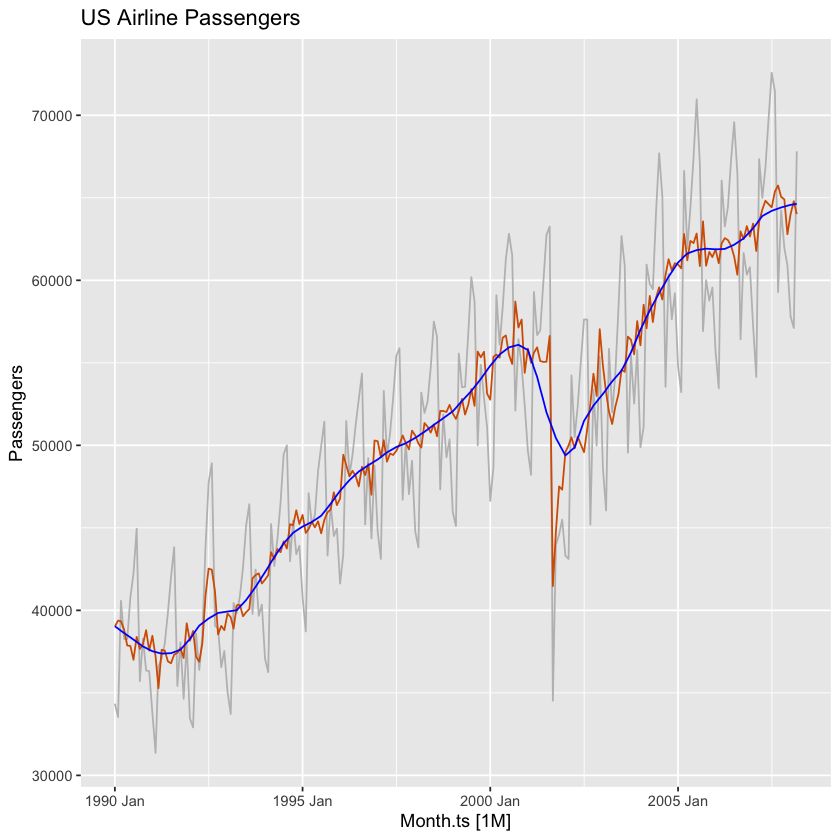

In [133]:
components(dcmp) |> as_tsibble() |> autoplot(Passengers, 
colour="gray") + geom_line(aes(y=season_adjust), colour = 
"#D55E00") + geom_line(aes(y=trend),colour="blue")+ labs( 
y = "Passengers", title = "US Airline Passengers " )

### Classical Decomposition

Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."


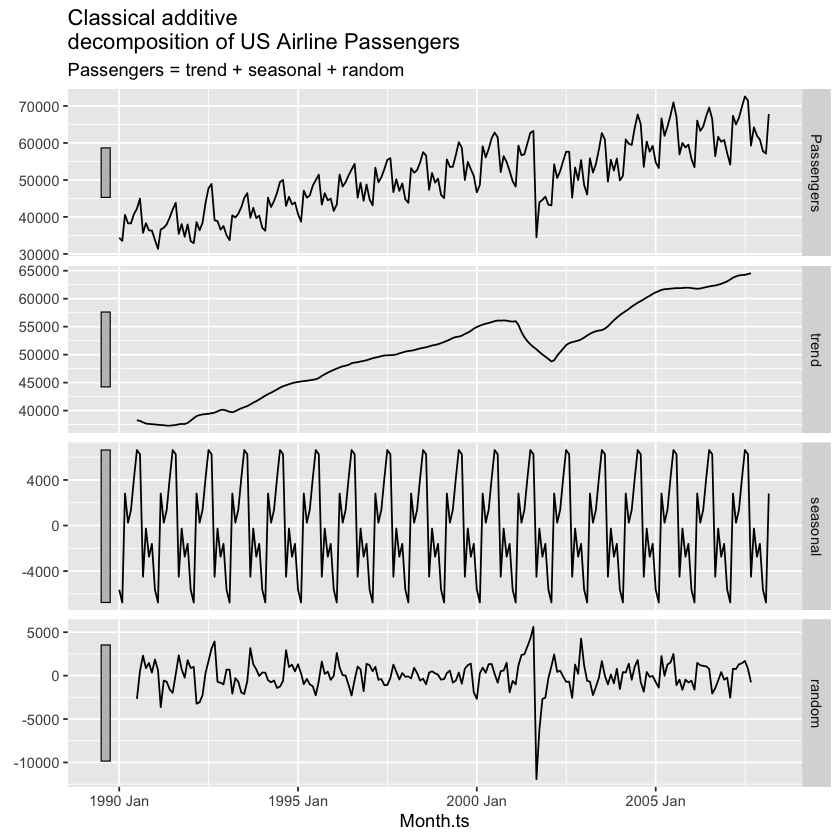

In [134]:
USAirlines_ts |> model(classical_decomposition(Passengers, 
type = "additive") ) |> 
components() |> autoplot() + labs(title = "Classical additive 
decomposition of US Airline Passengers")

### X13 ARIMA

In [11]:
install.packages("seasonal")
library(seasonal)


The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpviwXTL/downloaded_packages


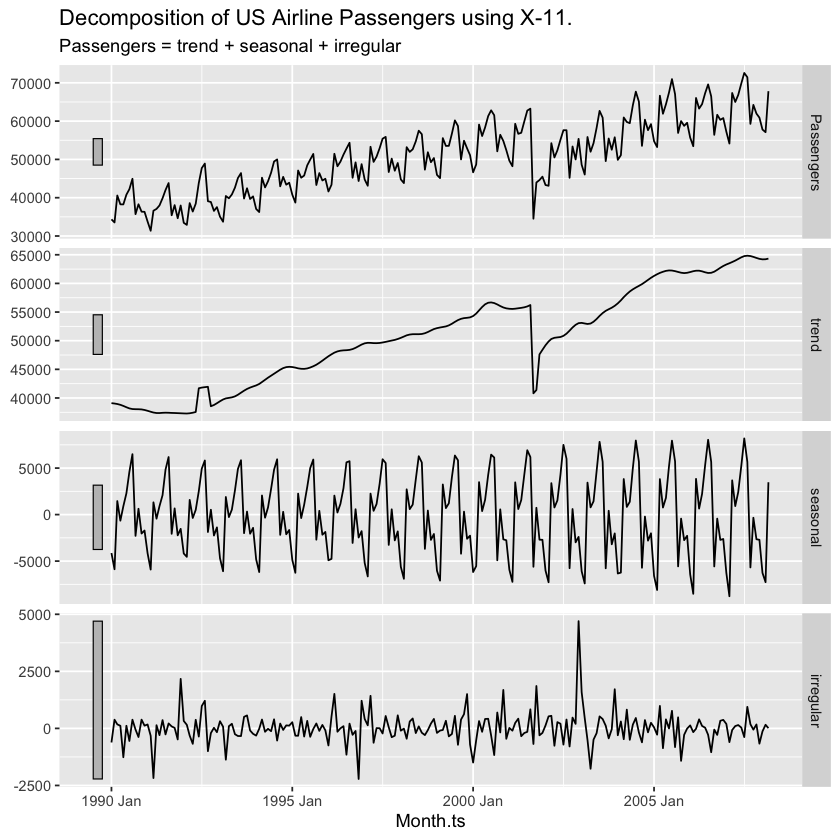

In [136]:
x11_dcmp <- USAirlines_ts |>
  model(x11 = X_13ARIMA_SEATS(Passengers ~ x11())) |>
  components()
autoplot(x11_dcmp) +
  labs(title =
    "Decomposition of US Airline Passengers using X-11.")

### Trend Strength: how much variation is due to Trend and Seasonality

In [137]:
USAirlines_ts |> 
features(Passengers, feat_stl)

trend_strength,seasonal_strength_year,seasonal_peak_year,seasonal_trough_year,spikiness,linearity,curvature,stl_e_acf1,stl_e_acf10
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.9760015,0.9186362,7,2,994798525,118740.1,-3054.244,0.2709543,0.2823999


### Handling Missing Values:

• Mean – uses the mean of the series (not a good 
imputation method for time series data)

• Locf – last observation carried forward (could also do 
Next Observation carried backward…NOCB)

• Spline – uses splines to impute missing values (could also 
use linear, quadratic, etc)

• Seadec – Seasonally decomposed imputation (does a 
decomposition and removes the seasonal component, 
imputes data then puts seasonal component back in)


In [138]:
install.packages("imputeTS")


The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//Rtmp0Y6xIk/downloaded_packages


In [6]:
library(imputeTS)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [140]:
#### Make some missing values:
set.seed(19076)
miss_val<-sample(1:nrow(USAirlines),30,replace=F)
miss_val<-c(miss_val,102,104:107)

US_temp<-USAirlines
US_temp$Passengers[miss_val]<-NA

col_vector=rep("blue",nrow(USAirlines))
col_vector[miss_val]="red"

In [141]:
# spline
Pass_impute<-Pass_miss %>% na_interpolation(option = "spline")
autoplot(Pass_impute,color=col_vector) + labs(y="Airline Passengers")

ERROR: Error in eval(expr, envir, enclos): object 'Pass_miss' not found


In [ ]:
# Seadac:
Pass_impute<-Pass_miss %>% na_seadec(algorithm = "interpolation")
autoplot(Pass_impute,color=col_vector) + labs(y="Airline Passengers")

## Forecasting

### Exponential Smoothing Models

#### Single Exponential Smoothing

In [142]:
Steel <- read.csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/steel.csv")

In [143]:
# Building a Single Exponential Smoothing (SES) Model - Steel Data #
Steel <- Steel |> mutate(date = seq(ymd('1932-07-01'),ymd('1980-01-01'),by='6 months'))

steel_ts<-Steel |> mutate(Month=yearmonth(date)) |> as_tsibble(index=Month)

steel_train <-steel_ts |> filter(year(date) <= 1975)

SES.Steel <- steel_train |>
  model(ETS(steelshp ~ error("A") + trend("N") + season("N")))
  
Steel.for <- SES.Steel |>
  fabletools::forecast(h = 9)

report(SES.Steel)

Series: steelshp 
Model: ETS(A,N,N) 
  Smoothing parameters:
    alpha = 0.466543 

  Initial states:
     l[0]
 6269.498

  sigma^2:  214894.3

     AIC     AICc      BIC 
1460.688 1460.977 1468.086 


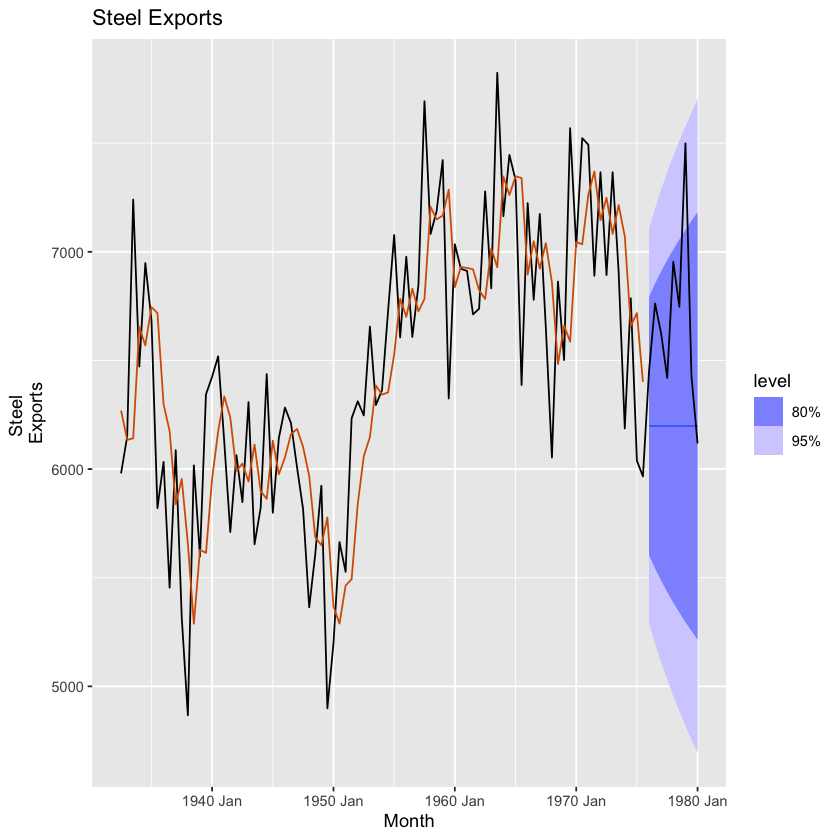

In [144]:
Steel.for |> autoplot(steel_ts) + geom_line(aes(y = .fitted), 
col="#D55E00", data = augment(SES.Steel)) + labs(y="Steel 
Exports", title="Steel Exports") + guides(colour = "none")

In [145]:
# get the fitted values for train
Steel_fitted <-fitted(SES.Steel)$.fitted

In [146]:
# get the fitted values for test
Steel.for <- SES.Steel |> fabletools::forecast(h = 9)
Steel_test <- Steel.for$.mean

#### Holt ESM : Level and Trend

In [147]:
# Building a Linear Exponential Smoothing Model - US Airlines Data #

USAirlines_ts <- USAirlines |> mutate(date=myd(paste(Month, Year, "1"))) |> mutate(Month2=yearmonth(date)) |> as_tsibble(index=Month2)

air_train <-USAirlines_ts |> filter(year(date) <= 2005)

LES.air <- air_train |>
  model(ETS(Passengers ~ error("A") + trend("A") + season("N")))
air.for <- LES.air |>
  fabletools::forecast(h = 27)
report(LES.air)

Series: Passengers 
Model: ETS(A,A,N) 
  Smoothing parameters:
    alpha = 0.5860139 
    beta  = 0.003740218 

  Initial states:
     l[0]     b[0]
 37303.09 526.6595

  sigma^2:  23188824

     AIC     AICc      BIC 
4271.560 4271.882 4287.847 


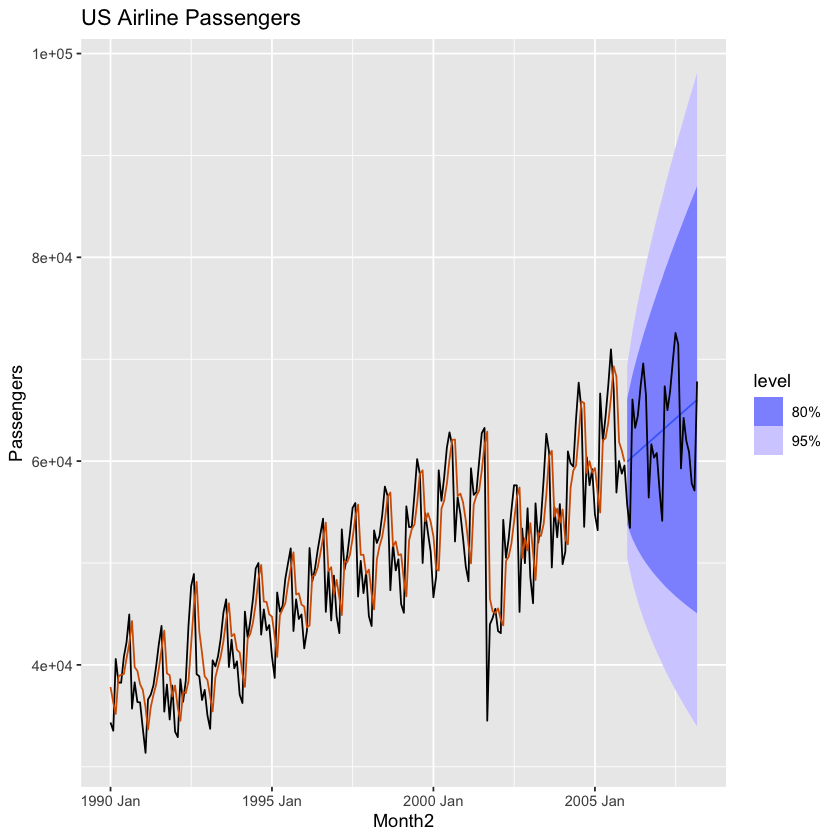

In [148]:
# Plot the data
air.for |>
  autoplot(USAirlines_ts) +
  geom_line(aes(y = .fitted), col="#D55E00",
            data = augment(LES.air)) +
  labs(y="Passengers", title="US Airline Passengers") +
  guides(colour = "none")

#### Holt Linear Damped Trend

In [149]:
LdES.air <- air_train |> model(ETS(Passengers ~ 
error("A") + trend("Ad") + season("N")))
air.for <- LdES.air |> fabletools::forecast(h = 27)
report(LdES.air)

Series: Passengers 
Model: ETS(A,Ad,N) 
  Smoothing parameters:
    alpha = 0.5705768 
    beta  = 0.0001003564 
    phi   = 0.8085131 

  Initial states:
     l[0]     b[0]
 36885.52 526.5046

  sigma^2:  23007825

     AIC     AICc      BIC 
4271.031 4271.485 4290.576 


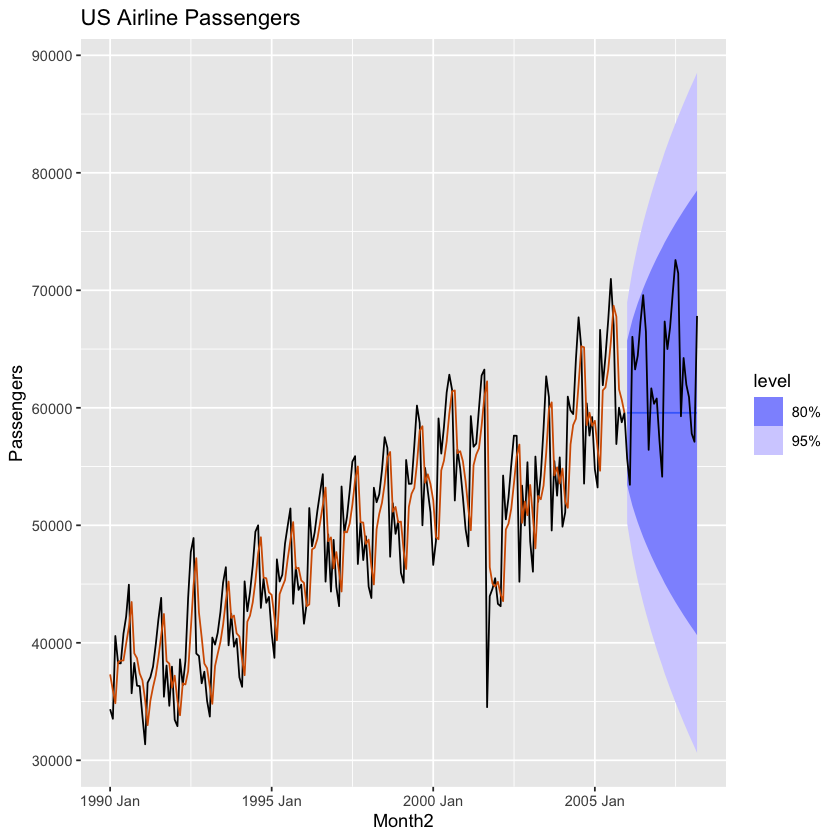

In [150]:
# Plot the data
air.for |>
  autoplot(USAirlines_ts) +
  geom_line(aes(y = .fitted), col="#D55E00",
            data = augment(LdES.air)) +
  labs(y="Passengers", title="US Airline Passengers") +
  guides(colour = "none")

### Holt Winters ESM: Level, Trend, and Seasonality - Additive

In [151]:
# Building a Holt-Winters ESM - US Airlines Data - Additive Seasonality

HWadd.air <- air_train |>
  model(ETS(Passengers ~ error("A") + trend("A") + season("A")))
  
air.for <- HWadd.air |>
  fabletools::forecast(h = 27)
report(HWadd.air)

Series: Passengers 
Model: ETS(A,A,A) 
  Smoothing parameters:
    alpha = 0.5913618 
    beta  = 0.0001002723 
    gamma = 0.0001000455 

  Initial states:
  l[0]     b[0]      s[0]     s[-1]     s[-2]     s[-3]    s[-4]    s[-5]
 38409 159.5944 -1520.744 -2728.928 -117.3477 -4305.732 6420.735 6299.852
    s[-6]    s[-7]    s[-8]    s[-9]    s[-10]    s[-11]
 4002.381 1210.882 122.2352 2660.169 -6471.051 -5572.452

  sigma^2:  4099578

     AIC     AICc      BIC 
3950.201 3953.718 4005.578 


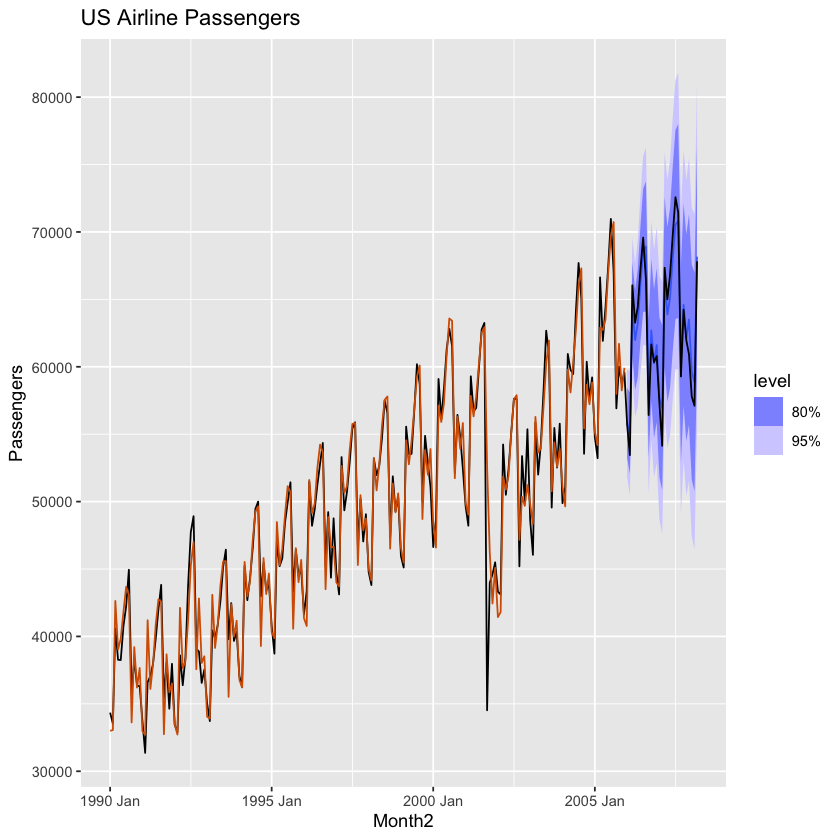

In [152]:
# Plot the data
air.for |>
  autoplot(USAirlines_ts) +
  geom_line(aes(y = .fitted), col="#D55E00",
            data = augment(HWadd.air)) +
  labs(y="Passengers", title="US Airline Passengers") +
  guides(colour = "none")

#### Note: additive vs Multiplicative seasonlity in R: 
- change the component Error, Trend, Seasonal values from "A" to "M"

### Holt Winters: Multiplicative

In [153]:
### Multiplicative model
HWmult.air <- air_train |>
  model(ETS(Passengers ~ error("M") + trend("A") + season("M")))
air.for <- HWmult.air |>
  fabletools::forecast(h = 27)
report(HWmult.air)

Series: Passengers 
Model: ETS(M,A,M) 
  Smoothing parameters:
    alpha = 0.5132388 
    beta  = 0.006772624 
    gamma = 0.0614166 

  Initial states:
     l[0]     b[0]      s[0]     s[-1]    s[-2]     s[-3]    s[-4]    s[-5]
 38328.12 132.2916 0.9879613 0.9516784 1.015964 0.9248462 1.127338 1.111153
    s[-6]    s[-7]     s[-8]    s[-9]    s[-10]    s[-11]
 1.063682 1.012367 0.9931891 1.041972 0.8832477 0.8866022

  sigma^2:  0.0015

     AIC     AICc      BIC 
3922.549 3926.066 3977.926 


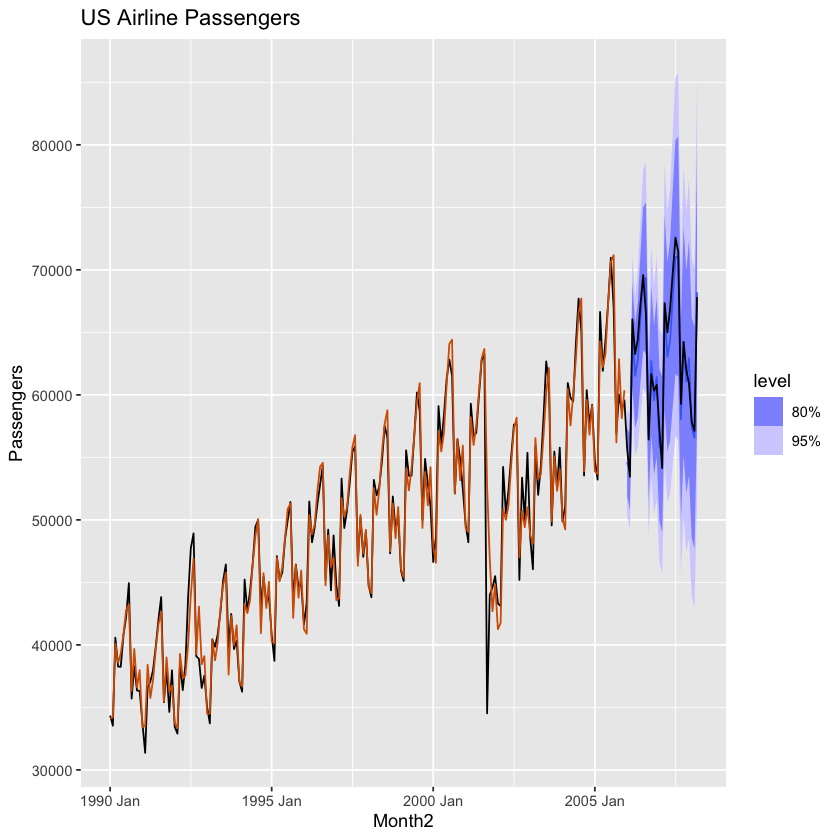

In [154]:
# Plot the data
air.for |>
  autoplot(USAirlines_ts) +
  geom_line(aes(y = .fitted), col="#D55E00",
            data = augment(HWmult.air)) +
  labs(y="Passengers", title="US Airline Passengers") +
  guides(colour = "none")

In [155]:
### All in one

air_fit <- air_train |>
  model(
    SES = ETS(Passengers ~ error("A") + trend("N") + season("N")),
    `Linear` = ETS(Passengers ~ error("A") + trend("A") + season("N")),
    `Damped Linear` = ETS(Passengers ~ error("A") + trend("Ad") + season("N")),
    HWAdd = ETS(Passengers ~ error("A") + trend("A") + season("A")),
    HWMult = ETS(Passengers ~ error("M") + trend("A") + season("M"))
  )

air_fc <- air_fit |>
  fabletools::forecast(h = 27)


fabletools::accuracy(air_fc, USAirlines_ts)

.model,.type,ME,RMSE,MAE,MPE,MAPE,MASE,RMSSE,ACF1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Damped Linear,Test,3351.23560,6251.053,5238.043,4.6475843,8.057662,1.8441468,1.6879095,0.3819013
HWAdd,Test,-175.40806,1461.985,1258.550,-0.4206807,2.024597,0.4430951,0.3947652,0.4476024
HWMult,Test,466.96181,1319.080,1110.115,0.7046275,1.750540,0.3908357,0.3561781,0.2185923
Linear,Test,-67.26453,5344.911,4736.428,-0.7887208,7.621637,1.6675443,1.4432330,0.4360965
SES,Test,3346.49137,6248.422,5236.041,4.6400058,8.054941,1.8434420,1.6871992,0.3818930


### More ETS (Error, Trend, Seasonal) Techniques

In [156]:
# ETS report we want to use the one with the lowest AICc. Can use BIC as well
# top line gives you info about the model he picked: Model: Multiplicative, Additive damped, Multiplicative
air_auto <- air_train |>
  model(ETS(Passengers))
report(air_auto)

Series: Passengers 
Model: ETS(M,Ad,M) 
  Smoothing parameters:
    alpha = 0.6388447 
    beta  = 0.0001026043 
    gamma = 0.0001060611 
    phi   = 0.979993 

  Initial states:
     l[0]     b[0]      s[0]     s[-1]     s[-2]     s[-3]    s[-4]    s[-5]
 38326.08 97.13345 0.9672127 0.9438917 0.9983376 0.9209977 1.132478 1.132414
    s[-6]    s[-7]    s[-8]    s[-9]    s[-10]    s[-11]
 1.079442 1.022098 1.000804 1.051137 0.8657376 0.8854499

  sigma^2:  0.0014

     AIC     AICc      BIC 
3910.149 3914.103 3968.784 


In [157]:
# Now compare this to the HW models:

air_fit <- air_train |>
  model(
    HWAdd = ETS(Passengers ~ error("A") + trend("A") + season("A")),
    HWMult = ETS(Passengers ~ error("M") + trend("A") + season("M")),
    AutoETS = ETS(Passengers ~ error("M") + trend("Ad") + season("M"))
  )

air_fc <- air_fit |>
  fabletools::forecast(h = 27)


fabletools::accuracy(air_fc, USAirlines_ts)


.model,.type,ME,RMSE,MAE,MPE,MAPE,MASE,RMSSE,ACF1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AutoETS,Test,1733.6577,2342.516,2019.586,2.7527821,3.188625,0.7110313,0.6325264,0.5962021
HWAdd,Test,-175.4081,1461.985,1258.550,-0.4206807,2.024597,0.4430951,0.3947652,0.4476024
HWMult,Test,466.9618,1319.080,1110.115,0.7046275,1.750540,0.3908357,0.3561781,0.2185923


### ARIMA
- stationary: underlying constant mean
- underlying constant variance (realtionships from day to day are the same)
- constant correlation structure
- beware of random walks!

##### Random Walk with a Coin Flip

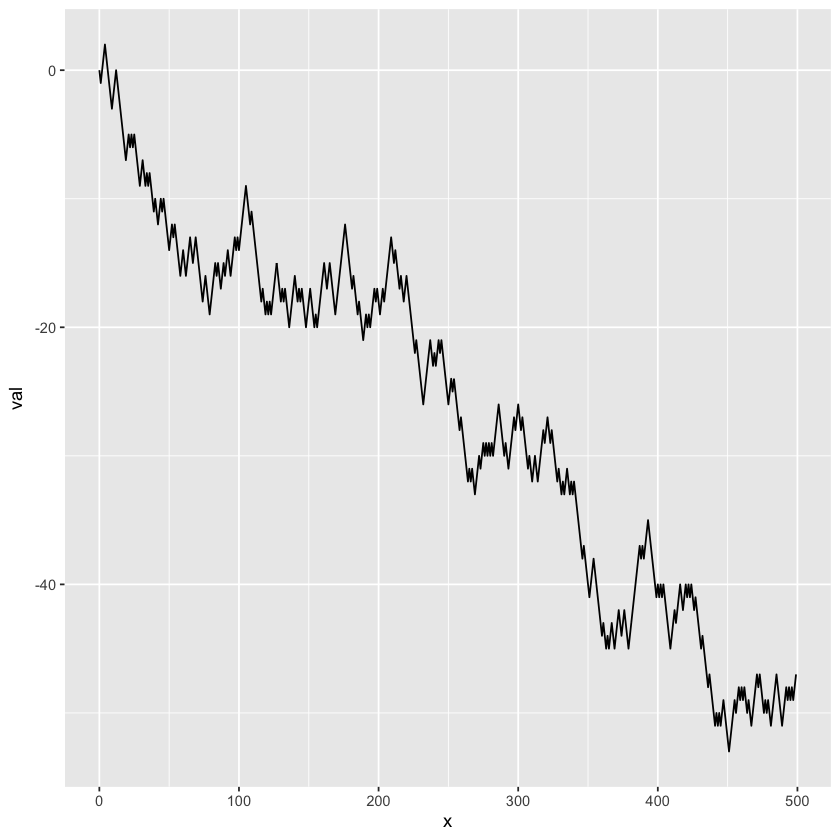

In [158]:
library(ggplot2)
rw<- function(stp_size, ll,start_val){ 
temp <-sample(c(stp_size,-stp_size),(ll-1),replace=T) 
val<-rep(start_val,ll) + c(0,cumsum(temp)) 
dat<-data.frame(val,x=0:(length(val)-1)) 
return(dat)}
temp2<-rw(1,500,0)
ggplot(temp2,aes(x=x,y=val))+geom_line()

### Unit Root Tests - need the Quotes csv

In [159]:
Quotes <- read.csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/fpp_insurance.csv")

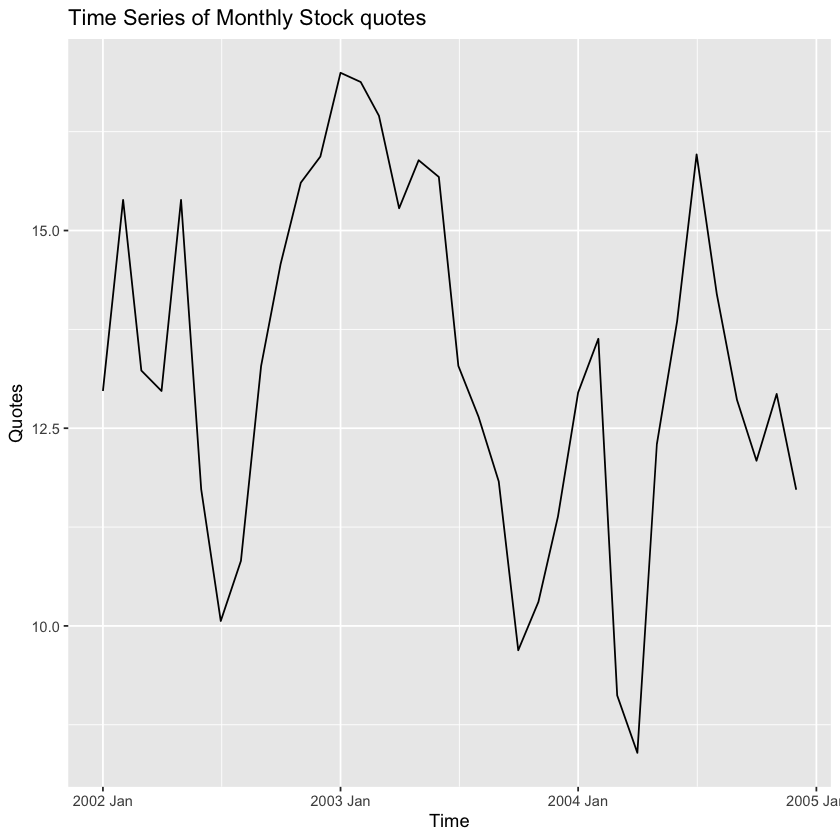

In [160]:
Quotes.ts<-Quotes |> mutate(date = seq(ymd('2002-01-01'),ymd('2005-04-01'),by='months')) |>
mutate(month=yearmonth(date)) |> as_tsibble(index=month)

Quotes_train<-Quotes.ts %>% filter(year(date)<2005)

autoplot(Quotes_train,Quotes)+labs(title="Time Series of Monthly Stock quotes", x="Time", y="Quotes")

In [161]:
Quotes_train |> features(Quotes, unitroot_kpss)
Quotes_train |> features(Quotes, unitroot_ndiffs)

kpss_stat,kpss_pvalue
<dbl>,<dbl>
0.1970917,0.1


ndiffs
<int>
0


#### Hurricanes

In [162]:
hurricane <- read.csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/hurrican.csv")

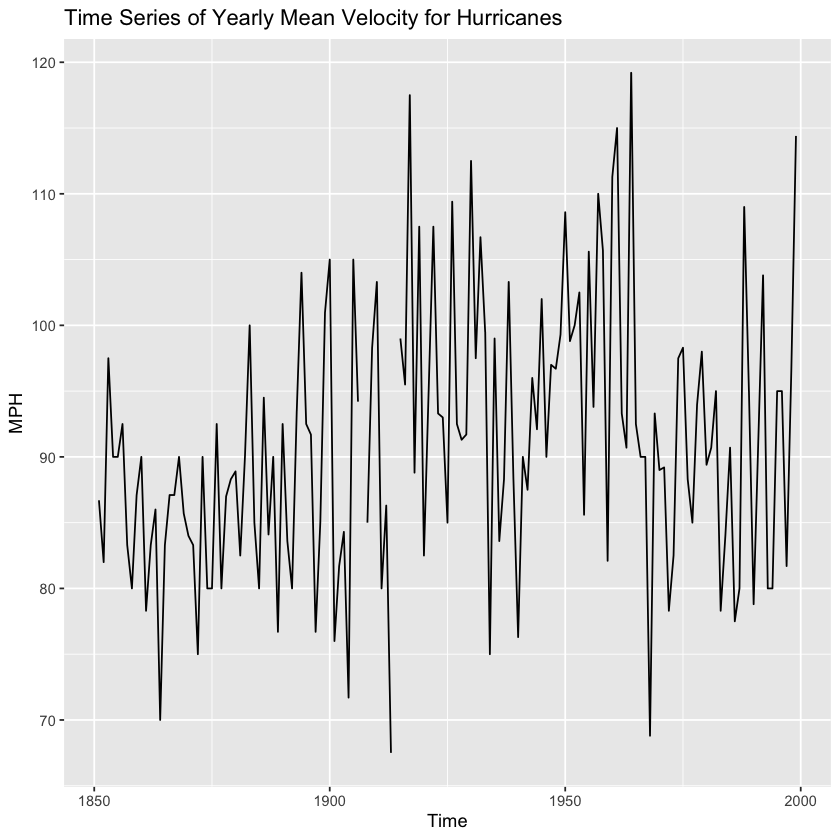

In [163]:
Hurricane.ts<- hurricane %>% as_tsibble(index=Year)

Hurricane_train <-Hurricane.ts %>% filter(Year <2000)

autoplot(Hurricane_train,MeanVMax)+labs(title="Time Series of Yearly Mean Velocity for Hurricanes", x="Time", y="MPH")

In [164]:
Hurricane_train %>% features(MeanVMax,unitroot_ndiffs)

ndiffs
<int>
1


### Checking Unit Root on the Diffs - did it work?
- yes, diff is 0

In [165]:
Hurricane_train <- Hurricane_train %>% mutate(mean_diff=difference(MeanVMax))
Hurricane_train %>% features(mean_diff,unitroot_ndiffs)

ndiffs
<int>
0


#### Plot the Stationary (Differenced) Data - no seasonality, no trend
- ndiffs = 0
- next step will be to model "AR" and "MA" terms

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


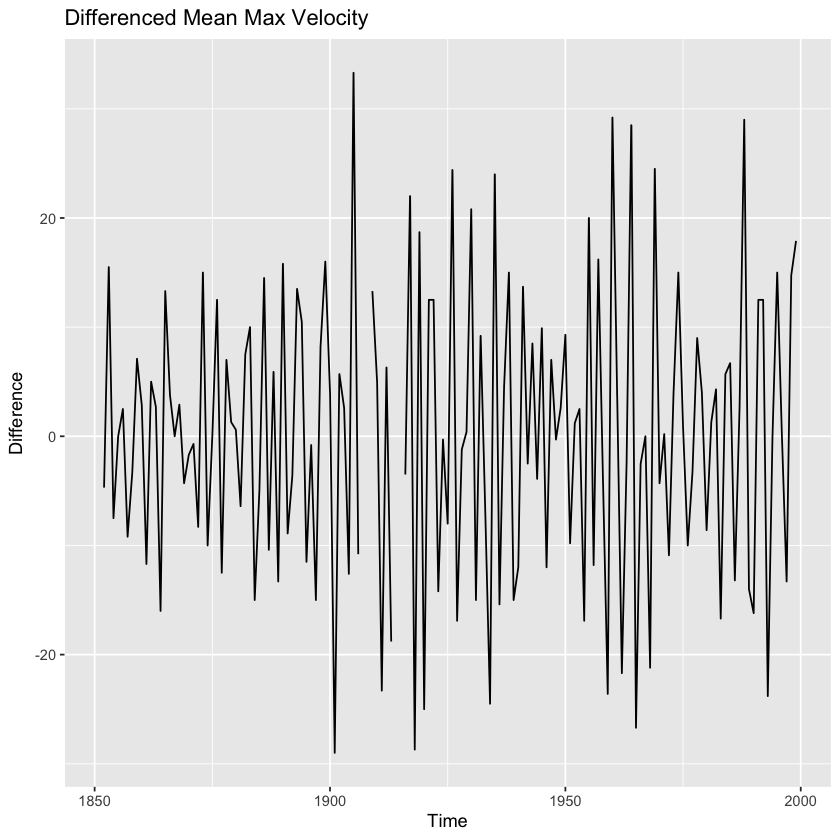

In [166]:
autoplot(Hurricane_train,mean_diff)+labs(title="Differenced Mean Max Velocity", x="Time", y="Difference")

### Correlation Functions

In [7]:
library(fpp3)
library(forecast)
library(tidyverse)

#### AutoCorrelation Functions (ACF)
- looking for big spikes/outside of bands

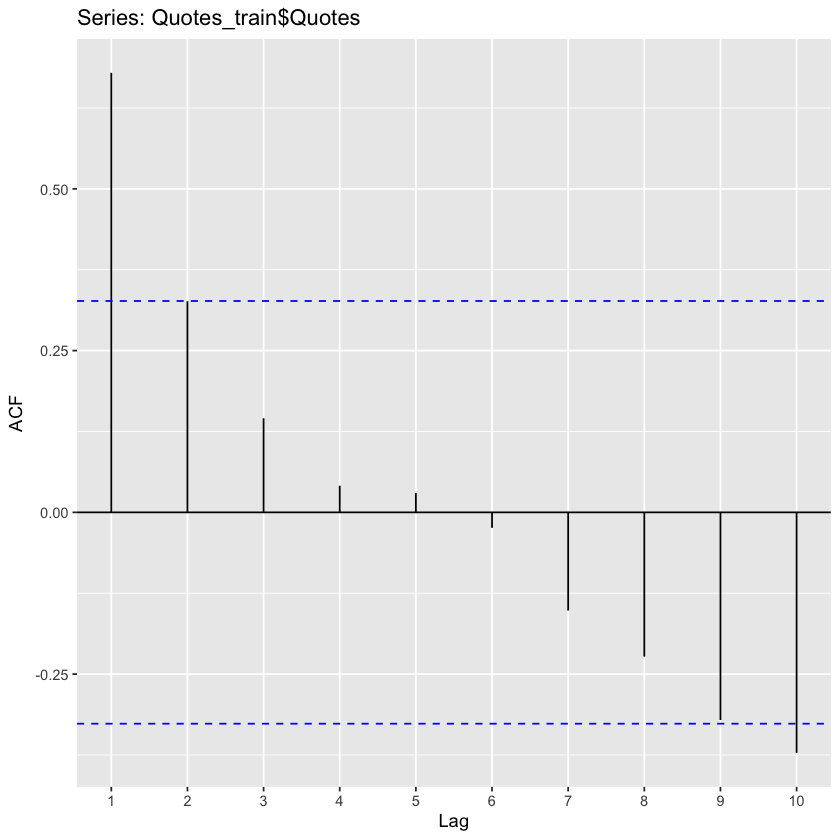

In [168]:
ggAcf(Quotes_train$Quotes,lag=10)

#### Partial AutoCorrelation Function - removing time points in between
- direct correlation
- adjusts the impacts of information in between - removes 'bleed over' from previous data points

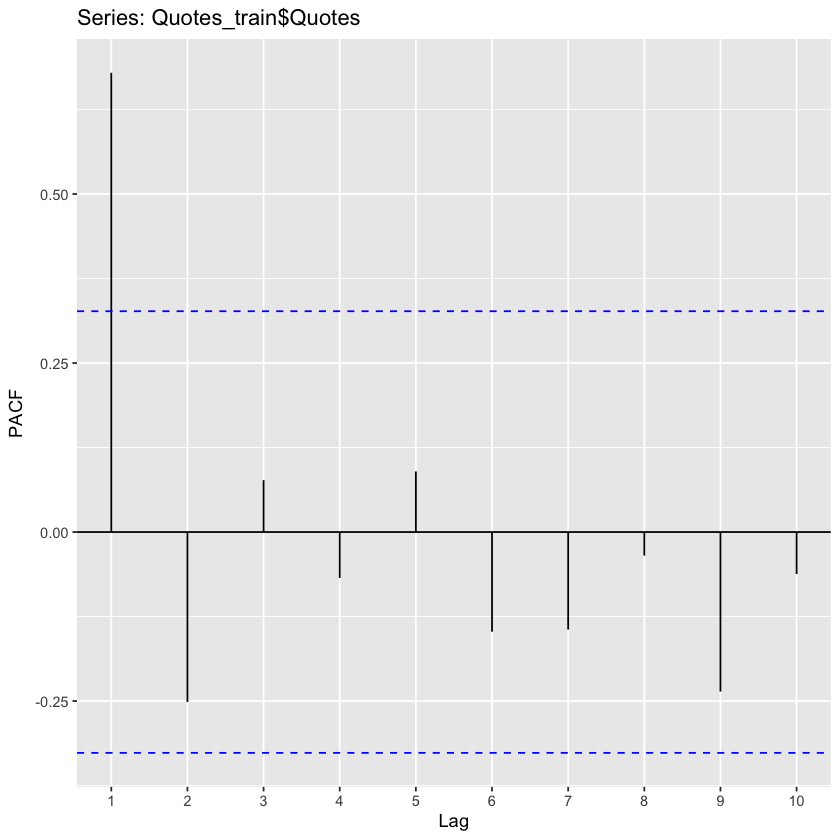

In [169]:
ggPacf(Quotes_train$Quotes,lag=10)

#### Try some models - now that we have seen ACF/PACF spikes at 1

In [170]:
library(tidyverse)

In [175]:
quotes_model <-Quotes_train %>%
  model(ar1 = ARIMA(Quotes ~ pdq(1,0,0) + PDQ(0,0,0)),
        ma1 = ARIMA(Quotes ~ pdq(0,0,1) + PDQ(0,0,0)),
        search1 = ARIMA(Quotes),
        search2 = ARIMA(Quotes,stepwise = F))

quotes_model2<-as.data.frame(quotes_model)

t(quotes_model2)


ar1,"ar1, constant, 0.6712095, 4.336718, 0.118225, 0.2566546, 5.677392, 16.8971, 1.875905e-06, 1.069124e-18, 13.13318, 13.04274, 14.66471, 13.21653, 13.04274, 14.66471, 12.20523, 11.09027, 11.60108, 13.25513, 14.12182, 14.81122, 15.03254, 15.74383, 15.66553, 15.37897, 14.59359, 15.00157, 14.85958, 13.25562, 12.82405, 12.27559, 10.84197, 11.25296, 11.97678, 13.02988, 13.48592, 10.45881, 9.971307, 12.59311, 13.63184, 15.05087, 13.86613, 12.96795, 12.45055, 13.01797, -0.1625326, 2.344398, -1.435143, -0.2458812, 2.344398, -2.941833, -2.143457, -0.2674838, 1.685992, 1.323194, 1.483595, 1.123926, 1.962318, 1.134381, 0.7857471, -0.09779343, 1.295419, 0.6758975, -1.571785, -0.6107757, -0.9963448, -2.583749, -0.5378233, 0.1295685, 0.9747096, 0.6010388, -4.364941, -2.064127, 2.329453, 1.255205, 2.330625, -0.8534928, -1.006914, -0.8795787, 0.4832031, -1.295624, -0.219263, 2.197227, 0.03965701, -0.219263, 2.197227, -1.467033, -3.128143, -2.367123, 0.09715701, 1.388407, 2.415507, 2.745237, 3.804947, 3.688297, 3.261367, 2.091267, 2.699097, 2.487557, 0.09788701, -0.545073, -1.362203, -3.498073, -2.885763, -1.807383, -0.238423, 0.441007, -4.068933, -4.795233, -0.889153, 0.658397, 2.772547, 1.007467, -0.330693, -1.101543, -0.256163, -1.467563, 2.785908, -68.79466, 143.5893, 144.3393, 148.3399, 1.489848+0i, 11688, 12753, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, TRUE, 12, 0.6712095, 13.18991, 2.785908, 0.01397714, -0.005444108, -0.005444108, 0.60934, TRUE, TRUE, -68.79466, 143.5893, 1, 0, 0, 0, 12, 0, 0, -0.1625326, 2.344398, -1.435143, -0.2458812, 2.344398, -2.941833, -2.143457, -0.2674838, 1.685992, 1.323194, 1.483595, 1.123926, 1.962318, 1.134381, 0.7857471, -0.09779343, 1.295419, 0.6758975, -1.571785, -0.6107757, -0.9963448, -2.583749, -0.5378233, 0.1295685, 0.9747096, 0.6010388, -4.364941, -2.064127, 2.329453, 1.255205, 2.330625, -0.8534928, -1.006914, -0.8795787, 0.4832031, -1.295624, .f(x = ..1, order = ..2, seasonal = ..3, xreg = ..4, include.mean = FALSE, , fixed = ..7, method = ..5), y, 0, 0, 36, 0.6712095, 1, -1.467563, 0, 0.6712095, 1, 0, 1, 148.3399, 144.3393, <environment: 0x11202bba0>, 11688, 11719, 11747, 11778, 11808, 11839, 11869, 11900, 11931, 11961, 11992, 12022, 12053, 12084, 12112, 12143, 12173, 12204, 12234, 12265, 12296, 12326, 12357, 12387, 12418, 12449, 12478, 12509, 12539, 12570, 12600, 12631, 12662, 12692, 12723, 12753, 12.97065, 15.38714, 13.22957, 12.97065, 15.38714, 11.72288, 10.06177, 10.82279, 13.28707, 14.57832, 15.60542, 15.93515, 16.99486, 16.87821, 16.45128, 15.28118, 15.88901, 15.67747, 13.2878, 12.64484, 11.82771, 9.69184, 10.30415, 11.38253, 12.95149, 13.63092, 9.12098, 8.39468, 12.30076, 13.84831, 15.96246, 14.19738, 12.85922, 12.08837, 12.93375, 11.72235, Quotes, structure(function (Quotes) , Quotes, class = ""transformation"", inverse = function (Quotes) , Quotes)"
ma1,"ma1, constant, 0.7502422, 13.22263, 0.09813991, 0.464763, 7.644619, 28.45025, 4.77339e-09, 2.856824e-26, 13.17221, 13.30315, 14.58543, 12.26742, 13.75898, 14.40925, 11.21692, 12.35601, 12.0764, 14.13011, 13.55946, 14.75724, 14.1065, 15.38943, 14.33958, 14.80686, 13.5785, 14.95605, 13.76386, 12.86547, 13.0571, 12.30028, 11.26566, 12.50126, 12.38331, 13.6489, 13.20914, 10.15552, 11.90157, 13.52211, 13.46735, 15.09456, 12.54952, 13.45497, 12.19734, 13.77511, -0.201557, 2.083987, -1.355855, 0.7032309, 1.628163, -2.686367, -1.155151, -1.533217, 1.210671, 0.4482147, 2.045955, 1.177905, 2.888356, 1.488783, 2.111702, 0.4743188, 2.31051, 0.7214192, -0.476059, -0.2206269, -1.229391, -2.608444, -0.9615117, -1.118729, 0.5681819, -0.01797951, -4.088156, -1.760838, 0.3991895, 0.3261957, 2.495109, -0.8971814, 0.3096979, -1.366604, 0.7364085, -2.05276, -0.2519755, 2.164514, 0.00694449, -0.2519755, 2.164514, -1.499746, -3.160856, -2.399836, 0.06444449, 1.355694, 2.382794, 2.712524, 3.772234, 3.655584, 3.228654, 2.058554, 2.666384, 2.454844, 0.06517449, -0.5777855, -1.394916, -3.530786, -2.918476, -1.840096, -0.2711355, 0.4082945, -4.101646, 

In [172]:
glance(quotes_model) %>% arrange(AICc) %>% select(.model:BIC)

.model,sigma2,log_lik,AIC,AICc,BIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
search1,2.542801,-66.78471,141.5694,142.8597,147.9035
search2,2.542801,-66.78471,141.5694,142.8597,147.9035
ma1,2.750904,-68.68142,143.3628,144.1128,148.1134
ar1,2.785908,-68.79466,143.5893,144.3393,148.3399


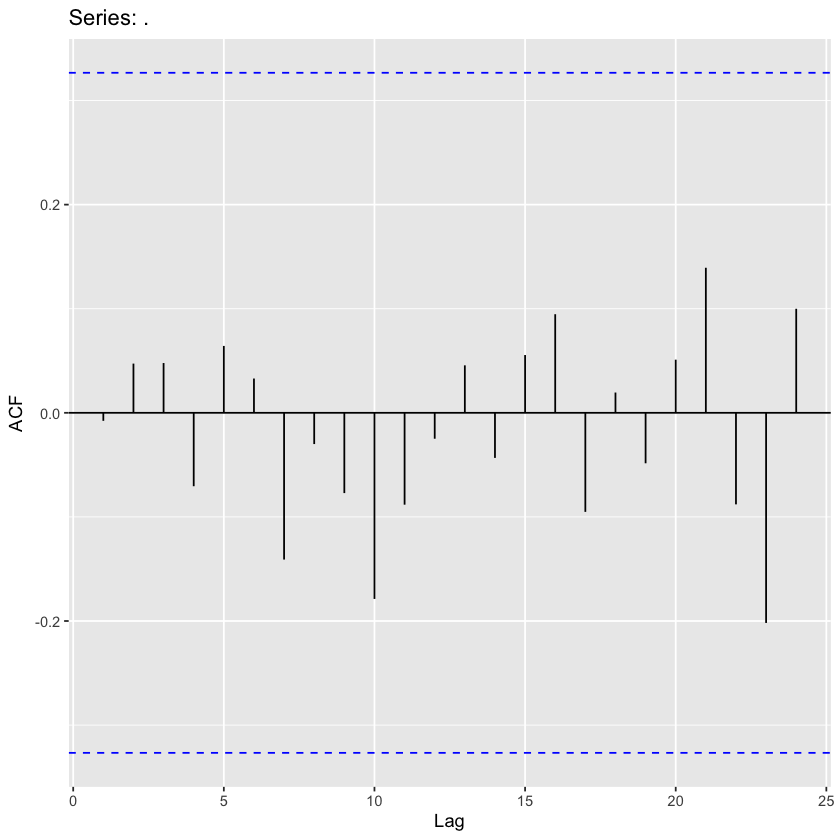

In [176]:
quotes_model %>% select(search1) %>% residuals() %>% ggAcf()

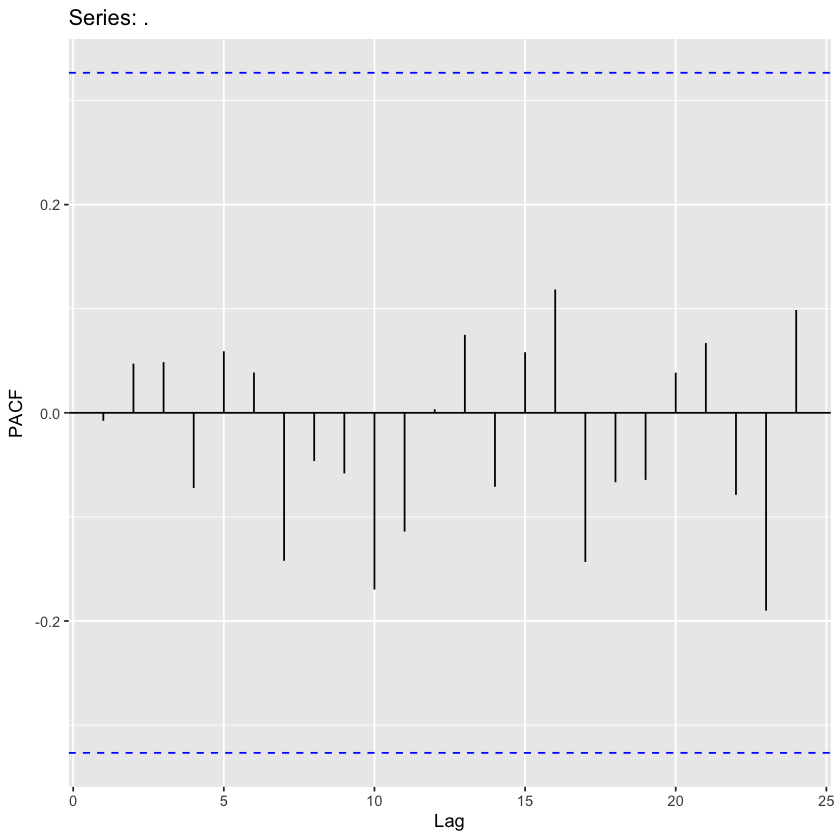

In [177]:
quotes_model %>% select(search1) %>% residuals() %>% ggPacf()

#### Check the residuals to see if we have modeled all the Correlation

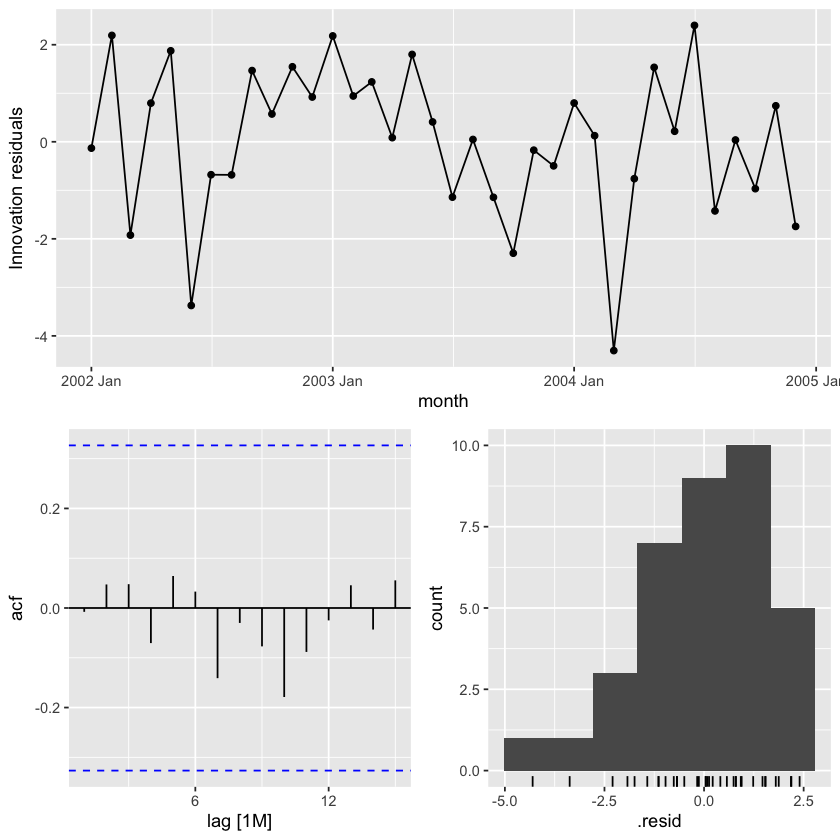

In [178]:
quotes_model %>% select(search1) %>% gg_tsresiduals()

#### Check for remaining Auto-Correlatiomn with Ljung-Box
- H0: no auto correlation

In [179]:
augment(quotes_model) %>% filter(.model=='search1') %>% features(.innov,ljung_box, lag=10, dof = 2)

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
search1,3.596194,0.8915972


##### Takeaway - no Auto Correlation.
- failed to reject H0, due to high p-value

### 1. Hurricane Data - not stationary. Let's run through the example

### Auto-Regressive Modeling. ARIMA step one Model
- current value of Y, with a lag value
- essentially, mdoeling the Y's we know with their past values
- Fi: the AR coefficient
- so: the relationship between t and t-1

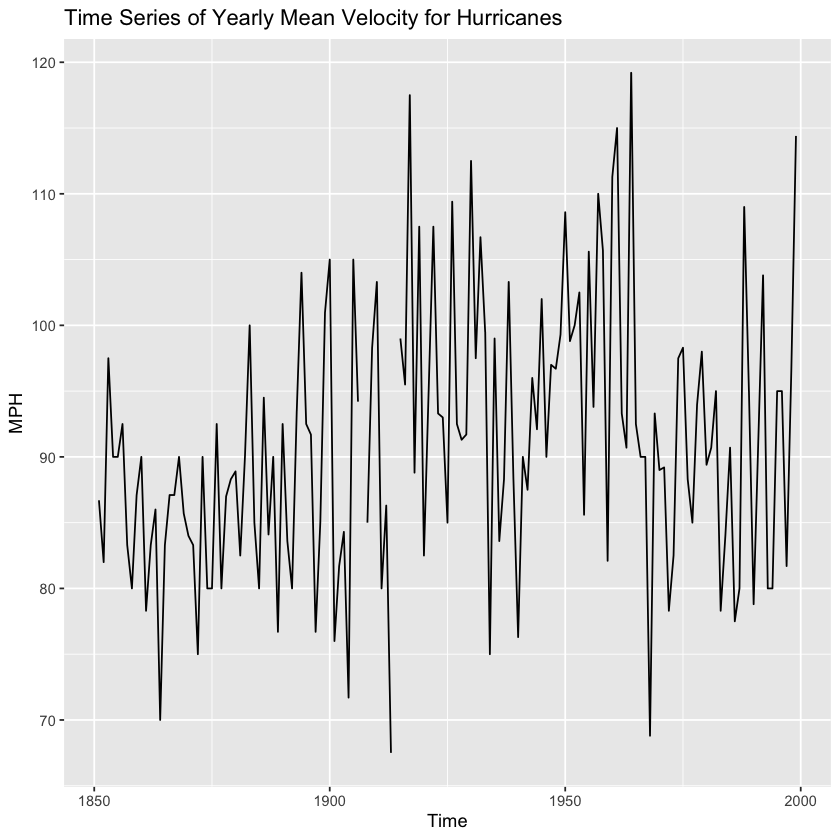

In [180]:
Hurricane.ts<- hurricane %>% as_tsibble(index=Year)

Hurricane_train <-Hurricane.ts %>% filter(Year <2000)

autoplot(Hurricane_train,MeanVMax)+labs(title="Time Series of Yearly Mean Velocity for Hurricanes", x="Time", y="MPH")

### Is the data stationary? Check with Ndiffs (is there a random walk?):
- if = 1: yes, take the difference

In [181]:
Hurricane_train %>% features(MeanVMax,unitroot_ndiffs)

ndiffs
<int>
1


### Create a plot with a differenced column:

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`)."


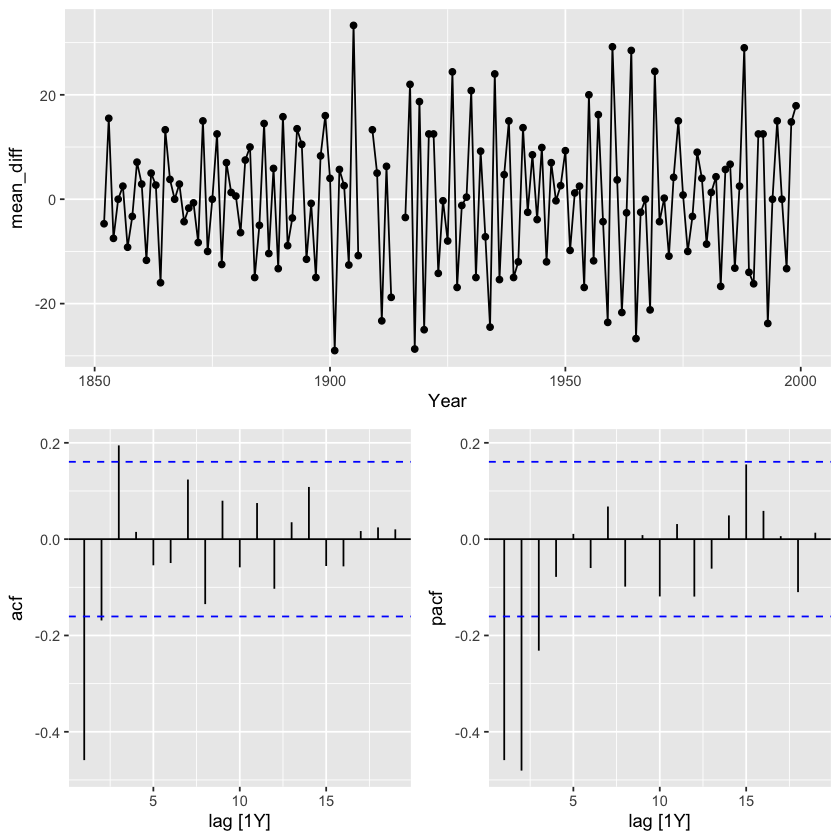

In [182]:
Hurricane_train <- Hurricane_train %>% mutate(mean_diff=difference(MeanVMax))

Hurricane_train %>% gg_tsdisplay(mean_diff,plot_type = 'partial')

### What kind of trends to we have? Run PACF/ACF to look for count of AR + MA terms

In [183]:
hurr_model <-Hurricane_train %>%
  model(ar3 = ARIMA(MeanVMax ~ 0 + pdq(3,1,0) + PDQ(0,0,0)),
        ma2 = ARIMA(MeanVMax ~ 0 + pdq(0,1,2) + PDQ(0,0,0)),
        arima32 = ARIMA(MeanVMax~0 + pdq(3,1,2) + PDQ(0,0,0)),
        search1 = ARIMA(MeanVMax),
        search2 = ARIMA(MeanVMax,stepwise = F))

hurr_model2<-as.data.frame(hurr_model)

t(hurr_model2)



ar3
ma2
arima32
search1
search2


In [184]:
glance(hurr_model) %>% arrange(AICc) %>% select(.model:BIC)

.model,sigma2,log_lik,AIC,AICc,BIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
arima32,94.60665,-538.9024,1089.805,1090.401,1107.788
ma2,97.36121,-542.3252,1090.650,1090.817,1099.642
search2,93.05631,-540.1616,1094.323,1095.118,1115.351
search1,96.28303,-543.9478,1095.896,1096.173,1107.911
ar3,107.88596,-549.0493,1106.099,1106.378,1118.088


#### Check residuals for best models: MA2, and ARIMA32

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_bin()`)."


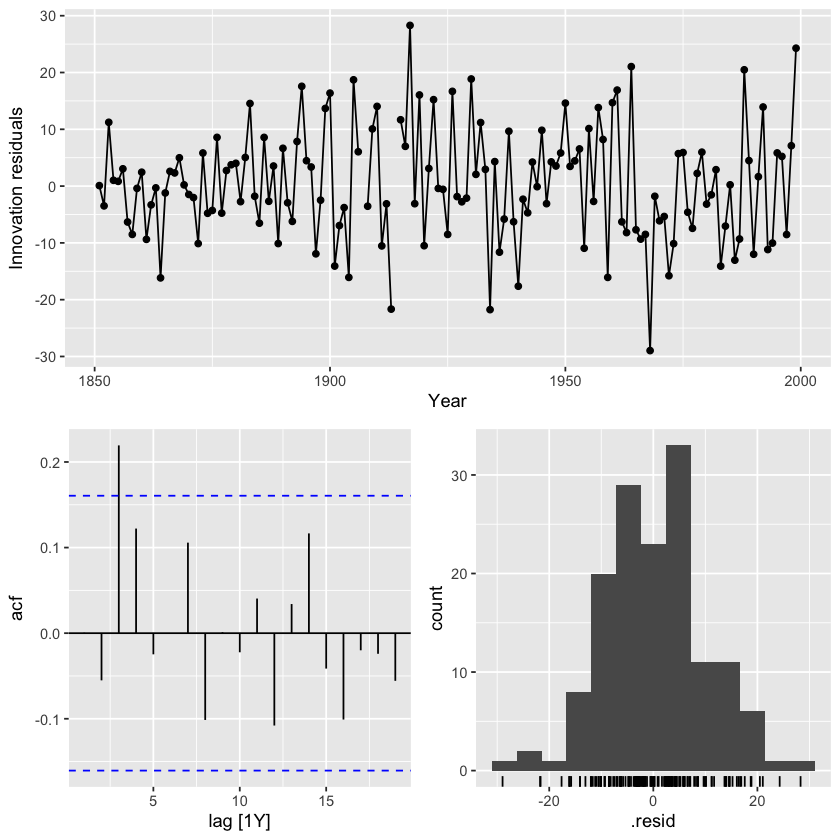

In [185]:
hurr_model %>% select(ma2) %>% gg_tsresiduals()

#### Takeaway for MA2:
- still see a spike in ACF
- LB test would also show autocorrelation
- this will not be the final model

#### ARIMA 32 model evaluation

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_bin()`)."


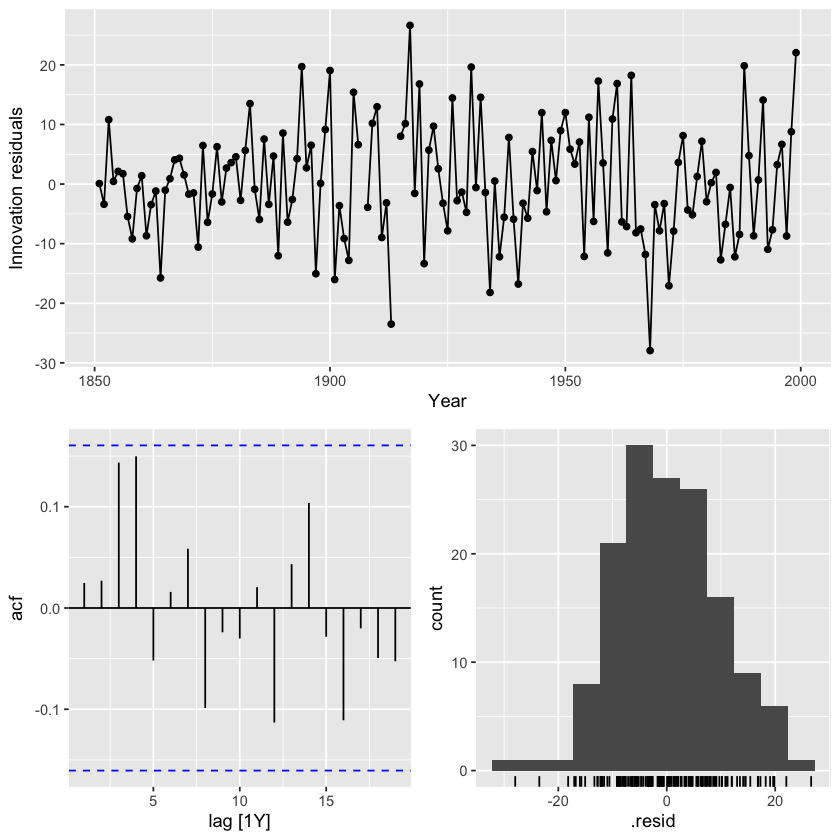

In [187]:
hurr_model %>% select(arima32) %>% gg_tsresiduals()

#### Takeaways from the ARIMA 32 Model:
- normally distributed
- No ACF spike outside of the normal range
- this will be the final model

### Forecasting with Quotes:
- MAE: not scale invariant. add some form of measure of the variance of the data
- use the Quotes dataset (stock quotes)

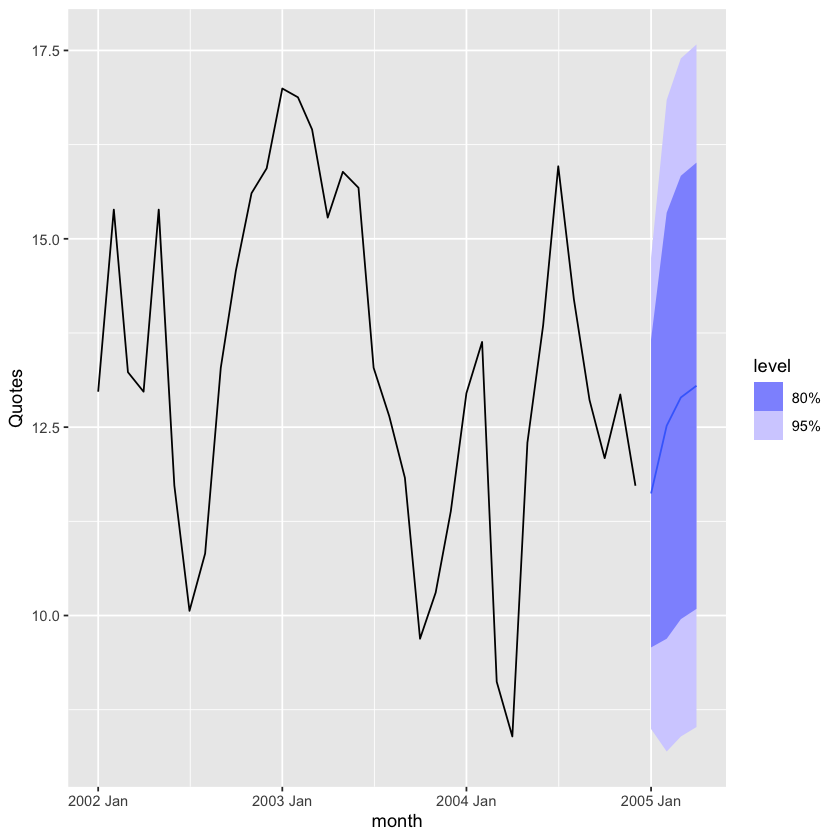

In [188]:
quotes_model %>% select(search1) %>% fabletools::forecast(h=4) %>% autoplot(Quotes_train)

In [189]:
quotes_for<-quotes_model %>% select(search1) %>% fabletools::forecast(h=4)

quotes_resid<-Quotes$Quotes[37:40]-quotes_for$.mean
MAPE<-mean(abs(quotes_resid/Quotes$Quotes[37:40]))
MAE<-mean(abs(quotes_resid))
MAPE

[1] 0.2330841

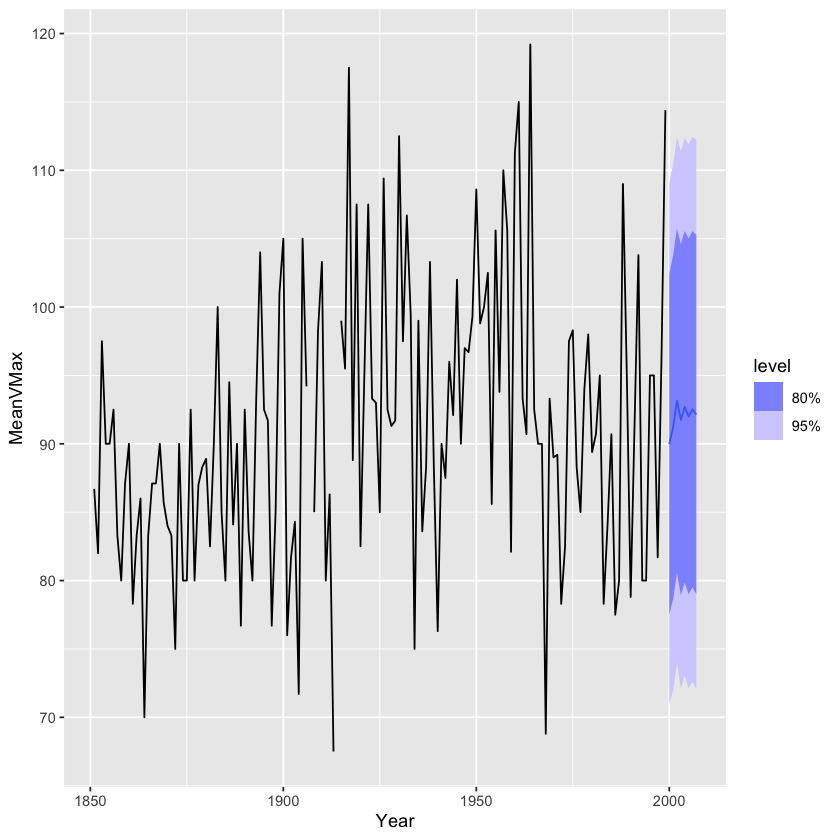

In [190]:
hurr_model %>% select(arima32) %>% fabletools::forecast(h=8) %>% autoplot(Hurricane_train)

### Trending Time Series

In [26]:
consume <- read.csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/consume1982.csv")
head(consume)

,date,Disposable_income
,<chr>,<dbl>
1,Sep-82,2332.176
2,Oct-82,2341.955
3,Nov-82,2369.082
4,Dec-82,2390.061
5,Jan-83,2397.035
6,Feb-83,2389.377


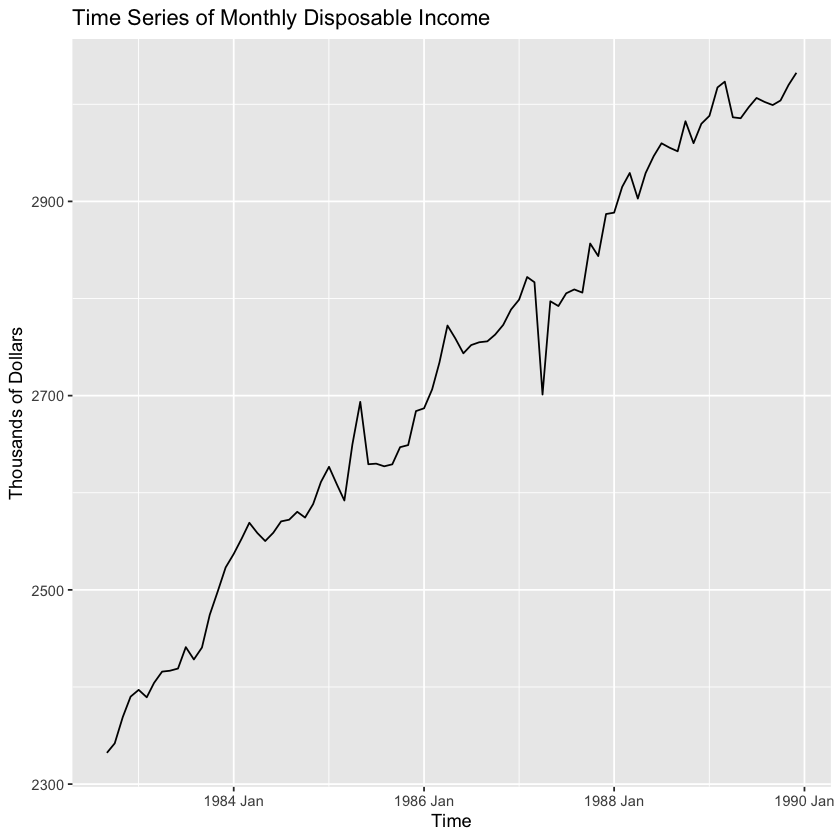

In [27]:
consume.ts<- consume |> mutate(date2=my(date))|> mutate(month=yearmonth(date2)) |> as_tsibble(index=month)

consume_train<-consume.ts %>% filter(year(date2)<1990)

autoplot(consume_train,Disposable_income)+labs(title="Time Series of Monthly Disposable Income", x="Time", y="Thousands of Dollars")

#### 1. Create a Differenced Series (to remove the trend)

In [28]:
ndiffs(consume_train$Disposable_income)

ERROR: Error in ndiffs(consume_train$Disposable_income): could not find function "ndiffs"


Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


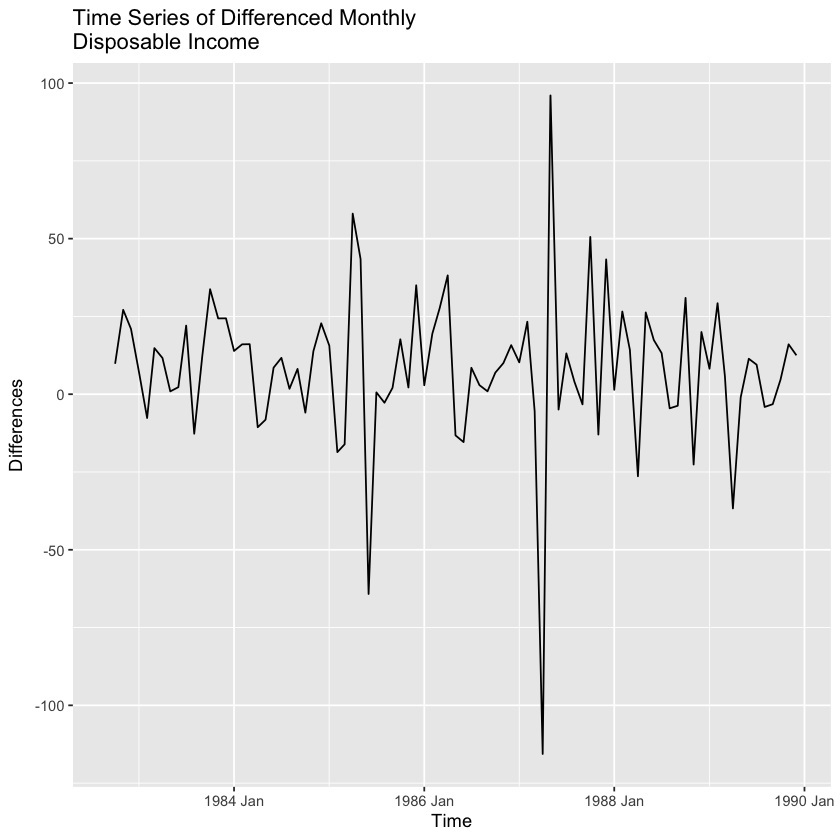

In [29]:
consume_train<-consume.ts %>% filter(year(date2)<1990)
consume_train<- consume_train %>% mutate(income_diff = 
difference(Disposable_income))
autoplot(consume_train,income_diff)+labs(title="Time Series of Differenced Monthly 
Disposable Income", x="Time", y="Differences")

#### Look for spikes in the ACF (AR) and PACF (MA) graphs

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_point()`)."


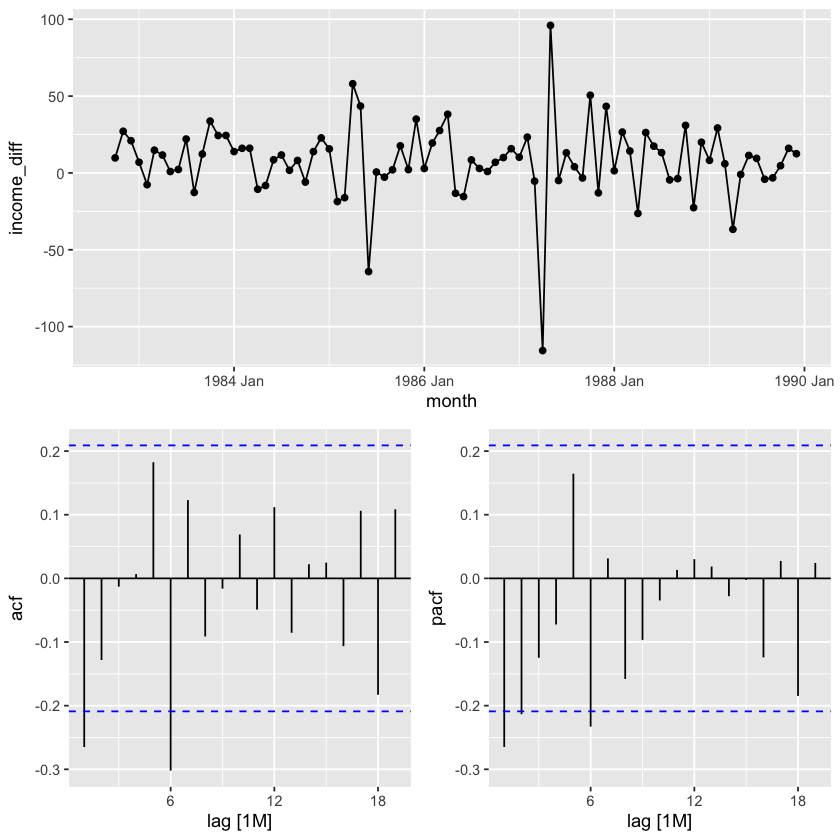

In [30]:
consume_train %>% gg_tsdisplay(income_diff,plot_type = 'partial')

In [31]:
consume_model <-consume_train %>% 
    model(ar1 = ARIMA(Disposable_income ~ pdq(1,1,0) + PDQ(0,0,0)), 
    ma1 = ARIMA(Disposable_income ~ pdq(0,1,1) + PDQ(0,0,0)), 
    ar6 = ARIMA(Disposable_income ~ pdq(6,1,0) + PDQ(0,0,0)), 
    ma6 = ARIMA(Disposable_income ~ pdq(0,1,6) + PDQ(0,0,0)), 
    search1 = ARIMA(Disposable_income), 
    search2 = ARIMA(Disposable_income,stepwise = F))
    consume_model2<-as.data.frame(consume_model)
t(consume_model2)

glance(consume_model) %>% arrange(AICc) %>% select(.model:BIC)


ar1
ma1
ar6
ma6
search1
search2


.model,sigma2,log_lik,AIC,AICc,BIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ma1,545.6705,-396.6613,799.3225,799.6117,806.7202
search1,545.6705,-396.6613,799.3225,799.6117,806.7202
search2,545.6705,-396.6613,799.3225,799.6117,806.7202
ar6,520.1097,-392.1708,800.3416,802.1877,820.0688
ar1,570.8393,-398.5659,803.1318,803.4209,810.5295
ma6,610.4192,-399.7644,813.5287,814.9464,830.7901


#### Check out the MA1 Model:

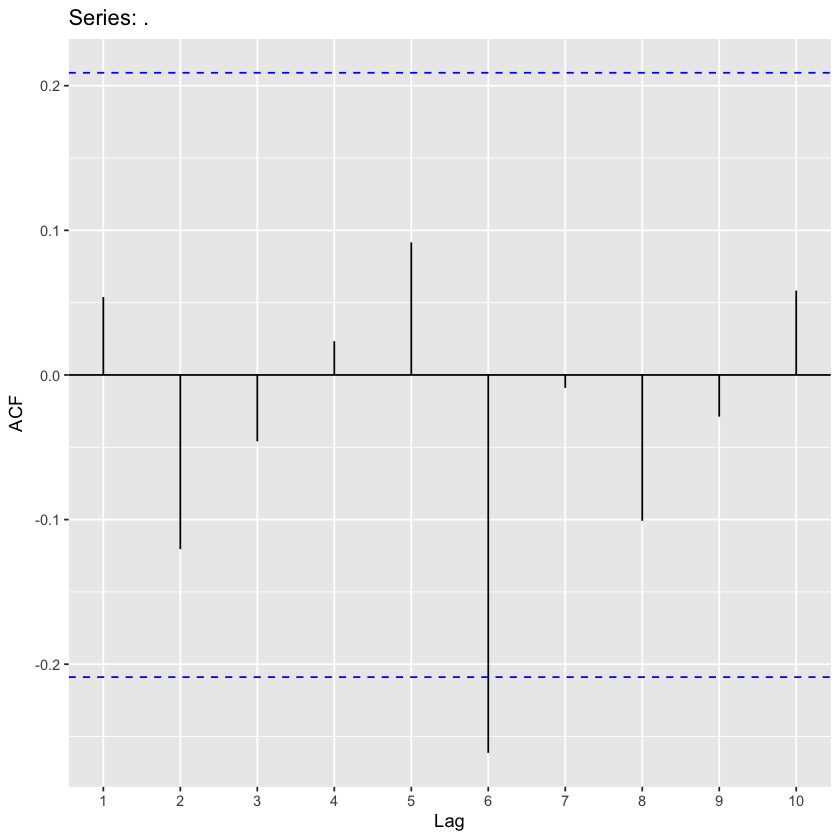

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
ma1,10.68682,0.2977881


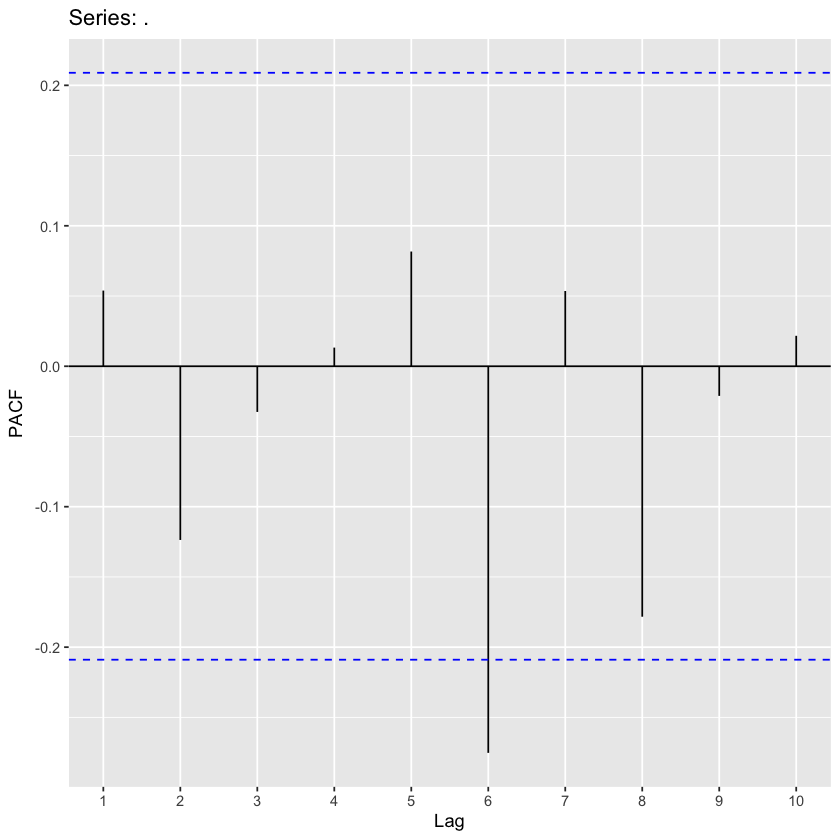

In [199]:
consume_model %>% select(ma1) %>% residuals() %>% ggAcf(lag.max = 10)
consume_model %>% select(ma1) %>% residuals() %>% ggPacf(lag.max = 10)
augment(consume_model) %>% filter(.model=='ma1') %>% features(.innov,ljung_box, lag=10, dof = 1)

### Takeaway: we see the plots still have an ACF/PACF spike, although our LB test says it's within tolerance

### Let's try another model: AR6

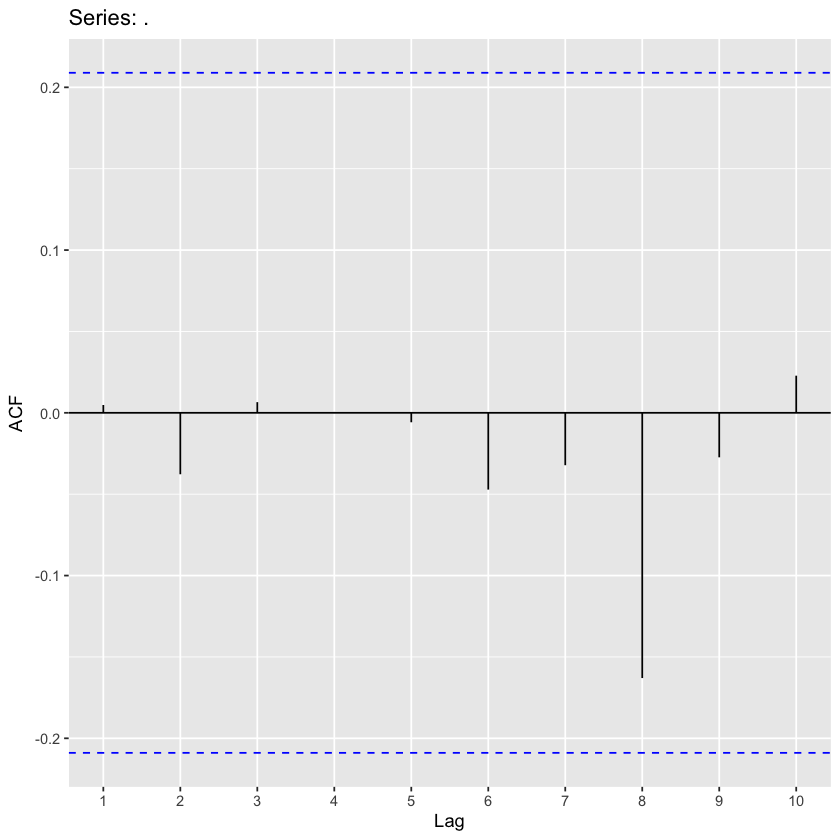

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
ar6,3.214432,0.5226031


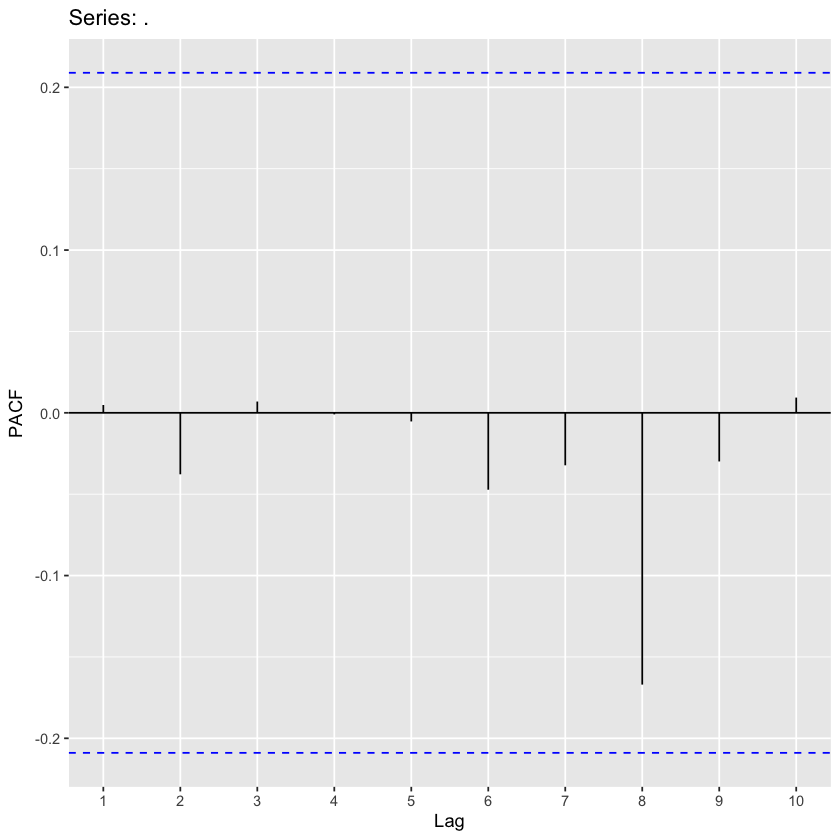

In [200]:
consume_model %>% select(ar6) %>% residuals() %>% ggAcf(lag.max = 10)
consume_model %>% select(ar6) %>% residuals() %>% ggPacf(lag.max = 10)
augment(consume_model) %>% filter(.model=='ar6') %>% features(.innov,ljung_box, lag=10, dof = 6)

#### Takeaway: this one is way better - passes the visual tests of ACF/PACF and LB test.
- select this model

In [201]:
pred_ar6 <- consume_model %>% select(ar6) %>% fabletools::forecast(h=6)
error_ar6 <- consume$Disposable_income[89:94] - pred_ar6$.mean
MAPE_ar6 <-mean(abs(error_ar6/consume$Disposable_income[89:94]))
MAE_ar6 <- mean(abs(error_ar6))


In [202]:
MAPE_ar6
MAE_ar6

[1] 0.006767987

[1] 20.56257

### Raleigh Housing Example

In [12]:
library(tidyverse)

In [17]:
Raleigh <- read.csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/Raleighhouse.csv")

In [18]:
head(Raleigh)

,DATE,price_index
,<chr>,<dbl>
1,1/1/2000,121.11
2,4/1/2000,121.90
3,7/1/2000,123.38
4,10/1/2000,124.57
5,1/1/2001,126.79
6,4/1/2001,127.92


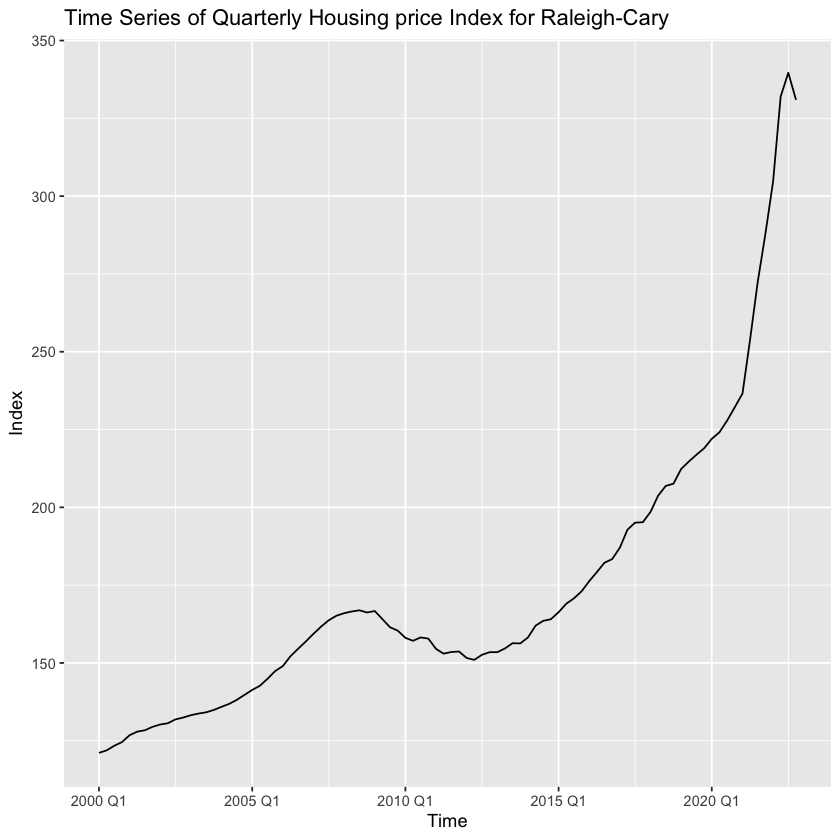

In [19]:
Raleigh.ts<- Raleigh %>% mutate(quarter=yearquarter(DATE)) %>% as_tsibble(index=quarter)

Raleigh_train <-Raleigh.ts %>% filter(quarter <yearquarter("2023 Q1"))

autoplot(Raleigh_train,price_index)+labs(title="Time Series of Quarterly Housing price Index for Raleigh-Cary", x="Time", y="Index")

In [20]:
Raleigh_train %>% features(price_index,unitroot_ndiffs)

ndiffs
<int>
2


Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`)."


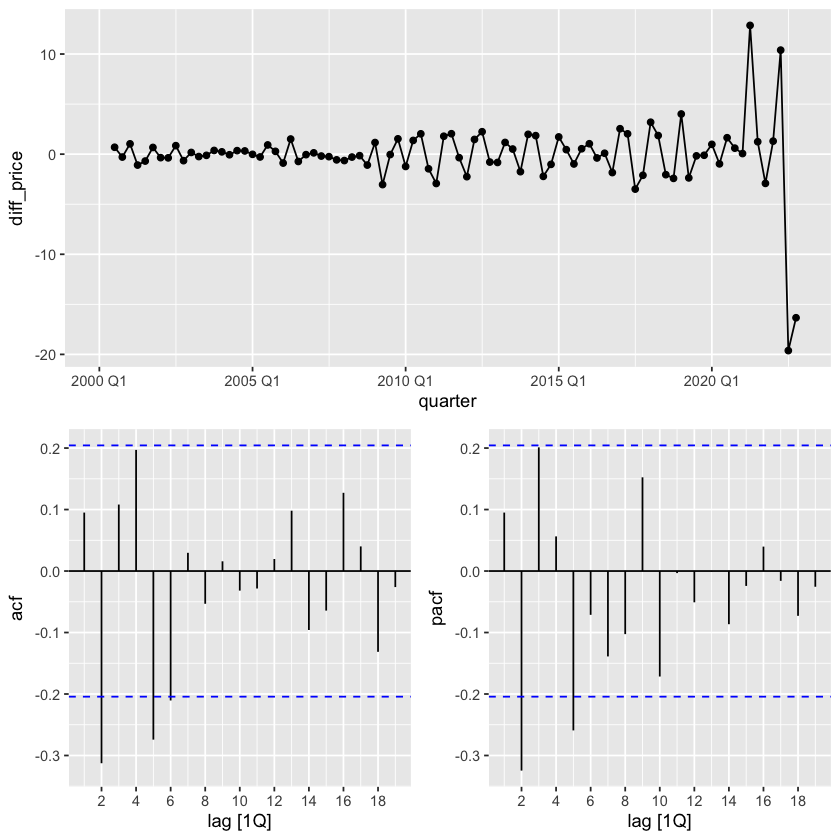

In [21]:
Raleigh_train <- Raleigh_train %>% mutate(diff_price=difference(difference(price_index)))

Raleigh_train %>% gg_tsdisplay(diff_price,plot_type = 'partial')

In [22]:
Raleigh_model <-Raleigh_train %>%
  model(
        ma5 = ARIMA(price_index ~ pdq(0,2,5)+ PDQ(0,0,0)+0),
        ar2 = ARIMA(price_index ~ pdq(2,2,0)+ PDQ(0,0,0)+0),
        ma2 = ARIMA(price_index ~ pdq(0,2,2)+ PDQ(0,0,0)+0),
        search1 = ARIMA(price_index~PDQ(0,0,0)),
        search2 = ARIMA(price_index,stepwise = FALSE)
        )

Raleigh_model2<-as.data.frame(Raleigh_model)
t(Raleigh_model2)

ma5
ar2
ma2
search1
search2


In [23]:
glance(Raleigh_model) %>% arrange(AICc) %>% select(.model:BIC)

.model,sigma2,log_lik,AIC,AICc,BIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ma5,7.646308,-219.4104,450.8209,451.8329,465.8197
search2,7.646308,-219.4104,450.8209,451.8329,465.8197
search1,8.355466,-222.5903,455.1805,455.8948,467.6795
ar2,9.501725,-228.7792,463.5585,463.8375,471.0579
ma2,10.083476,-231.2456,468.4911,468.7702,475.9906


### ARIMA X
- x is time in this example
- disposable income
- fitting a linear model

In [32]:
# fit a line
consume_linear <-consume_train %>% model(trend1 = ARIMA(Disposable_income~ trend() + 
pdq(0,0,0) + PDQ(0,0,0)+1) )
report(consume_linear)

Series: Disposable_income 
Model: LM w/ ARIMA(0,0,0) errors 

Coefficients:
      trend()  intercept
       7.8743  2368.4594
s.e.   0.1168     5.9841

sigma^2 estimated as 792.5:  log likelihood=-417.56
AIC=841.12   AICc=841.41   BIC=848.56


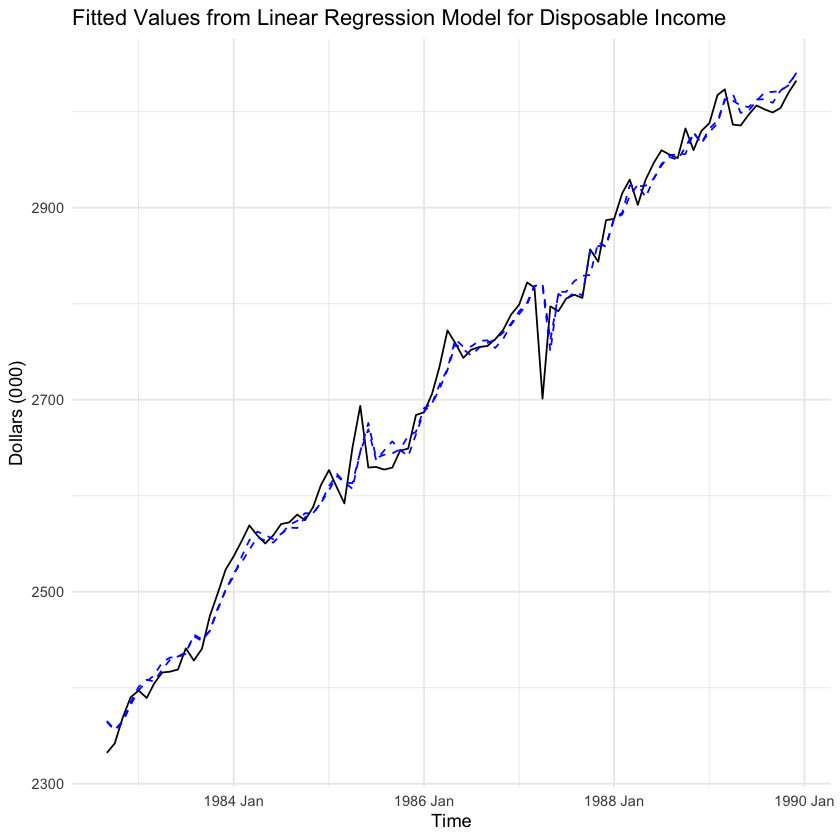

In [40]:
fitted_values <- fitted(consume_linear)

# Plot the original data and fitted values
autoplot(consume_train, Disposable_income) +
  autolayer(fitted_values, .fitted, color = "blue", linetype = "dashed") +
  labs(title = "Fitted Values from Linear Regression Model for Disposable Income",
       x = "Time", y = "Dollars (000)") +
  theme_minimal()

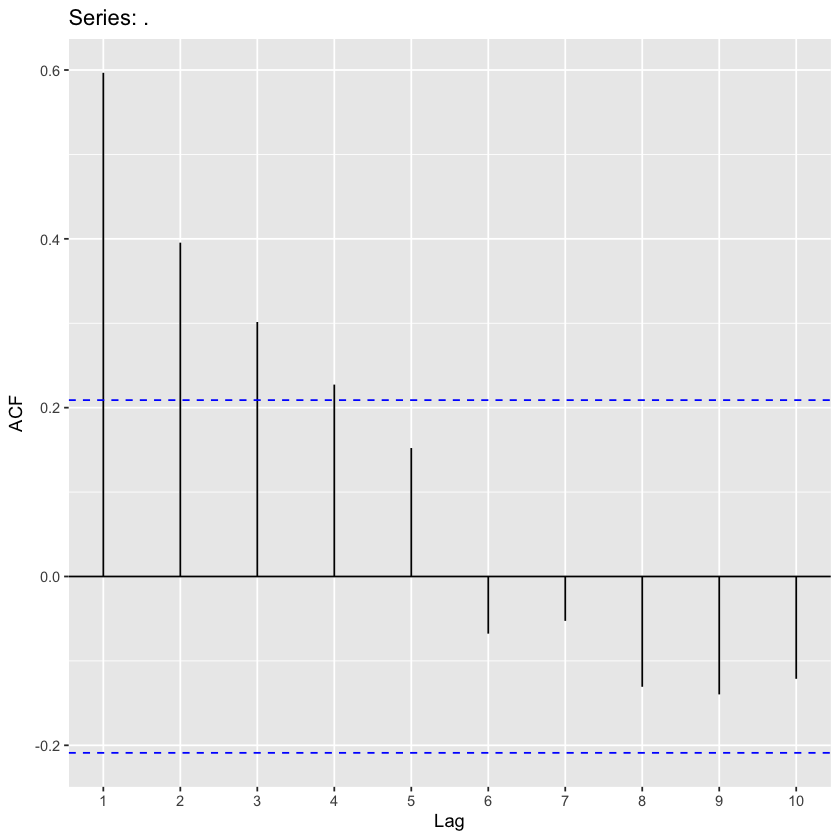

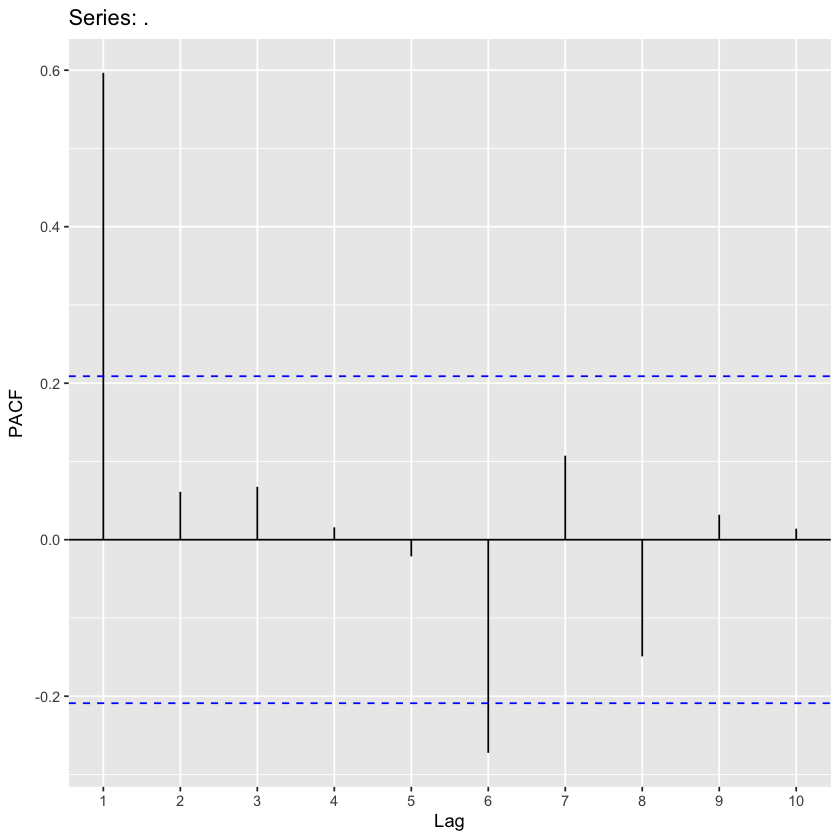

In [35]:
# plot the residuals
consume_linear %>% residuals() %>% ggAcf(lag.max = 10)
consume_linear %>% residuals() %>% ggPacf(lag.max = 10)

In [36]:
# fit the trend, with the corrections for AR,MA and diff if applicable
consume_linear <-consume_train %>% model(
    trend1 = ARIMA(Disposable_income~ trend() + pdq(6,0,0) + PDQ(0,0,0)+1), 
    trend2 = ARIMA(Disposable_income ~ trend() + PDQ(0,0,0) +1)) #the 1 is the intercept
consume_linear2<-as.data.frame(consume_linear)
t(consume_linear2)

trend1
trend2


In [37]:
glance(consume_linear) %>% arrange(AICc) %>% select(.model:BIC)

.model,sigma2,log_lik,AIC,AICc,BIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
trend2,503.8598,-397.3595,802.7190,803.201,812.6284
trend1,486.4234,-393.3921,804.7843,807.092,827.0803


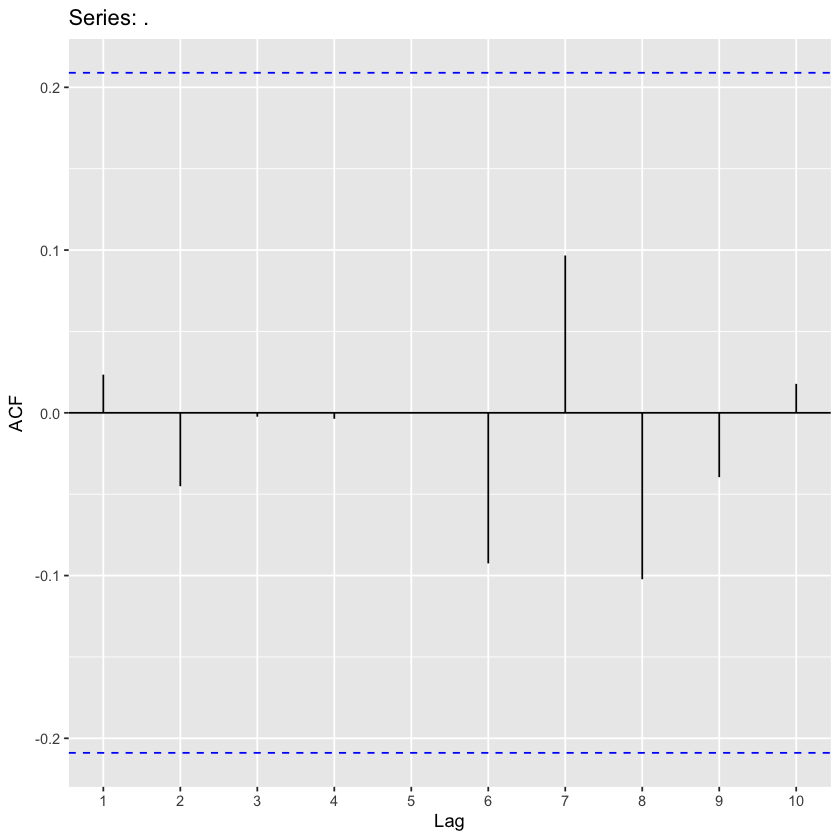

In [41]:
consume_linear %>% select(trend1) %>% residuals() %>% ggAcf(lag.max = 10)

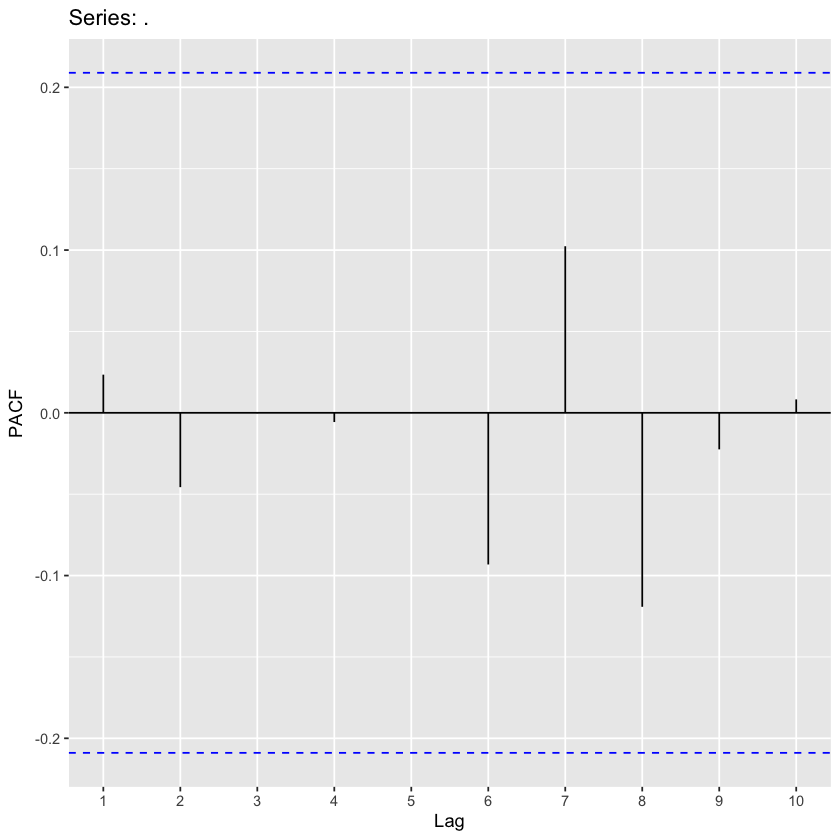

In [42]:
consume_linear %>% select(trend1) %>% residuals() %>% ggPacf(lag.max = 10)

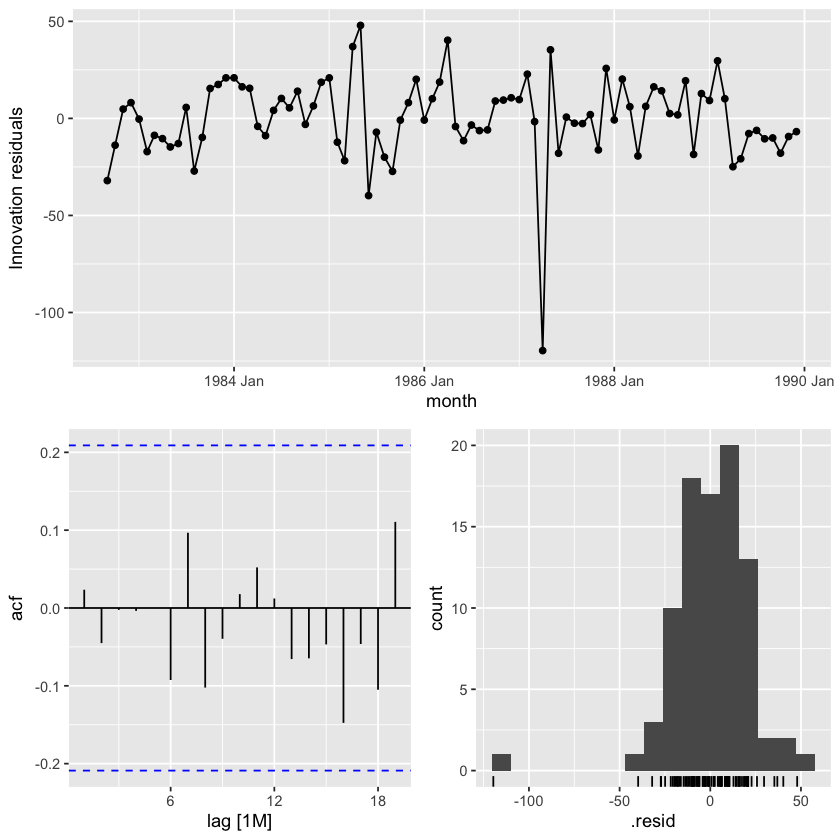

In [43]:
consume_linear %>% select(trend1) %>% gg_tsresiduals()

In [44]:
augment(consume_linear) %>% filter(.model=='trend1') %>% features(.innov,ljung_box, lag=10, dof = 6)

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
trend1,3.203875,0.5243052


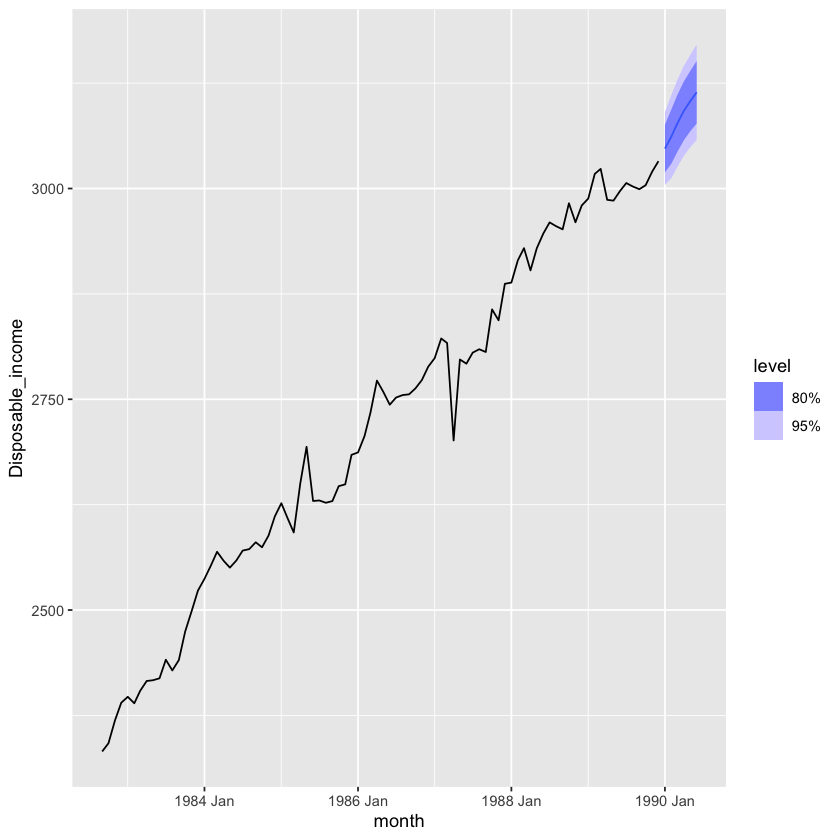

In [45]:
pred_lm <- consume_linear %>% select(trend1) %>%
  fabletools::forecast(h=6)

consume_linear %>% select(trend1) %>% fabletools::forecast(h=6) %>% autoplot(consume_train)

In [46]:
error_lm <- consume$Disposable_income[89:94] - pred_lm$.mean
MAPE_lm <-mean(abs(error_lm/consume$Disposable_income[89:94]))
MAE_lm <- mean(abs(error_lm))


pred_rw <- tibble(
  month = yearmonth(seq.Date(from = as.Date("1990-01-01"),
                                 to = as.Date("1990-06-01"),
                                 by = "month")),
  value = pred_ar6$.mean  
)

pred_lm2 <- tibble(
  month = yearmonth(seq.Date(from = as.Date("1990-01-01"),
                                 to = as.Date("1990-06-01"),
                                 by = "month")),
  value = pred_lm$.mean  
)

test_data <- tibble(
  month = yearmonth(seq.Date(from = as.Date("1990-01-01"),
                                 to = as.Date("1990-06-01"),
                                 by = "month")),
  value = consume.ts$Disposable_income[89:94]  
)

combined_data <- bind_rows(
  test_data %>% mutate(Line = "Actual"),
  pred_rw %>% mutate(Line = "Random Walk"),
  pred_lm2 %>% mutate(Line = "Linear Model")
)

# Plot the data with a legend
ggplot(combined_data, aes(x = month, y = value, color = Line)) +
  geom_line(linetype = "solid") +
  labs(title = "Predicted versus Actual values",
       x = "Date", y = "Disposable Income (000)",
       color = "Legend") +
  theme_minimal()

ERROR: Error: object 'pred_ar6' not found


#### ARIMAX with the Raleigh Dataset

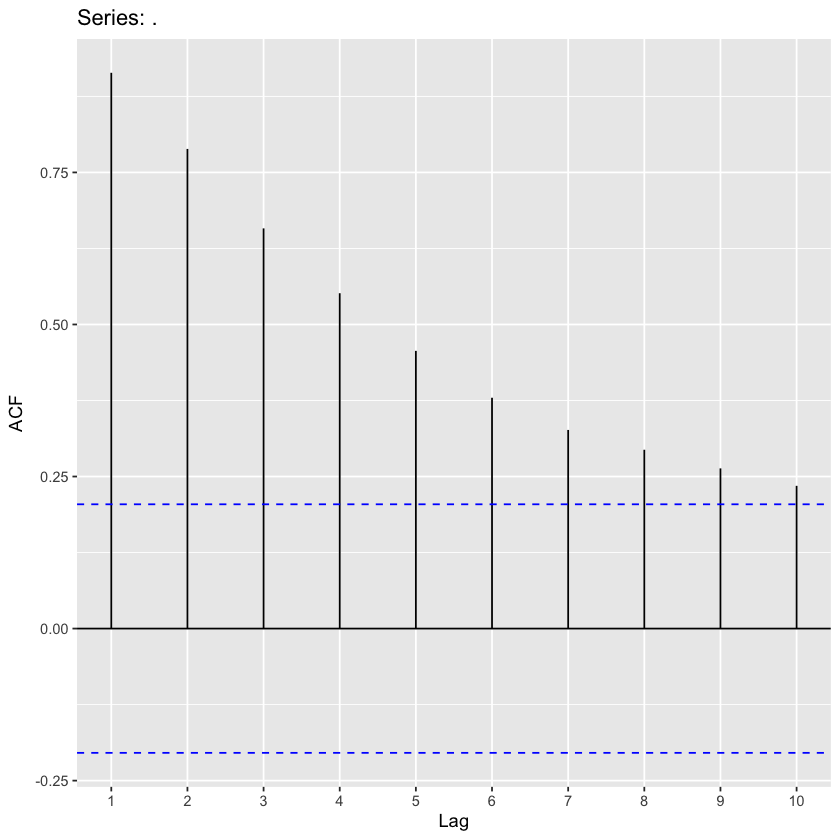

In [47]:
Raleigh_linear <-Raleigh_train %>%
  model(trend1 = ARIMA(price_index~ trend() + pdq(0,0,0) + PDQ(0,0,0)+1)
    )
Raleigh_linear %>% residuals() %>% ggAcf(lag.max = 10)

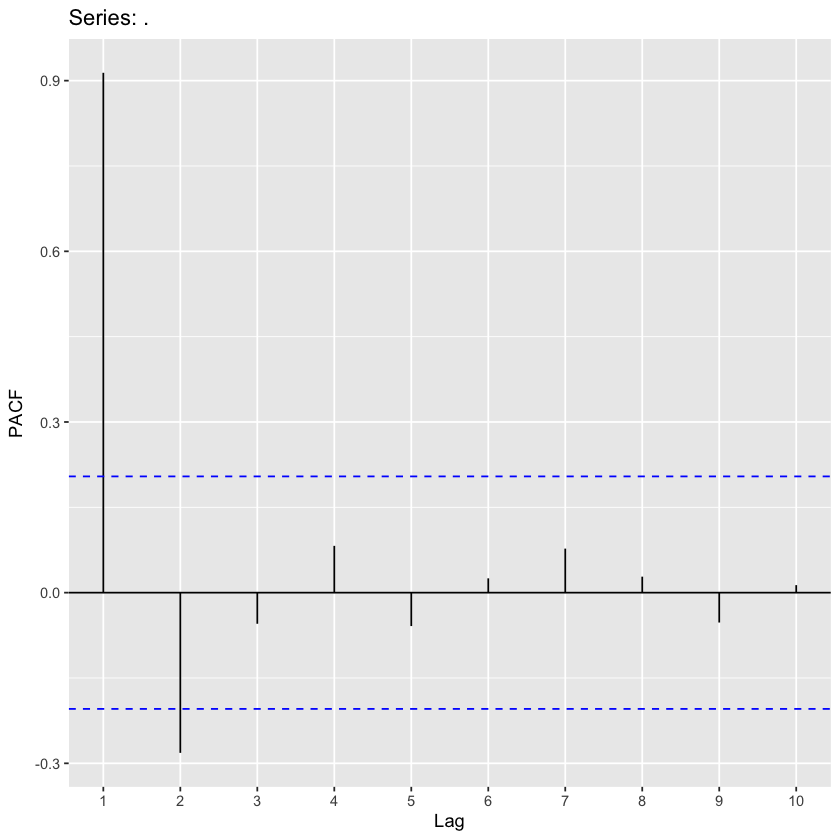

In [48]:
Raleigh_linear %>% residuals() %>% ggPacf(lag.max = 10)

In [49]:
Raleigh_linear <-Raleigh_train %>%
  model(trend1 = ARIMA(price_index~ trend() + pdq(2,0,0) + PDQ(0,0,0)+1),
        trend2 = ARIMA(price_index ~ trend() + PDQ(0,0,0) + 1),
        trend3 = ARIMA(price_index ~ trend() + PDQ(0,0,0) + 1,stepwise = FALSE)
    )
Raleigh_linear2<-as.data.frame(Raleigh_linear)
t(Raleigh_linear2)

trend1
trend2
trend3


In [50]:
glance(Raleigh_linear) %>% arrange(AICc) %>% select(.model:BIC)

.model,sigma2,log_lik,AIC,AICc,BIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
trend3,7.445263,-224.2592,464.5184,466.2533,484.6927
trend2,8.534616,-229.9226,473.8452,475.1785,491.4977
trend1,10.462400,-239.2474,488.4948,489.1924,501.1037


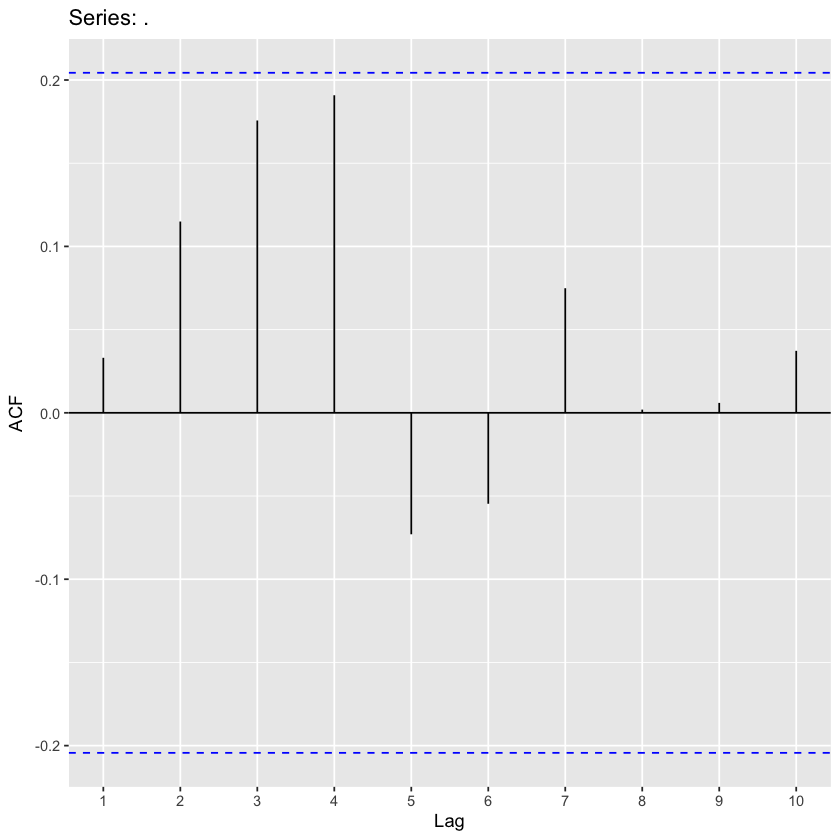

In [51]:
Raleigh_linear %>% select(trend2) %>% residuals() %>% ggAcf(lag.max = 10)

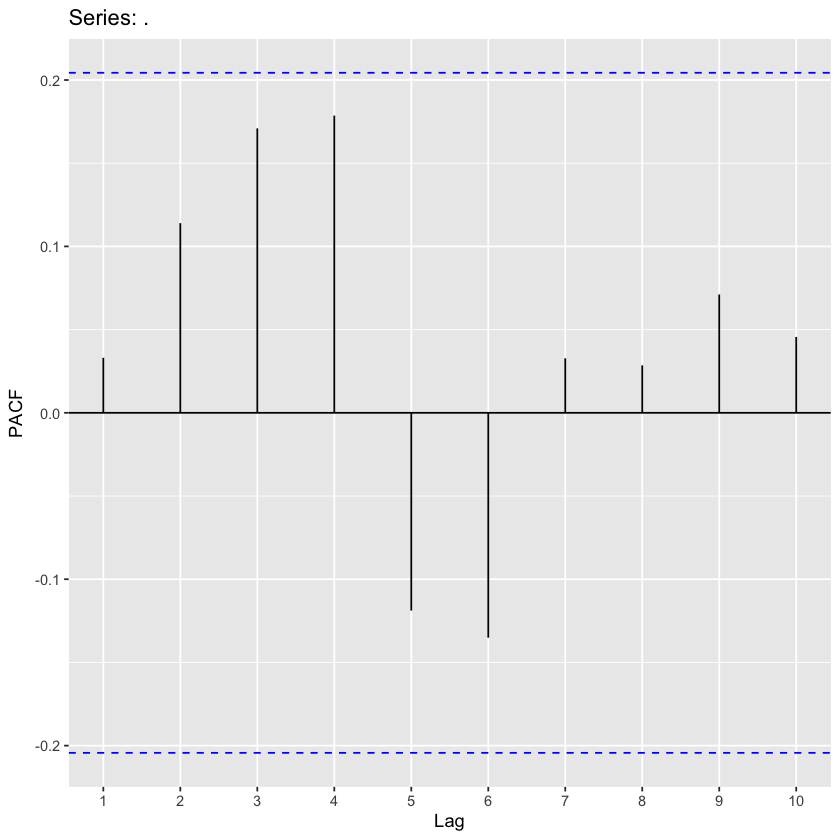

In [52]:
Raleigh_linear %>% select(trend2) %>%residuals() %>% ggPacf(lag.max = 10)

In [53]:
augment(Raleigh_linear) %>% filter(.model=='trend2') %>% features(.innov,ljung_box, lag=10, dof = 4)

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
trend2,9.502158,0.1472439


In [54]:
pred_lm <- Raleigh_linear %>% select(trend2) %>%
  fabletools::forecast(h=5)

error_lm <- Raleigh.ts$price_index[93:97] - pred_lm$.mean
MAPE_lm <-mean(abs(error_lm/Raleigh.ts$price_index[93:97]))
MAE_lm <- mean(abs(error_lm))


pred_rw <- tibble(
  quarter = yearquarter(seq.Date(from = as.Date("2023-01-01"),
                                 to = as.Date("2024-01-01"),
                                 by = "quarter")),
  value = pred_arima123$.mean  
)

pred_lm2 <- tibble(
  quarter = yearquarter(seq.Date(from = as.Date("2023-01-01"),
                                 to = as.Date("2024-01-01"),
                                 by = "quarter")),
  value = pred_lm$.mean  
)

test_data <- tibble(
  quarter = yearquarter(seq.Date(from = as.Date("2023-01-01"),
                                 to = as.Date("2024-01-01"),
                                 by = "quarter")),
  value = Raleigh.ts$price_index[93:97]  
)

combined_data <- bind_rows(
  test_data %>% mutate(Line = "Actual"),
  pred_rw %>% mutate(Line = "Random Walk"),
  pred_lm2 %>% mutate(Line = "Linear Model")
)

# Plot the data with a legend
ggplot(combined_data, aes(x = quarter, y = value, color = Line)) +
  geom_line(linetype = "solid") +
  labs(title = "Predicted versus Actual values",
       x = "Date", y = "Raleigh Price Index",
       color = "Legend") +
  theme_minimal()

ERROR: Error: object 'pred_arima123' not found


### BSTS (Bayesian Time Series)
- with airline data set

In [57]:
install.packages("bsts")

also installing the dependencies 'BoomSpikeSlab', 'Boom'





The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpkfFM1G/downloaded_packages


In [8]:
library(bsts)
library(tidyverse)


Loading required package: BoomSpikeSlab

Loading required package: Boom


Attaching package: 'Boom'


The following object is masked from 'package:stats':

    rWishart



Attaching package: 'BoomSpikeSlab'


The following object is masked from 'package:stats':

    knots


Loading required package: zoo


Attaching package: 'zoo'


The following object is masked from 'package:imputeTS':

    na.locf


The following object is masked from 'package:tsibble':

    index


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Loading required package: xts


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#        

In [62]:
airline <- read.csv("https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/airline.csv")
air.bsts=airline$LogPsngr

In [63]:
model_components=list()

=-=-=-=-= Iteration 0 Fri Sep 13 10:58:33 2024 =-=-=-=-=
=-=-=-=-= Iteration 200 Fri Sep 13 10:58:33 2024 =-=-=-=-=
=-=-=-=-= Iteration 400 Fri Sep 13 10:58:33 2024 =-=-=-=-=
=-=-=-=-= Iteration 600 Fri Sep 13 10:58:33 2024 =-=-=-=-=
=-=-=-=-= Iteration 800 Fri Sep 13 10:58:33 2024 =-=-=-=-=
=-=-=-=-= Iteration 1000 Fri Sep 13 10:58:34 2024 =-=-=-=-=
=-=-=-=-= Iteration 1200 Fri Sep 13 10:58:34 2024 =-=-=-=-=
=-=-=-=-= Iteration 1400 Fri Sep 13 10:58:34 2024 =-=-=-=-=
=-=-=-=-= Iteration 1600 Fri Sep 13 10:58:34 2024 =-=-=-=-=
=-=-=-=-= Iteration 1800 Fri Sep 13 10:58:34 2024 =-=-=-=-=


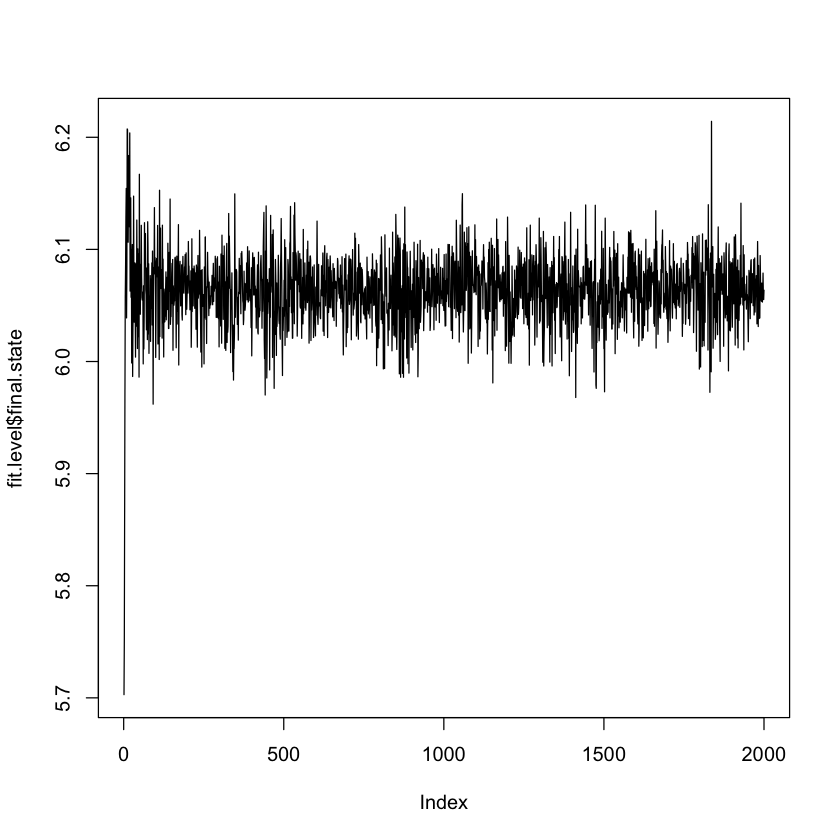

In [64]:
model_components <- AddLocalLevel(model_components, y = air.bsts)
fit.level=bsts(air.bsts, model_components, niter = 2000)
plot(fit.level$final.state,type='l')

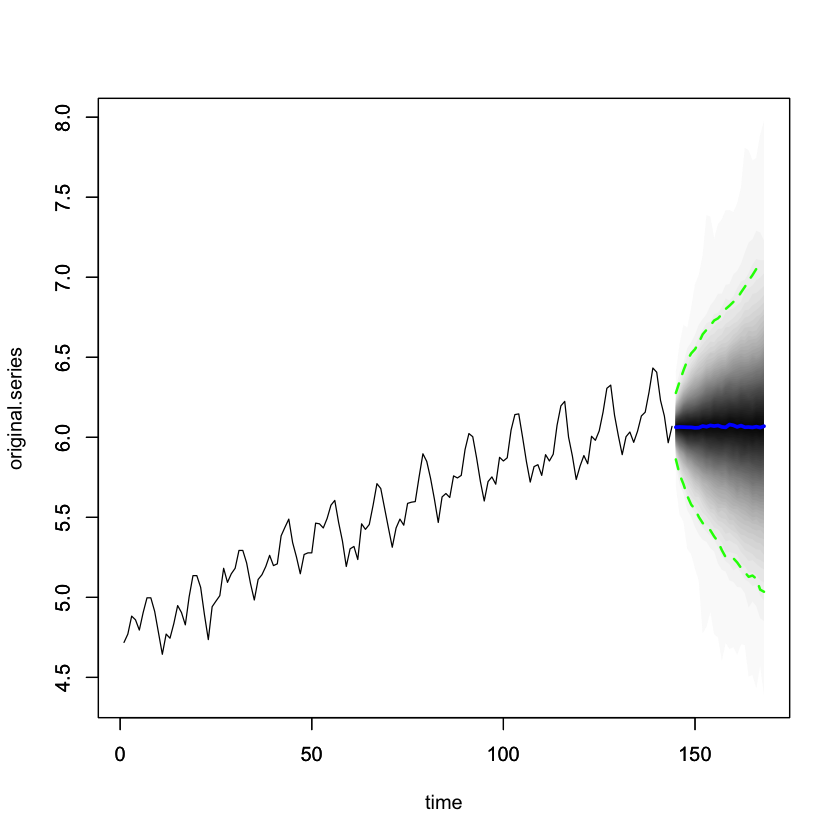

In [65]:
# forecast out 24 observations
pred.level<-predict(fit.level,burn = 200,horizon = 24)
plot(pred.level)

#### BSTS with trend

=-=-=-=-= Iteration 0 Fri Sep 13 11:13:36 2024 =-=-=-=-=
=-=-=-=-= Iteration 200 Fri Sep 13 11:13:36 2024 =-=-=-=-=
=-=-=-=-= Iteration 400 Fri Sep 13 11:13:36 2024 =-=-=-=-=
=-=-=-=-= Iteration 600 Fri Sep 13 11:13:36 2024 =-=-=-=-=
=-=-=-=-= Iteration 800 Fri Sep 13 11:13:36 2024 =-=-=-=-=
=-=-=-=-= Iteration 1000 Fri Sep 13 11:13:36 2024 =-=-=-=-=
=-=-=-=-= Iteration 1200 Fri Sep 13 11:13:36 2024 =-=-=-=-=
=-=-=-=-= Iteration 1400 Fri Sep 13 11:13:36 2024 =-=-=-=-=
=-=-=-=-= Iteration 1600 Fri Sep 13 11:13:37 2024 =-=-=-=-=
=-=-=-=-= Iteration 1800 Fri Sep 13 11:13:37 2024 =-=-=-=-=


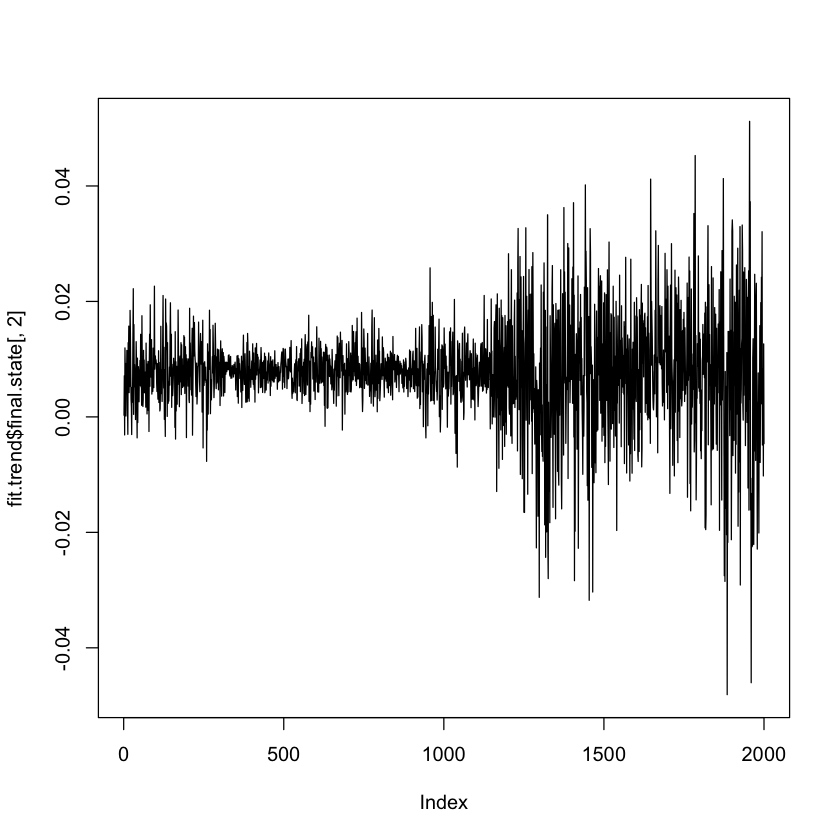

In [66]:
model_components=list()
model_components=AddLocalLinearTrend(model_components, 
y = air.bsts)
fit.trend=bsts(air.bsts, model_components, niter = 2000)
plot(fit.trend$final.state[,2],type='l')


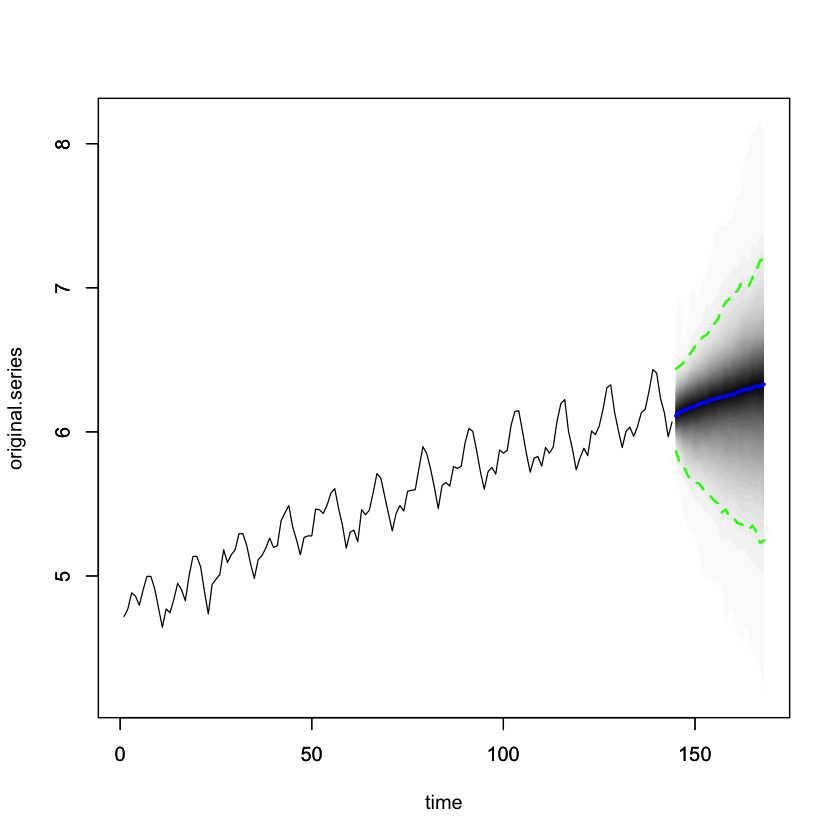

In [68]:
# get the predictions
pred.trend<-predict(fit.trend,burn = 500,horizon = 24)
plot(pred.trend)


In [69]:
 pred.trend$median


[1] 6.111013 6.137097 6.146251 6.158626 6.170575 6.176480 6.189965 6.201970
 [9] 6.203836 6.224756 6.226529 6.235981 6.241345 6.249650 6.255777 6.258248
[17] 6.274278 6.283827 6.295404 6.295700 6.307679 6.317663 6.315142 6.329722

#### Seasonality with Dummy Vars

=-=-=-=-= Iteration 0 Fri Sep 13 11:28:46 2024 =-=-=-=-=
=-=-=-=-= Iteration 200 Fri Sep 13 11:28:47 2024 =-=-=-=-=
=-=-=-=-= Iteration 400 Fri Sep 13 11:28:47 2024 =-=-=-=-=
=-=-=-=-= Iteration 600 Fri Sep 13 11:28:47 2024 =-=-=-=-=
=-=-=-=-= Iteration 800 Fri Sep 13 11:28:47 2024 =-=-=-=-=
=-=-=-=-= Iteration 1000 Fri Sep 13 11:28:47 2024 =-=-=-=-=
=-=-=-=-= Iteration 1200 Fri Sep 13 11:28:47 2024 =-=-=-=-=
=-=-=-=-= Iteration 1400 Fri Sep 13 11:28:48 2024 =-=-=-=-=
=-=-=-=-= Iteration 1600 Fri Sep 13 11:28:48 2024 =-=-=-=-=
=-=-=-=-= Iteration 1800 Fri Sep 13 11:28:48 2024 =-=-=-=-=


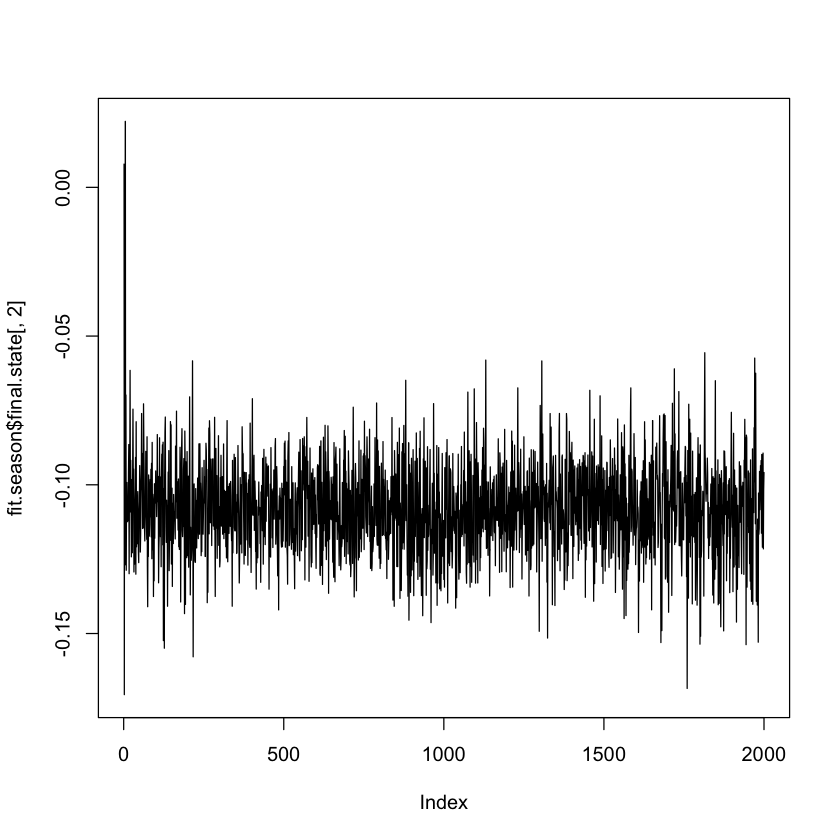

In [70]:
model_components=list()
model_components = AddLocalLevel(model_components, 
y = air.bsts)
model_components=AddSeasonal(model_components, y 
= air.bsts, nseasons = 12)
fit.season=bsts(air.bsts, model_components, niter = 2000)
plot(fit.season$final.state[,2],type='l')


### Predict with Dummies

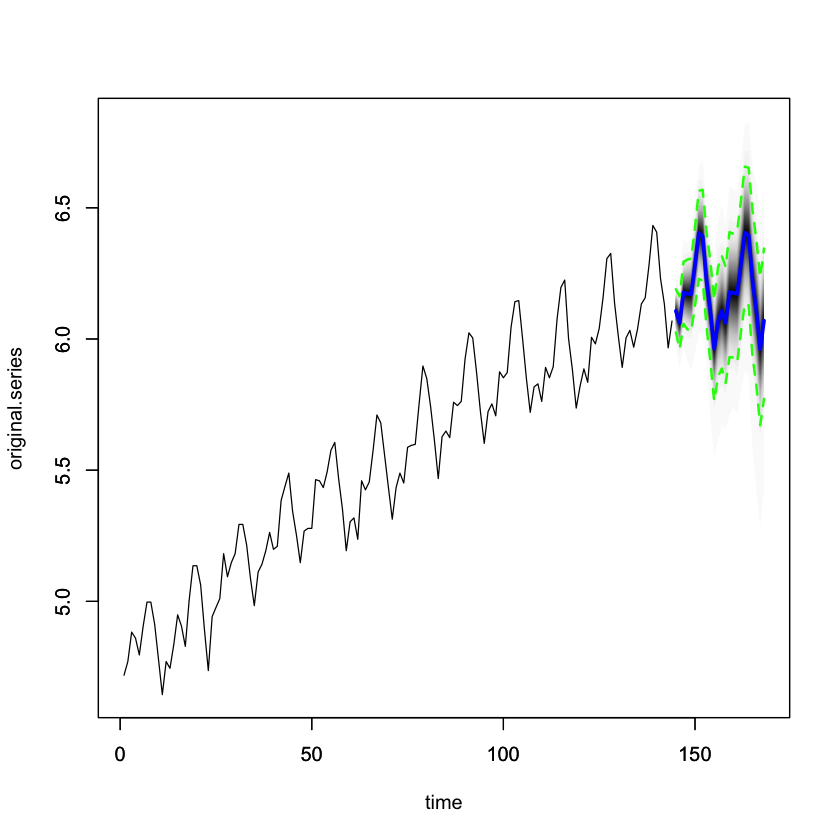

In [71]:
pred.season<-predict(fit.season,burn = 500,horizon = 24)
plot(pred.season)

### Trigonometric
- sines must equal cosines

=-=-=-=-= Iteration 0 Fri Sep 13 11:30:52 2024 =-=-=-=-=
=-=-=-=-= Iteration 200 Fri Sep 13 11:30:53 2024 =-=-=-=-=
=-=-=-=-= Iteration 400 Fri Sep 13 11:30:53 2024 =-=-=-=-=
=-=-=-=-= Iteration 600 Fri Sep 13 11:30:54 2024 =-=-=-=-=
=-=-=-=-= Iteration 800 Fri Sep 13 11:30:54 2024 =-=-=-=-=
=-=-=-=-= Iteration 1000 Fri Sep 13 11:30:55 2024 =-=-=-=-=
=-=-=-=-= Iteration 1200 Fri Sep 13 11:30:55 2024 =-=-=-=-=
=-=-=-=-= Iteration 1400 Fri Sep 13 11:30:56 2024 =-=-=-=-=
=-=-=-=-= Iteration 1600 Fri Sep 13 11:30:56 2024 =-=-=-=-=
=-=-=-=-= Iteration 1800 Fri Sep 13 11:30:57 2024 =-=-=-=-=


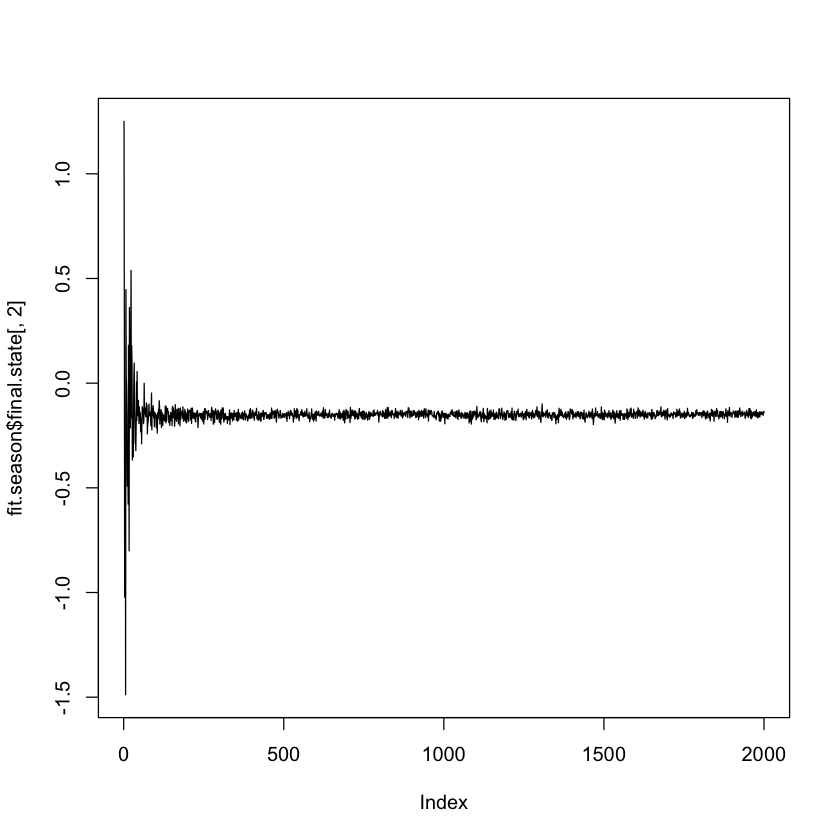

In [72]:
model_components=list()
model_components = AddLocalLevel(model_components, 
y = air.bsts)
model_components=AddTrig(model_components, y = 
air.bsts, 
period = 12,frequencies = 1:3)
fit.season=bsts(air.bsts, model_components, niter = 2000)
plot(fit.season$final.state[,2],type='l')

#### Pred with Trigonometric

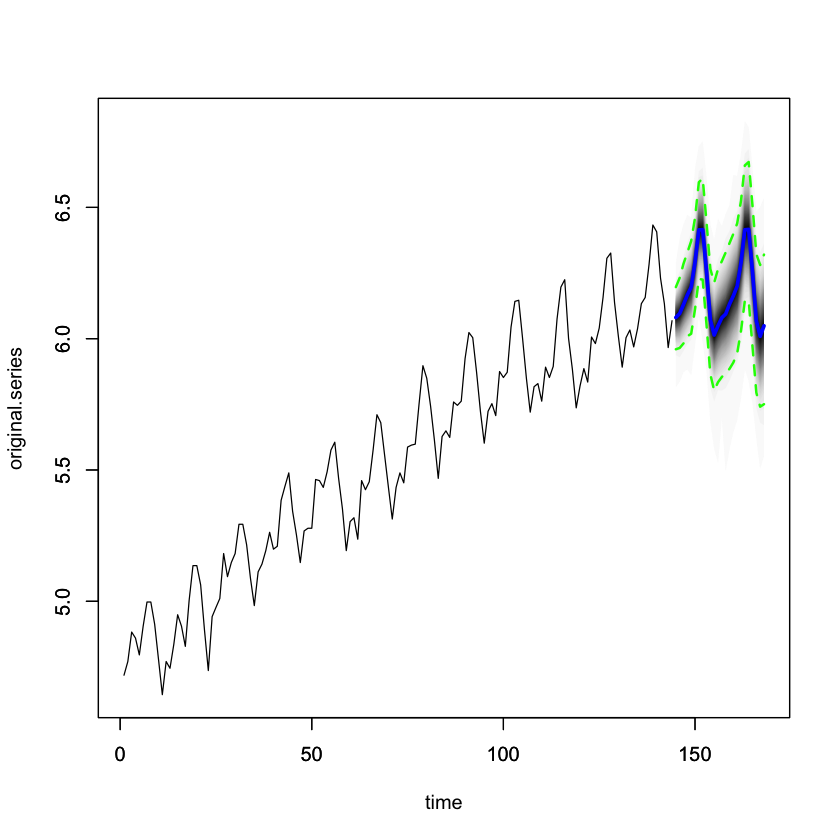

In [73]:
pred.season<-predict(fit.season,burn = 500,horizon = 24)
plot(pred.season)

#### Change Point Analysis
- shift in the mean
- shift in variance
- shift in both

In [9]:
library(changepoint)
netherlands = read.csv("")


ERROR: Error in library(changepoint): there is no package called 'changepoint'


In [ ]:
cp.n <- cpt.mean(netherlands$Percentage.Unemployed, method = “PELT", 
Q = 10)
plot(cp.n)
summary(cp.n)

## Time Series 2

In [10]:
library(tidyverse)
library(dplyr)
library(tsibble)
library(fpp3)
library(forecast)

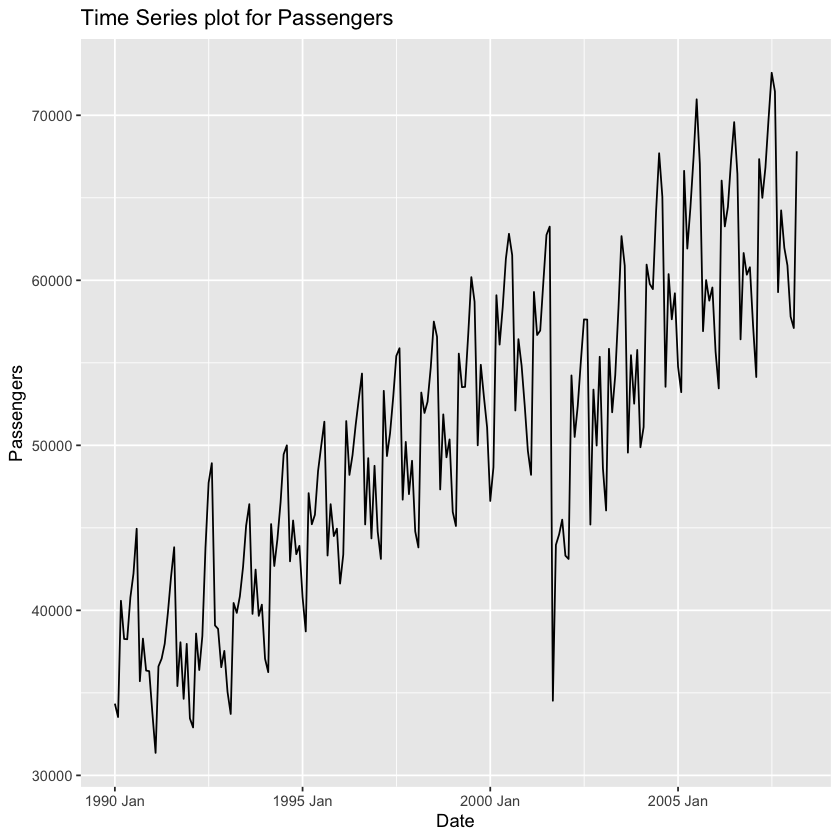

In [12]:
file.dir = "https://raw.githubusercontent.com/sjsimmo2/TimeSeries/master/" 
input.file1 = "usairlines.csv"
USAirlines = read.csv(paste(file.dir, input.file1,sep = ""))
USAirlines <- USAirlines %>% 
 mutate(date = yearmonth(lubridate::make_date(Year, Month)))
USAirlines_ts <- as_tsibble(USAirlines, index = date) 
autoplot(USAirlines_ts, Passengers) + 
 labs(title = "Time Series plot for Passengers", x = "Date", y = "Passengers")

#### Train Validate split...then Decompose

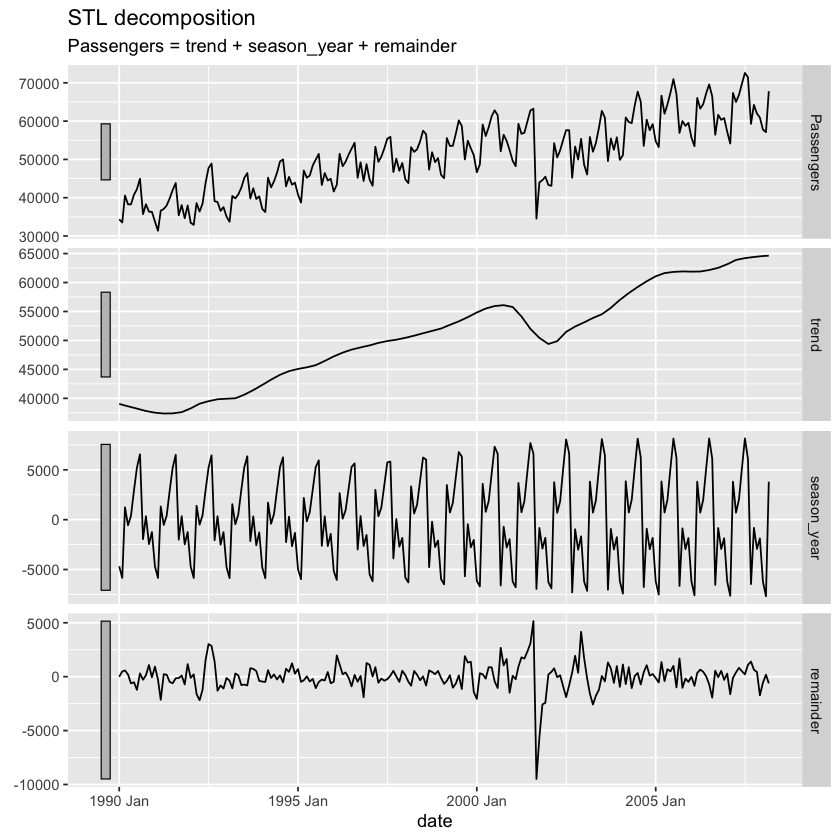

In [13]:
# seasoon is specified as month in this case
train <- USAirlines_ts %>%
 select(Passengers, date, Month) %>%
 filter_index(~ "2007-03") 
test <- USAirlines_ts %>%
 select(Passengers, date, Month) %>%
 filter_index("2007-04" ~ .) 
dcmp <- USAirlines_ts %>%
 model(stl = STL(Passengers)) 
components(dcmp) %>% autoplot()

### 2. Always try an ESM decomp first...this will be your baseline to beat with an ARIMA or more complex model

In [14]:
model_HW <- train %>%
 model(
 ETS(Passengers ~ error("M") + trend("A") + season("M"))
 )
model_HW_for <- model_HW %>%
 fabletools::forecast(h = 12)
fabletools::accuracy(model_HW_for, test)


.model,.type,ME,RMSE,MAE,MPE,MAPE,MASE,RMSSE,ACF1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"ETS(Passengers ~ error(""M"") + trend(""A"") + season(""M""))",Test,580.6336,1209.304,1100.018,0.8973004,1.712714,NaN,NaN,0.1558307


### 3. How to remove Seasonality (stochastic or determinisitic)?
- test for strength of seasonality (0.64 is key)
- use nsdiffs

In [15]:
train %>%
 features(Passengers, unitroot_nsdiffs)

nsdiffs
<int>
1


- result indicates we should take one seasonal difference (1 in the nsdiffs)
- double check it with regular differencing

### 4. Unit Root Testing

In [16]:
train %>%
 mutate(Pass_diff = difference(Passengers, lag = 12)) %>%
 features(Pass_diff, unitroot_ndiffs)

ndiffs
<int>
0


### 5. Deterministic Path
- dummy variables: each season receives its own dummy variable. E.G. day is season, 24 dummy variables (hours)

In [17]:
season_lin <- lm(Passengers ~ factor(Month), data = train)
summary(season_lin)


Call:
lm(formula = Passengers ~ factor(Month), data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-16257.2  -6848.9    484.4   6368.3  14699.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)      44299.6     1945.9  22.766  < 2e-16 ***
factor(Month)2    -971.9     2751.9  -0.353  0.72433    
factor(Month)3    8561.7     2751.9   3.111  0.00214 ** 
factor(Month)4    5276.9     2792.1   1.890  0.06025 .  
factor(Month)5    6413.7     2792.1   2.297  0.02267 *  
factor(Month)6    9306.5     2792.1   3.333  0.00103 ** 
factor(Month)7   11966.8     2792.1   4.286 2.86e-05 ***
factor(Month)8   11759.3     2792.1   4.212 3.87e-05 ***
factor(Month)9    1219.4     2792.1   0.437  0.66279    
factor(Month)10   5526.0     2792.1   1.979  0.04920 *  
factor(Month)11   3193.7     2792.1   1.144  0.25408    
factor(Month)12   4461.9     2792.1   1.598  0.11165    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual s

#### Seasonal dummy variables
- ADV: still have interpretability; straightforward to implement

In [18]:
model_SD_ARIMA <- train %>%
 model(ARIMA(Passengers ~ factor(Month) + PDQ(0,0,0)))
report(model_SD_ARIMA)


Series: Passengers 
Model: LM w/ ARIMA(1,1,1) errors 

Coefficients:
         ar1      ma1  factor(Month)2  factor(Month)3  factor(Month)4
      0.4290  -0.7970      -1092.9154       8320.1242       5723.4668
s.e.  0.1142   0.0773        473.9114        574.5485        625.8415
      factor(Month)5  factor(Month)6  factor(Month)7  factor(Month)8
           6721.1774       9485.2351      12021.9750      11693.0530
s.e.        648.7665        659.2791        662.5646        659.9506
      factor(Month)9  factor(Month)10  factor(Month)11  factor(Month)12
           1033.6595        5223.6760        2779.6623        3948.1224
s.e.        650.4285         629.7997         586.4674         485.1739
      intercept
       120.7069
s.e.    47.0971

sigma^2 estimated as 3751115:  log likelihood=-1844.41
AIC=3718.82   AICc=3721.34   BIC=3768.74


#### Fourier Transforms
- works in sin/cosin pairs
- can have up to 1/2 the season pairs: year/months will cap at 6, hours/day will cap at 12. 
- Max pairs is same effect as simply using seasonal dummies variables

In [19]:
model_F_ARIMA <- train %>%
  model(
  `K = 1` = ARIMA(Passengers ~ fourier(K=1) + PDQ(D = 0)),
  `K = 2` = ARIMA(Passengers ~ fourier(K=2) + PDQ(D = 0)),
  `K = 3` = ARIMA(Passengers ~ fourier(K=3) + PDQ(D = 0)),
  `K = 4` = ARIMA(Passengers ~ fourier(K=4) + PDQ(D = 0)),
  `K = 5` = ARIMA(Passengers ~ fourier(K=5) + PDQ(D = 0)),
  `K = 6` = ARIMA(Passengers ~ fourier(K=6) + PDQ(D = 0))
)

glance(model_F_ARIMA)


ERROR while rich displaying an object: Error in (function (..., row.names = NULL, check.rows = FALSE, check.names = TRUE, : arguments imply differing number of rows: 13, 24, 0, 1

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6

In [20]:
model_F_ARIMA <- train %>%
 model(ARIMA(Passengers ~ fourier(K = 6) + PDQ(0,0,0))
)
report(model_F_ARIMA)

Series: Passengers 
Model: LM w/ ARIMA(1,1,1) errors 

Coefficients:
         ar1      ma1  fourier(K = 6)C1_12  fourier(K = 6)S1_12
      0.4290  -0.7970           -4370.2035            1100.2519
s.e.  0.1142   0.0773             270.2329             270.4442
      fourier(K = 6)C2_12  fourier(K = 6)S2_12  fourier(K = 6)C3_12
                 610.7831            -430.1257           -2561.0814
s.e.             193.6263             194.1363             152.7946
      fourier(K = 6)S3_12  fourier(K = 6)C4_12  fourier(K = 6)S4_12
               -1291.4692             254.1196            -387.6305
s.e.             153.1538             130.6594             130.4205
      fourier(K = 6)C5_12  fourier(K = 6)S5_12  fourier(K = 6)C6_12  intercept
                 919.7895           -2141.1865            -341.9420   120.7034
s.e.             118.9847             119.5054              81.8771    47.1035

sigma^2 estimated as 3751119:  log likelihood=-1844.41
AIC=3718.82   AICc=3721.34   BIC=3768.

Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_point()`)."


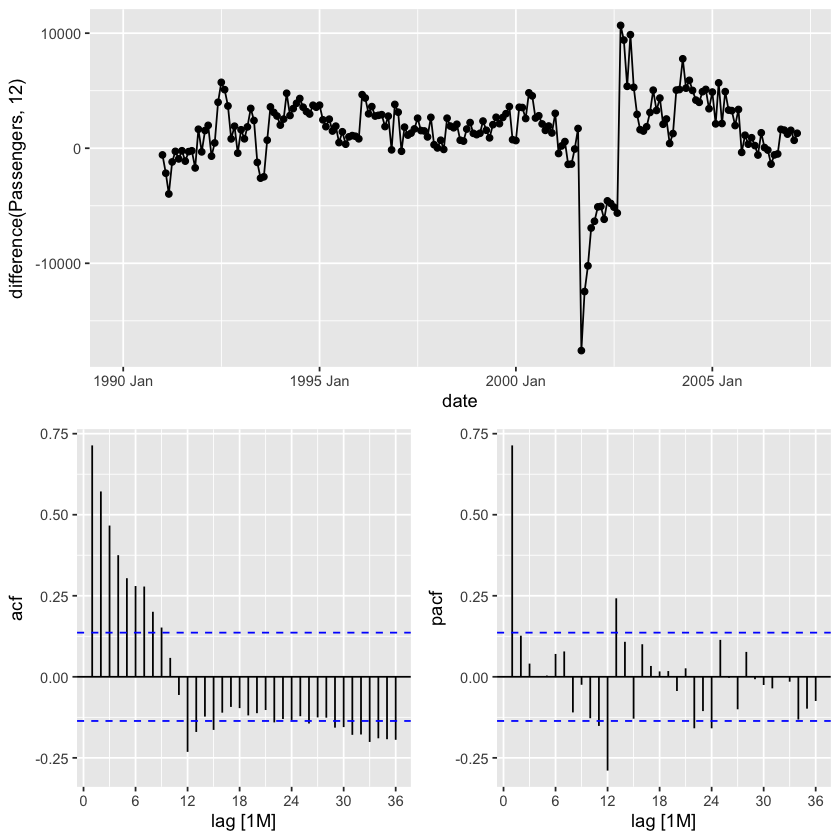

In [21]:
train %>% 
 gg_tsdisplay(difference(Passengers, 12), plot_type = 'partial', lag = 36)


#### Seasonal ARIMA

In [22]:
model_SARIMA <- train %>% 
 model(
 hand = ARIMA(Passengers ~ pdq(1,0,0) + PDQ(1,1,1)),
 auto = ARIMA(Passengers)
 )

#### By Hand

Series: Passengers 
Model: ARIMA(1,0,0)(1,1,1)[12] w/ drift 

Coefficients:
         ar1    sar1     sma1  constant
      0.7444  0.1721  -0.7755  319.7502
s.e.  0.0487  0.1040   0.0753   38.5404

sigma^2 estimated as 3745598:  log likelihood=-1754.8
AIC=3519.61   AICc=3519.93   BIC=3535.97


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
hand,37.38002,0.2748224


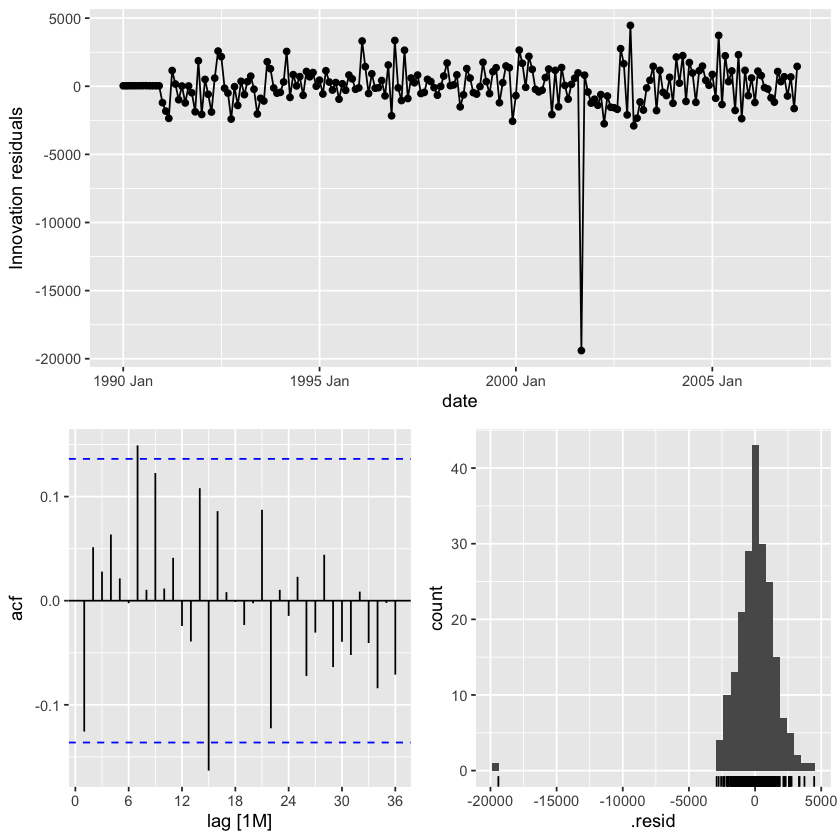

In [23]:
model_SARIMA %>%
 select(hand) %>%
 report
augment(model_SARIMA) %>%
 filter(.model == "hand") %>%
 features(.innov, ljung_box, lag = 36, 
 dof = 3)
model_SARIMA %>%
 select(hand) %>%
 gg_tsresiduals(lag = 36)

#### Auto

Series: Passengers 
Model: ARIMA(1,0,1)(0,1,1)[12] w/ drift 

Coefficients:
         ar1      ma1     sma1  constant
      0.8801  -0.2962  -0.6785  179.8722
s.e.  0.0454   0.0950   0.0600   34.0147

sigma^2 estimated as 3639496:  log likelihood=-1751.67
AIC=3513.34   AICc=3513.66   BIC=3529.7


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
auto,29.38502,0.6478039


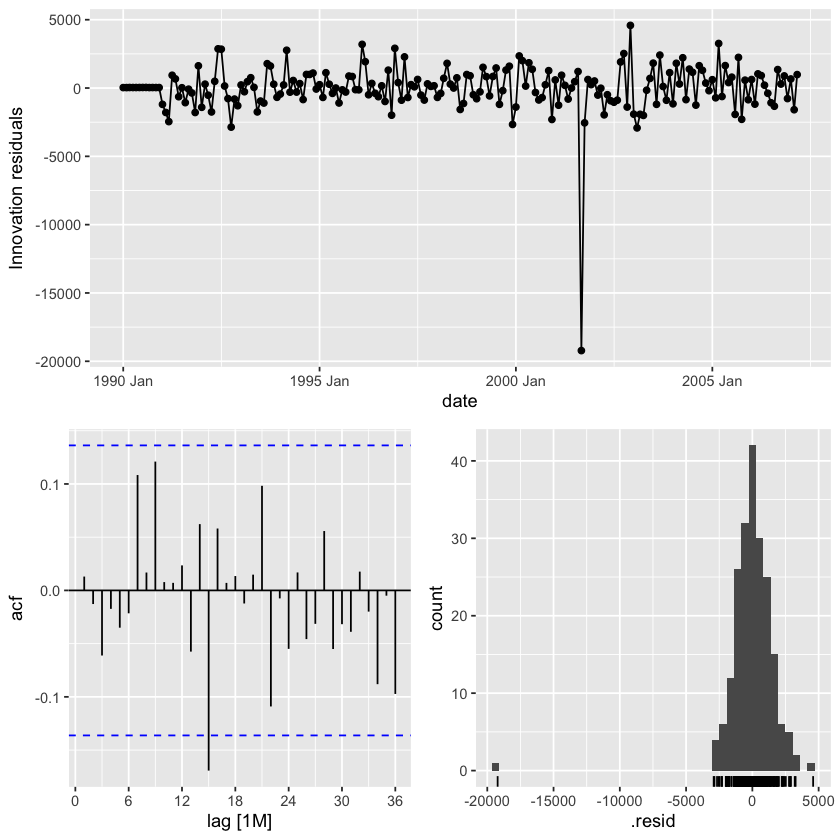

In [24]:
model_SARIMA %>%
 select(auto) %>%
 report
augment(model_SARIMA) %>%
 filter(.model == "auto") %>%
 features(.innov, ljung_box, lag = 36, 
 dof = 3)
model_SARIMA %>%
 select(auto) %>%
 gg_tsresiduals(lag = 36)


Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_point()`)."


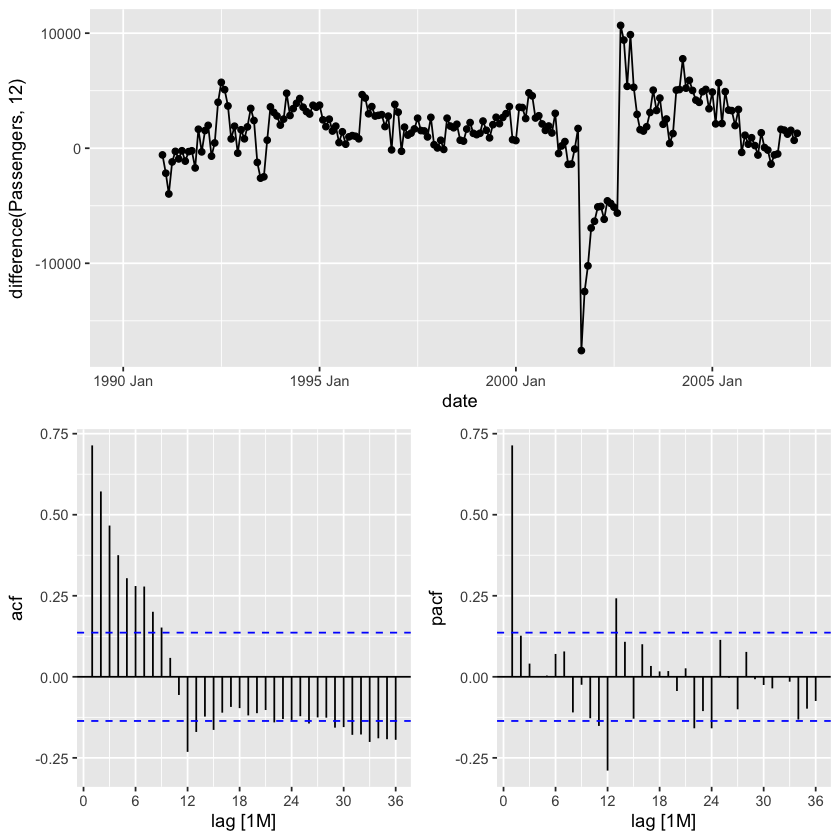

In [25]:
train %>% 
 gg_tsdisplay(difference(Passengers, 12), plot_type = 'partial', lag = 36)


In [26]:
#multiplicative model by default
model_SARIMA <- train %>% 
 model(
 hand = ARIMA(Passengers ~ pdq(1,0,0) 
 + PDQ(1,1,1)),
 auto = ARIMA(Passengers)
 )

In [27]:
model_SARIMA_for <- forecast(model_SARIMA, h = 12)
fabletools::accuracy(model_SARIMA_for, test)

.model,.type,ME,RMSE,MAE,MPE,MAPE,MASE,RMSSE,ACF1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
auto,Test,806.6733,1339.299,1229.219,1.204963,1.885418,NaN,NaN,0.4460242
hand,Test,752.2096,1280.096,1161.711,1.113698,1.777729,NaN,NaN,0.4935785


### Interventions: 
- point/pulse interventions

In [31]:
train$Sep11 <- rep(0, 207)
train$Sep11[141] <- 1

model_ARIMAX <- train %>%
  model(ARIMA(Passengers ~ Sep11))
report(model_ARIMAX)

Series: Passengers 
Model: LM w/ ARIMA(1,0,1)(0,1,1)[12] errors 

Coefficients:
         ar1      ma1     sma1       Sep11  intercept
      0.8764  -0.1635  -0.6653  -11531.148  1504.6921
s.e.  0.0425   0.0883   0.0579    1153.359   275.8039

sigma^2 estimated as 2443900:  log likelihood=-1712.24
AIC=3436.49   AICc=3436.94   BIC=3456.13


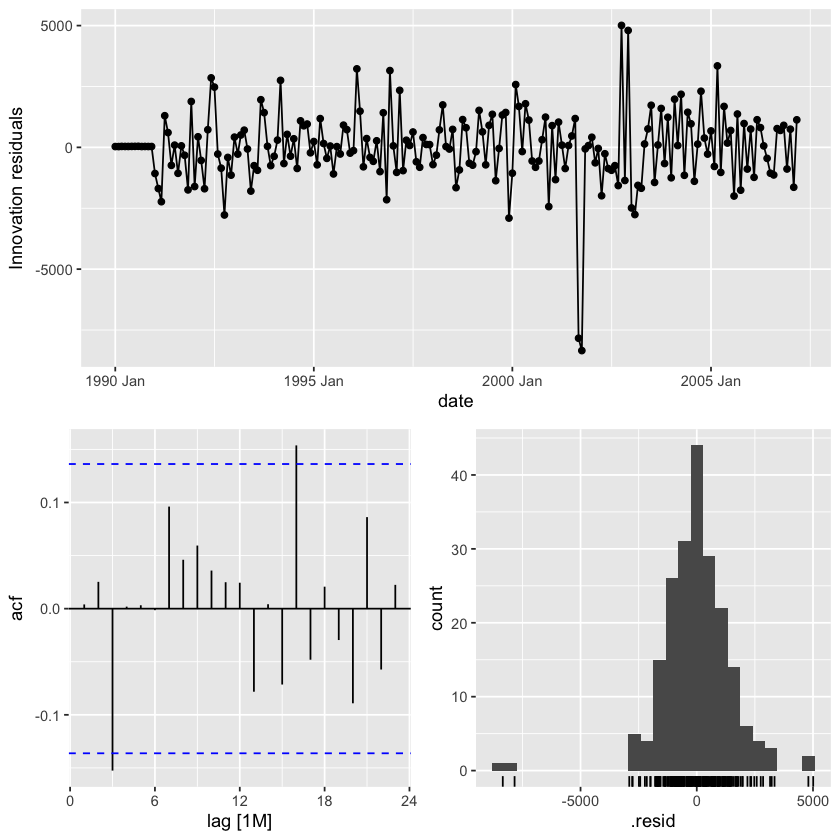

In [ ]:
model_ARIMAX %>%
  gg_tsresiduals()

##### Predictor Variables in Time Series Dynamic Regression

##### Adding lags to a predictor variable - 11 SEPT

In [34]:
model_ARIMAX <- train %>%
  model(
    hand = ARIMA(Passengers ~ 1 + Sep11 + lag(Sep11) + lag(Sep11, 2) + 
                lag(Sep11, 3) + lag(Sep11, 12) + pdq(1,0,0) + PDQ(1,1,1)),
    auto = ARIMA(Passengers ~ Sep11 + lag(Sep11) + lag(Sep11, 2) + 
                lag(Sep11, 3) + lag(Sep11, 12))
    )


Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 12 rows containing non-finite outside the scale range (`stat_bin()`)."


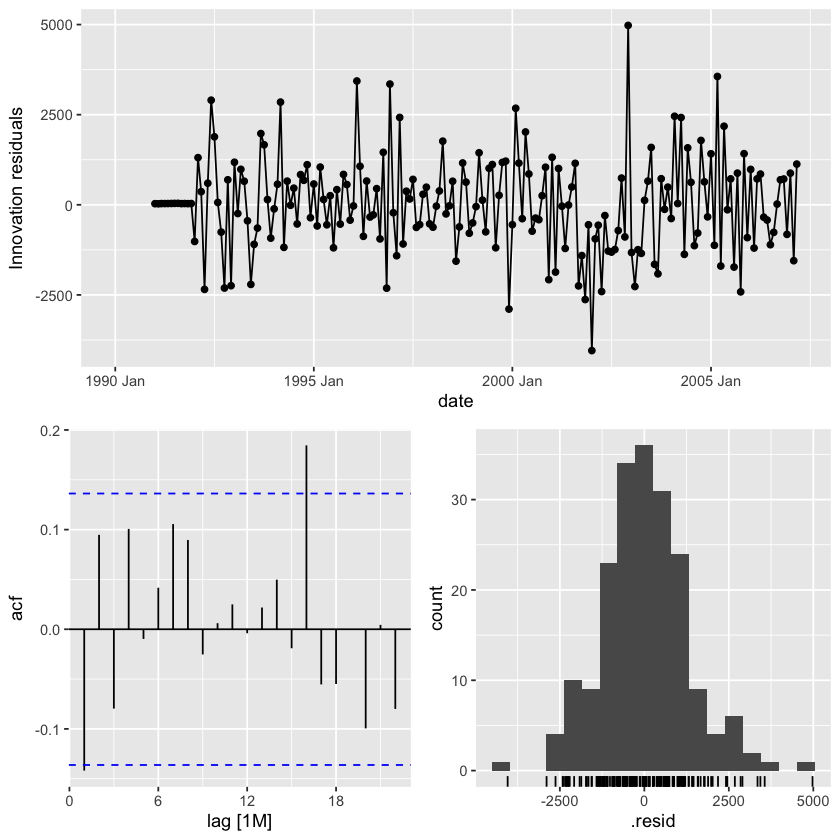

In [35]:
model_ARIMAX %>%
  select(hand) %>%
  gg_tsresiduals()

In [36]:
augment(model_ARIMAX) %>%
  filter(.model == "hand") %>%
  features(.innov, ljung_box, lag = 36, dof = 5)

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
hand,38.15582,0.1761146


##### Takeaways: 
1. the outlier around September 11 is significantly reduced
2. now there is white noise in the model

##### Forecasting with Additional Predictor Variables

Plot variable not specified, automatically selected `.vars = .fitted`
Warning message:
"Removed 24 rows containing missing values or values outside the scale range
(`geom_line()`)."


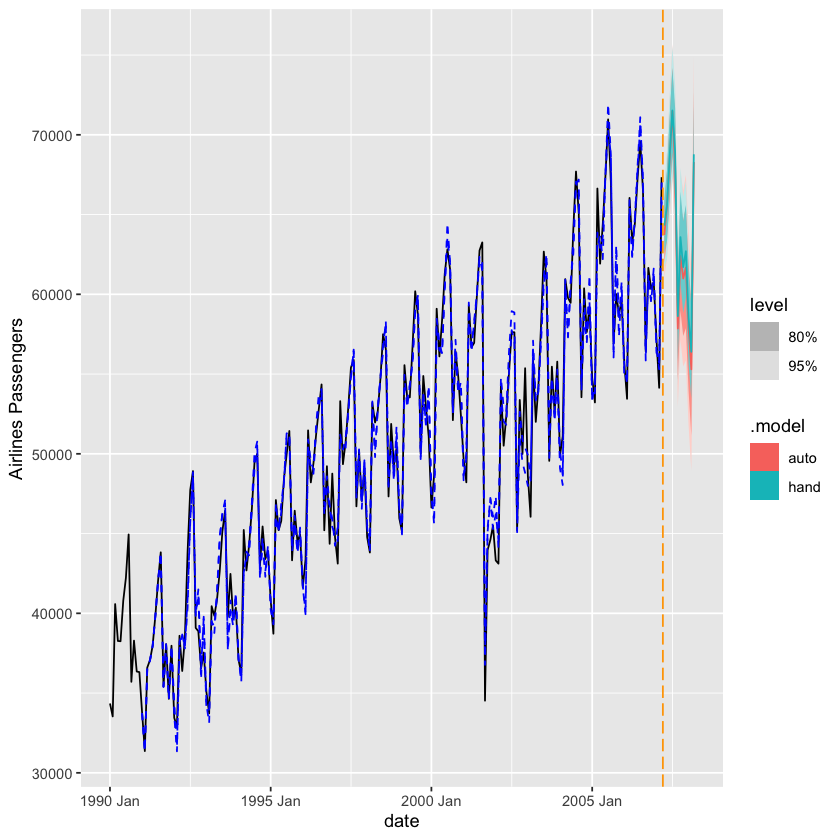

In [39]:
test$Sep11 <- rep(0, 12)

model_ARIMAX_for <- forecast(model_ARIMAX, test)

model_ARIMAX_for %>%
  autoplot(train) + 
  autolayer(fitted(model_ARIMAX), col = "blue", linetype = "dashed") + 
  ylab("Airlines Passengers") + 
  geom_vline(xintercept = as_date("2007-03-15"), color="orange", linetype="longdash")

In [40]:
fabletools::accuracy(model_ARIMAX_for, test)

.model,.type,ME,RMSE,MAE,MPE,MAPE,MASE,RMSSE,ACF1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
auto,Test,1089.838,1537.275,1314.635,1.6590928,2.016541,NaN,NaN,0.1055770
hand,Test,450.566,1184.732,1030.388,0.6369351,1.572819,NaN,NaN,0.3573128


#### FB Prophet

In [44]:
install.packages("fable")
install.packages("fable.prophet")


The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpviwXTL/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpviwXTL/downloaded_packages


Loading required package: Rcpp



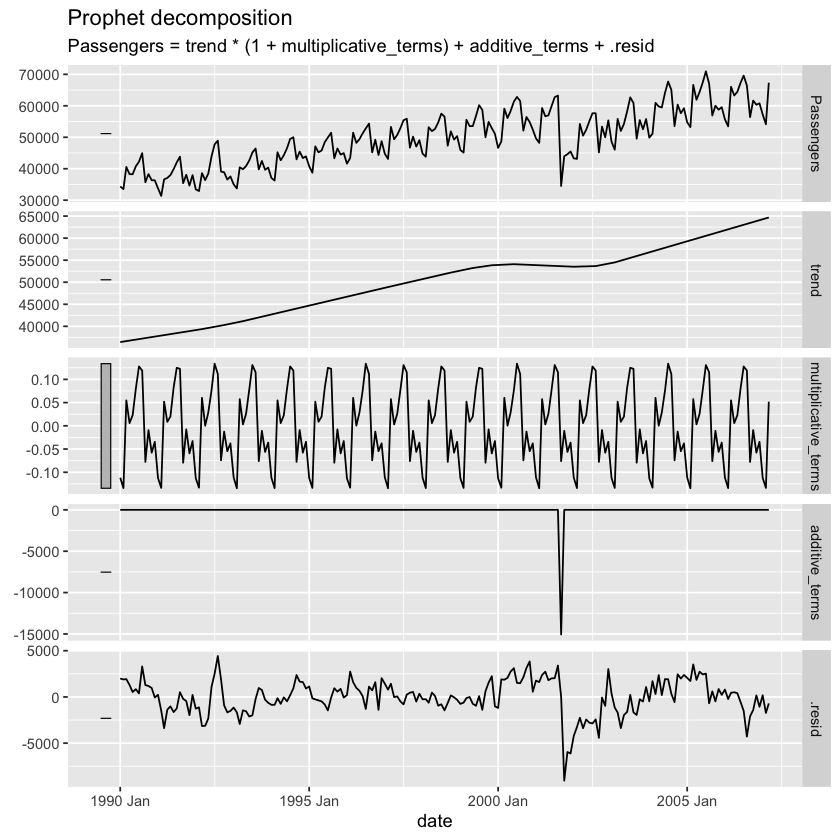

In [45]:
library(fable.prophet)
train$Sep11 <- rep(0, 207)
train$Sep11[141] <- 1
model_prophet <- train %>%
 model(prophet(Passengers ~ Sep11 +
 growth("linear") + 
 season(period = "year", order = 6, type = "multiplicative"))) 
model_prophet %>% 
 components() %>%
 autoplot()


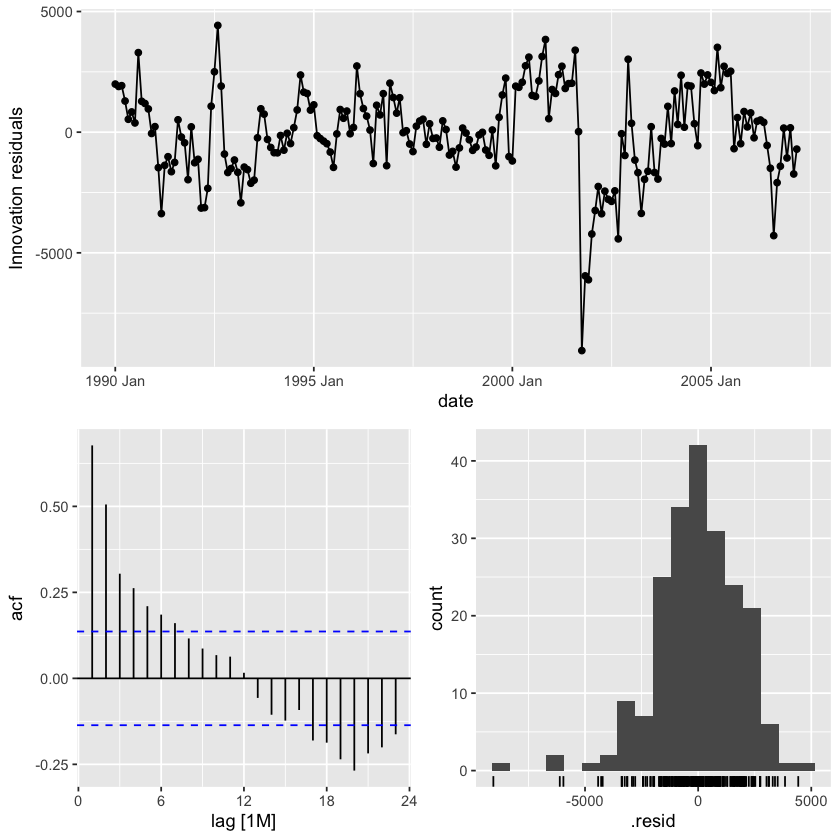

In [46]:
model_prophet %>%
  gg_tsresiduals()

In [47]:
augment(model_prophet) %>%
  features(.innov, ljung_box, lag = 36, dof = 5)

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
"prophet(Passengers ~ Sep11 + growth(""linear"") + season(period = ""year"", order = 6, type = ""multiplicative""))",416.634,0


Plot variable not specified, automatically selected `.vars = .fitted`


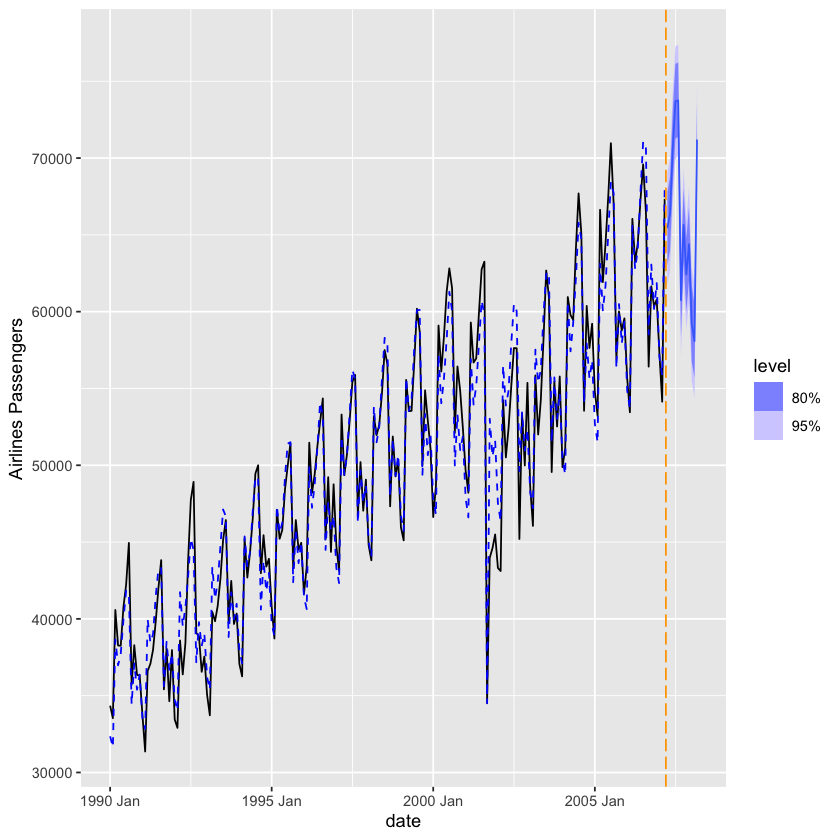

In [48]:
test$Sep11 <- rep(0, 12)

model_prophet_for <- forecast(model_prophet, test)

model_prophet_for %>%
  autoplot(train) + 
  autolayer(fitted(model_prophet), col = "blue", linetype = "dashed") + 
  ylab("Airlines Passengers") + 
  geom_vline(xintercept = as_date("2007-03-15"), color="orange", linetype="longdash")

#### Auto Regressive Neural Networks

In [49]:
train$Sep11 <- rep(0, 207)
train$Sep11[141] <- 1

set.seed(12345)
model_nnet <- train %>%
  mutate(diff_Pass = difference(Passengers, 12)) %>%
  model(
    hand = NNETAR(diff_Pass ~ Sep11 + AR(p = 1, P = 3)),
  
    auto = NNETAR(diff_Pass ~ Sep11)  
  )

model_nnet %>%
  select(auto) %>%
  report()

Series: diff_Pass 
Model: NNAR(15,1,8)[12] 

Average of 20 networks, each of which is
a 16-8-1 network with 145 weights
options were - linear output units 

sigma^2 estimated as 73589


Warning message:
"Removed 48 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 48 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 48 rows containing non-finite outside the scale range (`stat_bin()`)."


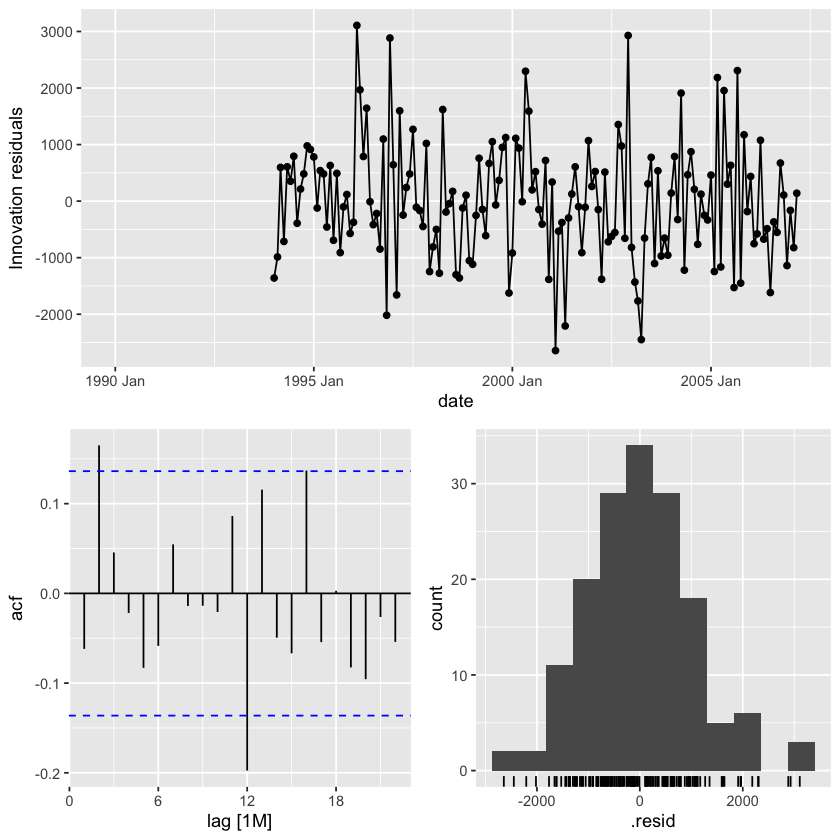

In [50]:
model_nnet %>%
  select(hand) %>%
  gg_tsresiduals()

Warning message:
"Removed 27 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 27 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 27 rows containing non-finite outside the scale range (`stat_bin()`)."


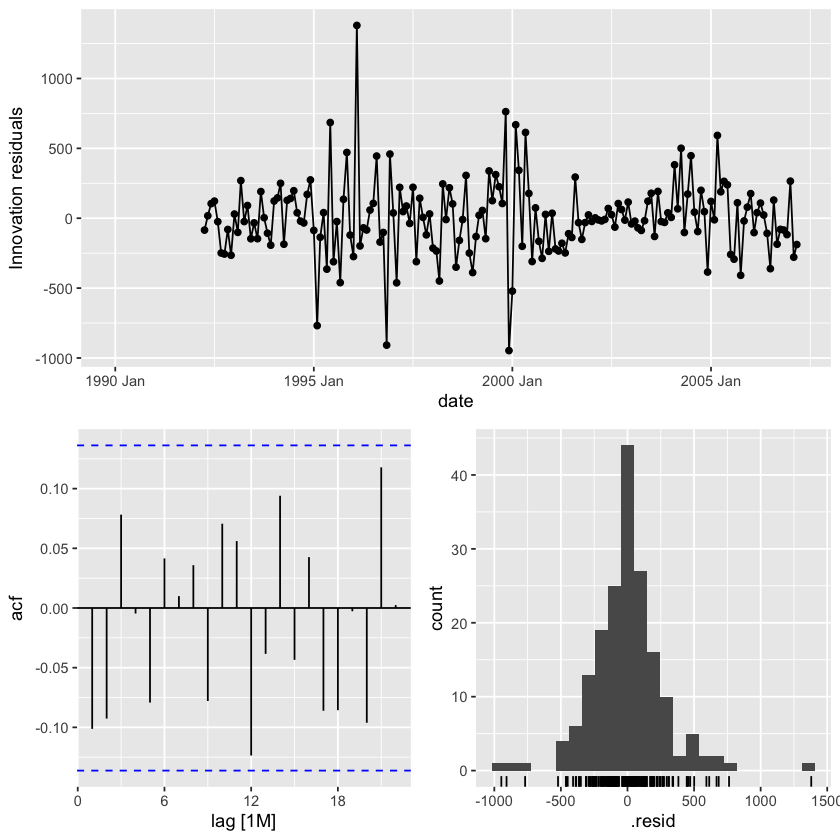

In [51]:
model_nnet %>%
  select(auto) %>%
  gg_tsresiduals()

In [52]:
test$Sep11 <- rep(0, 12)

model_nnet_for <- forecast(model_nnet, test)

nnet_for_hand <- rep(NA, 12)
nnet_for_auto <- rep(NA, 12)

for(i in 1:12){
  nnet_for_hand[i] <- train$Passengers[length(train$Passengers) - 12 + i] + model_nnet_for$.mean[i]
}

for(i in 1:12){
  nnet_for_auto[i] <- train$Passengers[length(train$Passengers) - 12 + i] + model_nnet_for$.mean[i+12]
}